In [3]:
# Standards
import os
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Statistics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import spearmanr, shapiro, stats

# Preprocessing
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

# Model Selection and Validation
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict, cross_validate,
    StratifiedKFold, RepeatedStratifiedKFold, GridSearchCV
)

#Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.multiclass import OneVsOneClassifier

#Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score, auc, make_scorer,
    balanced_accuracy_score
)

#Interpretability
from sklearn.inspection import permutation_importance
import shap

#Class imbalance management
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

#Disable warnings
warnings.filterwarnings("ignore")

In [4]:
# https://www.mikulskibartosz.name/how-to-set-the-global-random_state-in-scikit-learn/
# fix numpy random seed to assure reproducable results (also in sklearn)
#-----------------------------------------------------------------------------------------------------------
# IMPORTANT: When cells with randomness are executed in different orders this leads to different results.
#-----------------------------------------------------------------------------------------------------------
RANDOM_SEED = 235457

np.random.seed(RANDOM_SEED)

In [5]:
df_nps=pd.read_excel("DATASET FINALIZZATA_PIT_nps_13.04.xlsx")

In [6]:
df_nps.info()
df_nps.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 85 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           110 non-null    int64  
 1   group                        110 non-null    object 
 2   Gender                       110 non-null    object 
 3   Age                          110 non-null    int64  
 4   Education level              110 non-null    int64  
 5   MMSE                         110 non-null    float64
 6   Corsi D.                     108 non-null    float64
 7   Digit D.                     110 non-null    float64
 8   Supraspan                    108 non-null    float64
 9   TMT-A                        110 non-null    int64  
 10  TMT-B                        110 non-null    int64  
 11  TMT-B-A                      110 non-null    int64  
 12  Rey_copy                     110 non-null    float64
 13  Rey_Imm             

id                 110
group              110
Gender             110
Age                110
Education level    110
                  ... 
UPDRS AP             8
UPDRS UD             8
UPDRS UA             8
UPDRS A              8
UPDRS SDD            8
Length: 85, dtype: int64

In [7]:
df_nps.columns.tolist()

['id',
 'group',
 'Gender',
 'Age',
 'Education level',
 'MMSE',
 'Corsi D.',
 'Digit D.',
 'Supraspan',
 'TMT-A',
 'TMT-B',
 'TMT-B-A',
 'Rey_copy',
 'Rey_Imm',
 'Rey_diff',
 'Rey_oblio',
 'Rac Im',
 'Rac Diff',
 'Rac Oblio',
 'FAB',
 'MFPT-UD',
 'MFPT-CS',
 'Fluency F.',
 'Fluency S',
 'Fluency A',
 'Fluency Shifting',
 'SiFI_70',
 'SiFI_110',
 'SiFI_150',
 'SiFI_230',
 'SiFI_tot',
 'auditory_70',
 'auditory_110',
 'auditory_150',
 'auditory_230',
 'auditory__tot',
 'visual_ 70',
 'visual_110',
 'visual_150',
 'visual_230',
 'visual_tot',
 'bimodal_70',
 'bimodal_110',
 'bimodal_150',
 'bimodal_230',
 'bimodal_tot',
 '1_visual',
 '1_bimodal',
 '1_auditory',
 'SUS',
 'PIT (s)',
 'PIT (n. correct answers)',
 'PIT (elements)',
 'STROOP_RT_D',
 'STROOP_RT_INT',
 'STROOP_Mean Congruent RT',
 'STROOP_Mean Incongruent RT',
 'STROOP-STIR',
 'TFI-11',
 'TFI_12',
 'TFI_13',
 'TFI_14',
 'TFI_15',
 'TFI_16',
 'TFI_17',
 'TFI_18',
 'TFI_19',
 'TFI_20',
 'TFI_21',
 'TFI_22',
 'TFI_23',
 'TFI_24',


# EDA (pt 1)

In [8]:
n_pz = df_nps.shape[0]
print("The total number of patients in the DataFrame df is:", n_pz)

The total number of patients in the DataFrame df is: 110


In [9]:
range_columns = {}
for column in df_nps.columns:
    if pd.api.types.is_numeric_dtype(df_nps[column]):
        column_min = df_nps[column].min()
        column_max = df_nps[column].max()
        range_columns[column] = (column_min, column_max)

for column, (min_val, max_val) in range_columns.items():
    print(f'Variable: {column}, Range: ({min_val}, {max_val})')

Variable: id, Range: (1, 110)
Variable: Age, Range: (65, 88)
Variable: Education level, Range: (5, 22)
Variable: MMSE, Range: (22.7, 30.0)
Variable: Corsi D., Range: (2.83, 8.07)
Variable: Digit D., Range: (3.65, 8.87)
Variable: Supraspan, Range: (2.45, 29.0)
Variable: TMT-A, Range: (0, 98)
Variable: TMT-B, Range: (0, 371)
Variable: TMT-B-A, Range: (0, 360)
Variable: Rey_copy, Range: (14.2, 36.0)
Variable: Rey_Imm, Range: (0.0, 35.4)
Variable: Rey_diff, Range: (0.0, 36.0)
Variable: Rey_oblio, Range: (0.0, 8.5)
Variable: Rac Im, Range: (0.0, 8.3)
Variable: Rac Diff, Range: (0.0, 8.4)
Variable: Rac Oblio, Range: (0.0, 4.7)
Variable: FAB, Range: (8.2, 18.0)
Variable: MFPT-UD, Range: (0.0, 47.25)
Variable: MFPT-CS, Range: (0.0, 6.25)
Variable: Fluency F., Range: (4.73, 62.71)
Variable: Fluency S, Range: (21.92, 78.53)
Variable: Fluency A, Range: (6.08, 65.76)
Variable: Fluency Shifting, Range: (0.16618854486101495, 1.3297232250300843)
Variable: SiFI_70, Range: (0.0, 1.0)
Variable: SiFI_110

In [10]:
Nan = df_nps.isna().sum()
col_Nan = Nan[Nan > 0]
print(col_Nan)

Corsi D.                        2
Supraspan                       2
Rey_Imm                         2
Rey_diff                        1
Rey_oblio                       2
SiFI_70                         3
SiFI_110                        3
SiFI_150                        3
SiFI_230                        3
SiFI_tot                        3
auditory_70                     3
auditory_110                    3
auditory_150                    3
auditory_230                    3
auditory__tot                   3
visual_ 70                      3
visual_110                      3
visual_150                      3
visual_230                      3
visual_tot                      3
bimodal_70                      3
bimodal_110                     3
bimodal_150                     3
bimodal_230                     3
bimodal_tot                     3
1_visual                        4
1_bimodal                       4
1_auditory                      4
SUS                             5
PIT (s)       

In [11]:
dups = df_nps.duplicated()
print(f'Are there duplicates? = {dups.any()}')

Are there duplicates? = False


In [12]:
#Descriptive analysis (before imputation)
with pd.option_context('display.max_rows', None):
    display(df_nps.describe().transpose())

,count,mean,std,min,25%,50%,75%,max
id,110.0,55.500000,31.898276,1.000000,28.250000,55.500000,82.750000,110.000000
Age,110.0,73.445455,6.299245,65.000000,68.000000,72.000000,77.000000,88.000000
Education level,110.0,12.754545,4.023295,5.000000,8.000000,13.000000,17.000000,22.000000
MMSE,110.0,27.907091,1.999291,22.700000,26.300000,27.850000,30.000000,30.000000
Corsi D.,108.0,4.938056,1.044215,2.830000,4.200000,4.830000,5.500000,8.070000
Digit D.,110.0,6.045727,1.119876,3.650000,5.270000,6.020000,6.870000,8.870000
Supraspan,108.0,15.083148,7.377134,2.450000,8.407500,14.265000,20.577500,29.000000
TMT-A,110.0,33.581818,19.798703,0.000000,21.250000,33.000000,42.750000,98.000000
TMT-B,110.0,64.472727,59.038739,0.000000,21.500000,56.000000,91.000000,371.000000
TMT-B-A,110.0,35.554545,48.867840,0.000000,0.000000,20.500000,43.750000,360.000000


In [13]:
df_n = df_nps.copy()

In [14]:
df_n['group'].value_counts()

group
MCI        58
HC         32
Frailty    20
Name: count, dtype: int64

In [15]:
df_n.dtypes.to_list()

[dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('O'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dty

# Pre-processing

In [16]:
#NaN imputation and feature standardization
numeric_features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A',
                    'Fluency Shifting', 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

df_n_transformed = preprocessor.fit_transform(df_n[numeric_features])

df_n[numeric_features] = pd.DataFrame(df_n_transformed, columns=numeric_features, index=df_n.index)

In [17]:
Nan = df_n.isna().sum()
col_Nan = Nan[Nan > 0]
print(col_Nan)

Corsi D.                        2
Supraspan                       2
Rey_Imm                         2
Rey_diff                        1
Rey_oblio                       2
SiFI_70                         3
SiFI_110                        3
SiFI_150                        3
SiFI_230                        3
SiFI_tot                        3
auditory_70                     3
auditory_110                    3
auditory_150                    3
auditory_230                    3
auditory__tot                   3
visual_ 70                      3
visual_110                      3
visual_150                      3
visual_230                      3
visual_tot                      3
bimodal_70                      3
bimodal_110                     3
bimodal_150                     3
bimodal_230                     3
bimodal_tot                     3
1_visual                        4
1_bimodal                       4
1_auditory                      4
SUS                             5
STROOP_RT_D   

# EDA (pt 2)

In [18]:
#Descriptive analysis with imputed data
with pd.option_context('display.max_rows', None):
    display(df_n.describe().transpose())

,count,mean,std,min,25%,50%,75%,max
id,110.0,5.550000e+01,31.898276,1.000000,28.250000,55.500000,82.750000,110.000000
Age,110.0,7.344545e+01,6.299245,65.000000,68.000000,72.000000,77.000000,88.000000
Education level,110.0,1.275455e+01,4.023295,5.000000,8.000000,13.000000,17.000000,22.000000
MMSE,110.0,2.790709e+01,1.999291,22.700000,26.300000,27.850000,30.000000,30.000000
Corsi D.,108.0,4.938056e+00,1.044215,2.830000,4.200000,4.830000,5.500000,8.070000
Digit D.,110.0,6.045727e+00,1.119876,3.650000,5.270000,6.020000,6.870000,8.870000
Supraspan,108.0,1.508315e+01,7.377134,2.450000,8.407500,14.265000,20.577500,29.000000
TMT-A,110.0,3.358182e+01,19.798703,0.000000,21.250000,33.000000,42.750000,98.000000
TMT-B,110.0,3.229740e-17,1.004577,-1.097039,-0.731205,-0.144168,0.451376,5.215731
TMT-B-A,110.0,1.009294e-17,1.004577,-0.730895,-0.730895,-0.309476,0.168474,6.669628


In [19]:
#Describe comparative analysis: neuropsychological tests and behavioral tasks for groups
variables_to_compare = df_n[['MMSE','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting', 'STROOP-STIR', 'STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT','PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

results = []

for variable in variables_to_compare:
    mci_data = df_n.loc[df_n['group'] == 'MCI', variable].dropna()
    frailty_data = df_n.loc[df_n['group'] == 'Frailty', variable].dropna()
    hc_data = df_n.loc[df_n['group'] == 'HC', variable].dropna()

    mci_mean, mci_std = mci_data.mean(), mci_data.std()
    frailty_mean, frailty_std = frailty_data.mean(), frailty_data.std()
    hc_mean, hc_std = hc_data.mean(), hc_data.std()

    t_stat_mci_hc, p_value_mci_hc = stats.ttest_ind(mci_data, hc_data, nan_policy='omit')
    t_stat_frailty_hc, p_value_frailty_hc = stats.ttest_ind(frailty_data, hc_data, nan_policy='omit')
    t_stat_frailty_mci, p_value_frailty_mci = stats.ttest_ind(frailty_data, mci_data, nan_policy='omit')


    results.append([variable,
                    round(mci_mean, 2), round(mci_std, 2),
                    round(frailty_mean, 2), round(frailty_std, 2),
                    round(hc_mean, 2), round(hc_std, 2),
                    round(p_value_mci_hc, 5), round(p_value_frailty_hc, 5), round(p_value_frailty_mci, 5)])


results_descriptive = pd.DataFrame(results, columns=['Variable',
                                            'MCI Mean', 'MCI Std',
                                            'Frailty Mean', 'Frailty Std',
                                            'HC Mean', 'HC Std',
                                            'p-value (MCI vs HC)',
                                            'p-value (Frailty vs HC)',
                                            'p-value (Frailty vs MCI)'])

results_descriptive

,Variable,MCI Mean,MCI Std,Frailty Mean,Frailty Std,HC Mean,HC Std,p-value (MCI vs HC),p-value (Frailty vs HC),p-value (Frailty vs MCI)
0,MMSE,27.56,1.97,28.72,1.87,28.03,2.03,0.27773,0.22376,0.02295
1,TMT-B,0.27,1.18,-0.33,0.72,-0.28,0.63,0.01537,0.79276,0.03421
2,TMT-B-A,0.27,1.23,-0.26,0.60,-0.32,0.50,0.01078,0.70302,0.06688
3,FAB,-0.51,1.07,0.57,0.48,0.57,0.53,0.00000,0.99690,0.00004
4,MFPT-UD,-0.48,0.93,0.31,0.85,0.67,0.75,0.00000,0.11483,0.00139
5,MFPT-CS,-0.18,0.43,0.64,2.01,-0.07,0.62,0.34768,0.06596,0.00430
6,Fluency F.,-0.49,0.94,0.54,0.70,0.56,0.81,0.00000,0.96282,0.00002
7,Fluency S,-0.43,0.86,0.39,0.89,0.54,0.98,0.00000,0.56595,0.00050
8,Fluency A,-0.55,0.78,0.41,0.72,0.75,0.92,0.00000,0.16524,0.00001
9,Fluency Shifting,-0.38,0.92,0.20,0.79,0.56,0.99,0.00002,0.16776,0.01450


In [20]:
#Descriptive analysis by group: Demografic - Age and education level
age_education_stats = df_n.groupby('group').agg({'Age': ['mean', 'std'], 'Education level': ['mean', 'std']}).round(2)
age_education_stats

Age       Education level      
          mean   std            mean   std
group                                     
Frailty  73.40  6.69           13.25  3.65
HC       71.28  5.53           13.91  3.25
MCI      74.66  6.34           11.95  4.39

In [21]:
#Descriptive analysis by group: Demografic - Gender
gender_percentage = df_n.groupby(['group', 'Gender'])['Gender'].count().unstack().apply(lambda x: (x / x.sum()) * 100, axis=1).round(2)
gender_percentage

Gender,F,M
group,,
Frailty,75.00,25.00
HC,62.50,37.50
MCI,63.79,36.21


Multicollinearity

In [22]:
#Check multicollinearity
features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

X_vif = df_n[features].copy()
X_vif = X_vif.apply(pd.to_numeric, errors='coerce') 
X_vif = X_vif.dropna()  
X_vif_const = add_constant(X_vif)

# Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i)
                   for i in range(X_vif_const.shape[1])]

vif_data.sort_values(by='VIF',ascending=False).head(15)

,Feature,VIF
7,Fluency A,14.036193
8,Fluency Shifting,10.015274
2,TMT-B-A,9.334511
1,TMT-B,9.111711
6,Fluency S,3.901347
10,PIT (s),3.609587
11,PIT (n. correct answers),2.176782
12,PIT (elements),1.876248
4,MFPT-UD,1.748669
3,FAB,1.637639


Full model vs pruned model. Check how it changes by removing multicollinear features in order to decide the best model to use.

In [23]:
#1.Full model setup

features_full = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                 'Fluency S', 'Fluency A', 'Fluency Shifting',
                 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

X_full = df_n[features_full].apply(pd.to_numeric, errors='coerce').dropna()
y_full = df_n.loc[X_full.index, 'group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(X_full, y_full, test_size=0.3, stratify=y_full, random_state=42)


model_full = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_full.fit(X_full_train, y_full_train)

y_full_pred = model_full.predict(X_full_test)
y_full_proba = model_full.predict_proba(X_full_test)[:, 1]

# 2.Pruned model setup

features_pruned = [f for f in features_full if f not in ['TMT-B-A', 'Fluency A']]
X_pruned = df_n[features_pruned].apply(pd.to_numeric, errors='coerce').dropna()
y_pruned = df_n.loc[X_pruned.index, 'group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_pruned_train, X_pruned_test, y_pruned_train, y_pruned_test = train_test_split(X_pruned, y_pruned, test_size=0.3, stratify=y_pruned, random_state=42)

model_pruned = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_pruned.fit(X_pruned_train, y_pruned_train)

y_pruned_pred = model_pruned.predict(X_pruned_test)
y_pruned_proba = model_pruned.predict_proba(X_pruned_test)[:, 1]

# 3.Comparison

auc_full = roc_auc_score(y_full_test, y_full_proba)
acc_full = accuracy_score(y_full_test, y_full_pred)
f1_full = f1_score(y_full_test, y_full_pred)

auc_pruned = roc_auc_score(y_pruned_test, y_pruned_proba)
acc_pruned = accuracy_score(y_pruned_test, y_pruned_pred)
f1_pruned = f1_score(y_pruned_test, y_pruned_pred)

print("Full Model")
print(f"Accuracy: {acc_full:.3f}")
print(f"AUC-ROC : {auc_full:.3f}")
print(f"F1:{f1_full:.3f}")

print("Pruned Model")
print(f"Accuracy: {acc_pruned:.3f}")
print(f"AUC-ROC : {auc_pruned:.3f}")
print(f"F1:{f1_pruned:.3f}")

Full Model
Accuracy: 0.697
AUC-ROC : 0.827
F1:0.667
Pruned Model
Accuracy: 0.667
AUC-ROC : 0.798
F1:0.645


Normal distribution

In [24]:
#Shapiro-Wilk test to check the normality of the features
features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

normality_results = {}

for feature in features:
    stat, p_value = shapiro(df_n[feature].dropna())
    normality_results[feature] = {'Statistic': stat, 'p-value': p_value,
                                  'Normality (p>0.05)': p_value > 0.05}

normality_df = pd.DataFrame(normality_results).T
normality_df

,Statistic,p-value,Normality (p>0.05)
TMT-B,0.86003,0.0,False
TMT-B-A,0.689561,0.0,False
FAB,0.885869,0.0,False
MFPT-UD,0.988252,0.456206,True
MFPT-CS,0.37394,0.0,False
Fluency S,0.985489,0.280637,True
Fluency A,0.976261,0.046613,False
Fluency Shifting,0.994863,0.958615,True
STROOP-STIR,0.685279,0.0,False
PIT (s),0.873055,0.0,False


Correlations

In [25]:
#Check correlations between variables to understand whether to use correlational feature selection or probabilistic models
#Spearman Correlation Matrix

features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

correlation_matrix = df_n[features].corr(method='spearman').round(2)

fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.index,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=correlation_matrix.values,
    texttemplate="%{text}",
    hovertemplate='Spearman correlation %{y} vs %{x}: %{z}<extra></extra>',
    colorbar=dict(title="Correlation")
))

fig.update_layout(
    title="Spearman Correlation Matrix",
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()

In [26]:
#Correlation matrix between PIT and executive functions
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']
EF_features = ['TMT-A','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR','STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT']

groups = df_n['group'].dropna().unique()

fig = go.Figure()

p_value_threshold = 0.05

for i, group in enumerate(groups):
    df_group = df_n[df_n['group'] == group]
    

    corr_matrix = np.zeros((len(EF_features), len(pit_features)))
    pval_matrix = np.zeros((len(EF_features), len(pit_features)))

    for j, feat1 in enumerate(EF_features):
        for k, feat2 in enumerate(pit_features):
           
            if df_group[feat1].isna().any() or df_group[feat2].isna().any():
                corr_matrix[j, k] = np.nan
                pval_matrix[j, k] = np.nan
            else:
                corr, pval = spearmanr(df_group[feat1], df_group[feat2])
                corr_matrix[j, k] = corr
                pval_matrix[j, k] = pval

    corr_matrix = pd.DataFrame(corr_matrix, index=EF_features, columns=pit_features).round(2)
    pval_matrix = pd.DataFrame(pval_matrix, index=EF_features, columns=pit_features)

    # Filter significant correlations (p-value < 0.05)
    mask_significant = pval_matrix < p_value_threshold
    significant_rows = mask_significant.any(axis=1)  

    if significant_rows.any():  
        filtered_corr_matrix = corr_matrix.loc[significant_rows]
        filtered_pval_matrix = pval_matrix.loc[significant_rows]

        mask_values = (filtered_pval_matrix < p_value_threshold)
        masked_corr_matrix = filtered_corr_matrix.where(mask_values, np.nan)

        pval_text = filtered_pval_matrix.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

        text_matrix = filtered_corr_matrix.round(2).astype(str) + "<br>p = " + pval_text
        text_matrix[~mask_values] = ""  

        colorscale = [
            [0, 'rgba(215, 48, 39, 1)'], 
            [0.5, 'rgba(255, 255, 255, 0)'],  
            [1, 'rgba(69, 117, 180, 1)'] 
        ]


        fig.add_trace(go.Heatmap(
            z=masked_corr_matrix.values,
            x=masked_corr_matrix.columns,
            y=masked_corr_matrix.index,
            colorscale=colorscale,
            zmin=-1,
            zmax=1,
            text=text_matrix.values,
            texttemplate="%{text}",
            hovertemplate=f"{group} - Correlation "+"%{y} vs %{x}<br>Correlation: %{z}<br>p-value: " + pval_text + "<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))
    else:
        fig.add_trace(go.Heatmap(
            z=[[np.nan]],
            x=[pit_features[0]],
            y=["No significant correlation"],
            colorscale='RdBu',
            zmin=-1,
            zmax=1,
            text=[[""]],
            texttemplate="%{text}",
            hovertemplate=f"{group} - No significant correlation<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))

buttons = []
for i, group in enumerate(groups):
    visibility = [False] * len(groups)
    visibility[i] = True
    buttons.append(dict(
        label=group,
        method='update',
        args=[{'visible': visibility},
              {'title': f"Spearman Correlation between PIT and EF measures (p < 0.05) ({group})"}]
    ))

fig.update_layout(
    title=f"Spearman Correlation between PIT and EF measures (p < 0.05) ({groups[0]})",
    xaxis_title="PIT Variables",
    yaxis_title="EF Measures",
    autosize=True,
    updatemenus=[dict(active=0, buttons=buttons, x=0.1, y=1.2)]
)

fig.show()


In [27]:
#Correlation matrix between PIT and neuropsychological measures

pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

exclude_features = ['id', 'Age', 'Education level']
all_features = [col for col in df_n.select_dtypes(include=['number']).columns 
                if col not in pit_features and col not in exclude_features]

groups = df_n['group'].dropna().unique()

fig = go.Figure()

p_value_threshold = 0.05


for i, group in enumerate(groups):
    df_group = df_n[df_n['group'] == group]
    

    corr_matrix_all = np.zeros((len(all_features), len(pit_features)))
    pval_matrix_all = np.zeros((len(all_features), len(pit_features)))

    for j, feat1 in enumerate(all_features):
        for k, feat2 in enumerate(pit_features):
           
            if df_group[feat1].isna().any() or df_group[feat2].isna().any():
                corr_matrix_all[j, k] = np.nan
                pval_matrix_all[j, k] = np.nan
            else:
                corr, pval = spearmanr(df_group[feat1], df_group[feat2])
                corr_matrix_all[j, k] = corr
                pval_matrix_all[j, k] = pval

    corr_matrix_all = pd.DataFrame(corr_matrix_all, index=all_features, columns=pit_features).round(2)
    pval_matrix_all = pd.DataFrame(pval_matrix_all, index=all_features, columns=pit_features)

    # Filter significant correlations (p-value < 0.05)
    mask_significant = pval_matrix_all < p_value_threshold
    significant_rows = mask_significant.any(axis=1)  

    if significant_rows.any():  
        filtered_corr_matrix_all = corr_matrix_all.loc[significant_rows]
        filtered_pval_matrix_all = pval_matrix_all.loc[significant_rows]

        mask_values = (filtered_pval_matrix_all < p_value_threshold)
        masked_corr_matrix_all = filtered_corr_matrix_all.where(mask_values, np.nan)

        pval_text = filtered_pval_matrix_all.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

        text_matrix = filtered_corr_matrix_all.round(2).astype(str) + "<br>p = " + pval_text
        text_matrix[~mask_values] = ""  

        colorscale = [
            [0, 'rgba(215, 48, 39, 1)'], 
            [0.5, 'rgba(255, 255, 255, 0)'],  
            [1, 'rgba(69, 117, 180, 1)'] 
        ]

        
        fig.add_trace(go.Heatmap(
            z=masked_corr_matrix_all.values,
            x=masked_corr_matrix_all.columns,
            y=masked_corr_matrix_all.index,
            colorscale=colorscale,
            zmin=-1,
            zmax=1,
            text=text_matrix.values,
            texttemplate="%{text}",
            hovertemplate=f"{group} - Correlation "+"%{y} vs %{x}<br>Correlation: %{z}<br>p-value: " + pval_text + "<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))
    else:
        fig.add_trace(go.Heatmap(
            z=[[np.nan]],
            x=[pit_features[0]],
            y=["No significant correlation"],
            colorscale='RdBu',
            zmin=-1,
            zmax=1,
            text=[[""]],
            texttemplate="%{text}",
            hovertemplate=f"{group} - No significant correlation<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))

buttons = []
for i, group in enumerate(groups):
    visibility = [False] * len(groups)
    visibility[i] = True
    buttons.append(dict(
        label=group,
        method='update',
        args=[{'visible': visibility},
              {'title': f"Spearman Correlation between PIT and neuropsychological measures (p < 0.05) ({group})"}]
    ))

fig.update_layout(
    title=f"Spearman Correlation between PIT and neuropsychological measures (p < 0.05) ({groups[0]})",
    xaxis_title="PIT Variables",
    yaxis_title="Neuropsychological Measures",
    autosize=True,
    updatemenus=[dict(active=0, buttons=buttons, x=0.1, y=1.2)]
)

fig.show()

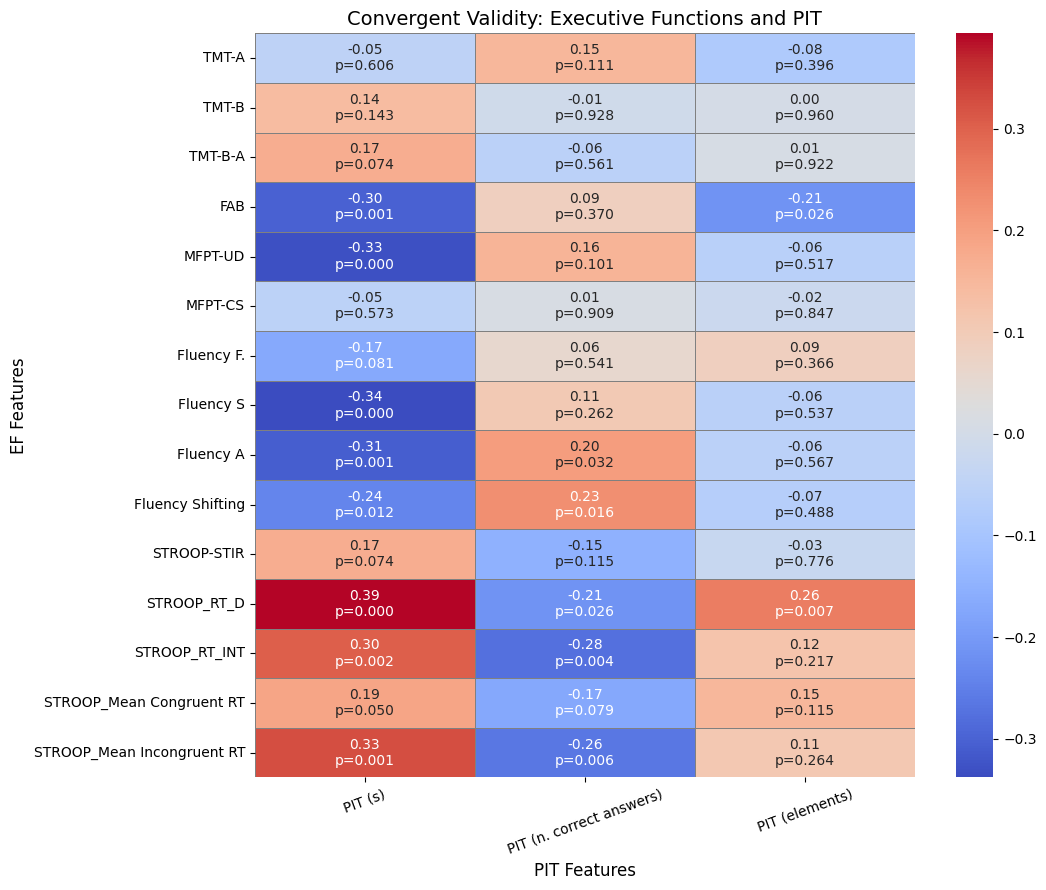

In [28]:
EF_features = ['TMT-A','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR','STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT']  

pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

spearman_results = []
for ef in EF_features:
    for pit in pit_features:
        corr, pval = spearmanr(df_n[ef], df_n[pit])
        spearman_results.append({
            'EF Feature': ef,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval
        })

spearman_df = pd.DataFrame(spearman_results)

spearman_results_cleaned = []

for ef in EF_features:
    for pit in pit_features:
        # Drop NaNs pairwise
        valid_data = df_n[[ef, pit]].dropna()
        if valid_data[ef].nunique() > 1 and valid_data[pit].nunique() > 1:
            corr, pval = spearmanr(valid_data[ef], valid_data[pit])
        else:
            corr, pval = np.nan, np.nan  # Avoid errors with constant values
        spearman_results_cleaned.append({
            'EF Feature': ef,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval
        })

numeric_matrix_cleaned = pd.DataFrame(index=EF_features, columns=pit_features, dtype=float)
annotation_matrix_cleaned = pd.DataFrame(index=EF_features, columns=pit_features, dtype=object)

for row in spearman_results_cleaned:
    ef = row['EF Feature']
    pit = row['PIT Feature']
    corr = row['Spearman Correlation']
    pval = row['p-value']
    numeric_matrix_cleaned.loc[ef, pit] = corr
    if not np.isnan(corr) and not np.isnan(pval):
        annotation_matrix_cleaned.loc[ef, pit] = f"{corr:.2f}\np={pval:.3f}"
    else:
        annotation_matrix_cleaned.loc[ef, pit] = "N/A"

plt.figure(figsize=(11, 9))
sns.heatmap(numeric_matrix_cleaned.astype(float), annot=annotation_matrix_cleaned, fmt='', cmap='coolwarm', 
            cbar=True, linewidths=0.6, linecolor='gray', mask=numeric_matrix_cleaned.isna())
plt.title("Convergent Validity: Executive Functions and PIT", fontsize=14)
plt.xlabel("PIT Features", fontsize=12)
plt.ylabel("EF Features", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

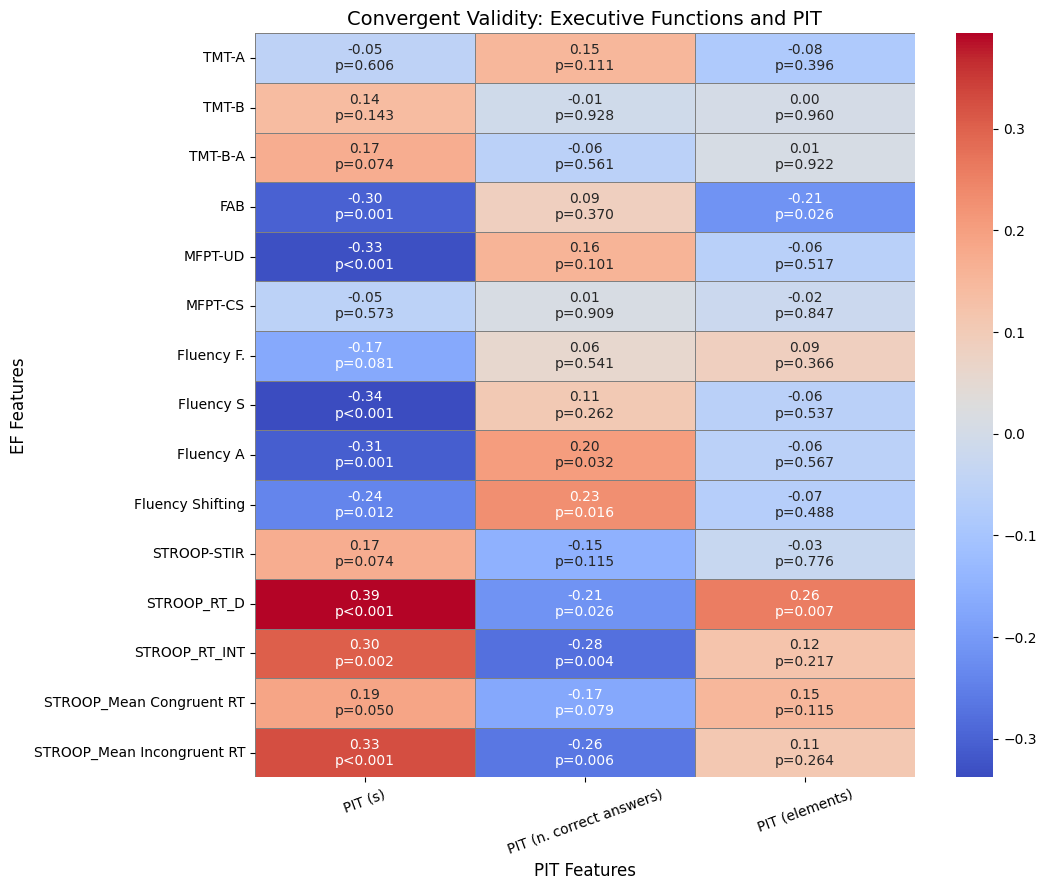

In [29]:
annotation_matrix_adjusted = pd.DataFrame(index=EF_features, columns=pit_features, dtype=object)

for row in spearman_results_cleaned:
    ef = row['EF Feature']
    pit = row['PIT Feature']
    corr = row['Spearman Correlation']
    pval = row['p-value']
    
    if not np.isnan(corr) and not np.isnan(pval):
        if pval < 0.001:
            annotation_matrix_adjusted.loc[ef, pit] = f"{corr:.2f}\np<0.001"
        else:
            annotation_matrix_adjusted.loc[ef, pit] = f"{corr:.2f}\np={pval:.3f}"
    else:
        annotation_matrix_adjusted.loc[ef, pit] = "N/A"

# Plot the adjusted heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(numeric_matrix_cleaned.astype(float), annot=annotation_matrix_adjusted, fmt='', cmap='coolwarm', 
            cbar=True, linewidths=0.6, linecolor='gray', mask=numeric_matrix_cleaned.isna())
plt.title("Convergent Validity: Executive Functions and PIT", fontsize=14)
plt.xlabel("PIT Features", fontsize=12)
plt.ylabel("EF Features", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Training and testing of ML models

## Attempt 1: Multiclass classification

In [30]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency S', 'Fluency A', 'Fluency Shifting', 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_n['group']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"N. Training sample {len(y_train)}, {len(y_train)/len(y)*100:.2f}%")
print(f"N. Testing sample {len(y_test)}, {len(y_test)/len(y)*100:.2f}%")

N. Training sample 77, 70.00%
N. Testing sample 33, 30.00%


In [32]:
label_mapping = {'HC': 0, 'MCI': 1, 'Frailty': 2}
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)

In [33]:
y_train.value_counts()

group
1    39
0    21
2    17
Name: count, dtype: int64

In [34]:
y_test.value_counts()

group
1    19
0    11
2     3
Name: count, dtype: int64

Baseline model: Linear Discriminant Analysis (LDA)

In [35]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)
y_train_pred_lda = lda.predict(X_train)
y_pred_lda = lda.predict(X_test)

# Evaluate the LDA baseline model
classes = ['HC', 'MCI', 'Frailty']
print("\nLDA Classification Report on Training Set:")
print(classification_report(y_train, y_train_pred_lda, target_names=classes))
print("\nLDA Classification Report on Testing Set:\n", classification_report(y_test, y_pred_lda, target_names=classes))

# AUC-ROC
y_train_prob = lda.predict_proba(X_train)
auc_roc_t = roc_auc_score(y_train, y_train_prob, multi_class='ovo')
print(f"AUC-ROC (OvO) on Training Set: {auc_roc_t:.3f}")

y_test_prob = lda.predict_proba(X_test)
auc_roc = roc_auc_score(y_test, y_test_prob, multi_class='ovo')
print(f"AUC-ROC (OvO) on Testing Set: {auc_roc:.3f}")


LDA Classification Report on Training Set:
              precision    recall  f1-score   support

          HC       0.72      0.86      0.78        21
         MCI       0.87      0.85      0.86        39
     Frailty       0.79      0.65      0.71        17

    accuracy                           0.81        77
   macro avg       0.79      0.78      0.78        77
weighted avg       0.81      0.81      0.80        77


LDA Classification Report on Testing Set:
               precision    recall  f1-score   support

          HC       0.83      0.45      0.59        11
         MCI       0.81      0.89      0.85        19
     Frailty       0.33      0.67      0.44         3

    accuracy                           0.73        33
   macro avg       0.66      0.67      0.63        33
weighted avg       0.77      0.73      0.73        33

AUC-ROC (OvO) on Training Set: 0.905
AUC-ROC (OvO) on Testing Set: 0.838


In [36]:
#Training and testing of algorithms: Decision Tree Classifier, Logistic regression, K-NN
#Multiclass classification with One-vs-One (OvO)

model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
models = [
    DecisionTreeClassifier(),
    LogisticRegression(multi_class='ovr', max_iter=1000),
    KNeighborsClassifier(),
]

results = []

#Specificity
def calculate_specificity(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    for i in range(conf_matrix.shape[0]):
        tn = np.sum(np.delete(np.delete(conf_matrix, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(conf_matrix[:, i], i))
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    return specificity_per_class

# Loop through models
for name, model in zip(model_names, models):
    # Train model
    model.fit(X_train, y_train)

    
    y_train_prob = model.predict_proba(X_train)
    y_train_pred = model.predict(X_train)

    
    y_test_prob = model.predict_proba(X_test)
    y_test_pred = model.predict(X_test)

    # AUC-ROC (OvO) for training and testing sets
    auc_roc_train = roc_auc_score(y_train, y_train_prob, multi_class='ovo')
    auc_roc_test = roc_auc_score(y_test, y_test_prob, multi_class='ovo')

    # Classification Report for training and testing
    class_report_train = classification_report(y_train, y_train_pred)
    class_report_test = classification_report(y_test, y_test_pred)

    # Specificity per class for training and testing sets
    specificity_train = calculate_specificity(y_train, y_train_pred)
    specificity_test = calculate_specificity(y_test, y_test_pred)

    results.append({
        'Model': name,
        'AUC-ROC (Train)': auc_roc_train,
        'AUC-ROC (Test)': auc_roc_test,
        'Classification Report (Train)': class_report_train,
        'Classification Report (Test)': class_report_test,
        'Specificity (Train)': specificity_train,
        'Specificity (Test)': specificity_test
    })

for result in results:
    print(f"Model: {result['Model']}")
    print(f"AUC-ROC (Train): {result['AUC-ROC (Train)']:.3f}")
    print(f"AUC-ROC (Test): {result['AUC-ROC (Test)']:.3f}")
    print("Classification Report (Training Set):")
    print(result['Classification Report (Train)'])
    print("Classification Report (Testing Set):")
    print(result['Classification Report (Test)'])
    print(f"Specificity (Train): {result['Specificity (Train)']}")
    print(f"Specificity (Test): {result['Specificity (Test)']}")
    print("\n" + "-"*60 + "\n")

Model: Decision Tree
AUC-ROC (Train): 1.000
AUC-ROC (Test): 0.716
Classification Report (Training Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00        17

    accuracy                           1.00        77
   macro avg       1.00      1.00      1.00        77
weighted avg       1.00      1.00      1.00        77

Classification Report (Testing Set):
              precision    recall  f1-score   support

           0       0.78      0.64      0.70        11
           1       0.85      0.89      0.87        19
           2       0.25      0.33      0.29         3

    accuracy                           0.76        33
   macro avg       0.63      0.62      0.62        33
weighted avg       0.77      0.76      0.76        33

Specificity (Train): [1.0, 1.0, 1.0]
Specificity (Test): [0.9090909090909091, 0.7857142857142857,

In [37]:
#Training and testing of algorithms: Decision Tree Classifier, Logistic regression, K-NN
#Multiclass classification with One-vs-One (OvO) with class_weight=balanced

models_balanced = [
    DecisionTreeClassifier(class_weight='balanced'),
    LogisticRegression(multi_class='ovr', class_weight='balanced', max_iter=1000),  # Logistic Regression don't have OvO
    KNeighborsClassifier(), 
]

results_balanced = []

# Loop through models with balanced class weights
for name, model in zip(model_names, models_balanced):
    model.fit(X_train, y_train)

    y_train_prob_balanced = model.predict_proba(X_train)
    y_train_pred_balanced = model.predict(X_train)

    y_test_prob_balanced = model.predict_proba(X_test)
    y_test_pred_balanced = model.predict(X_test)

    # AUC-ROC (OvO) for training and testing sets
    auc_roc_train_balanced = roc_auc_score(y_train, y_train_prob_balanced, multi_class='ovo')
    auc_roc_test_balanced = roc_auc_score(y_test, y_test_prob_balanced, multi_class='ovo')

    class_report_train_balanced = classification_report(y_train, y_train_pred_balanced)
    class_report_test_balanced = classification_report(y_test, y_test_pred_balanced)

    specificity_train_balanced = calculate_specificity(y_train, y_train_pred_balanced)
    specificity_test_balanced = calculate_specificity(y_test, y_test_pred_balanced)

    results_balanced.append({
        'Model': name,
        'AUC-ROC (Train, Balanced)': auc_roc_train_balanced,
        'AUC-ROC (Test, Balanced)': auc_roc_test_balanced,
        'Classification Report (Train, Balanced)': class_report_train_balanced,
        'Classification Report (Test, Balanced)': class_report_test_balanced,
        'Specificity (Train, Balanced)': specificity_train_balanced,
        'Specificity (Test, Balanced)': specificity_test_balanced
    })

for result in results_balanced:
    print(f"Model (Balanced): {result['Model']}")
    print(f"AUC-ROC (Train, Balanced): {result['AUC-ROC (Train, Balanced)']:.3f}")
    print(f"AUC-ROC (Test, Balanced): {result['AUC-ROC (Test, Balanced)']:.3f}")
    print("Classification Report (Training Set, Balanced):")
    print(result['Classification Report (Train, Balanced)'])
    print("Classification Report (Testing Set, Balanced):")
    print(result['Classification Report (Test, Balanced)'])
    print(f"Specificity (Train, Balanced): {result['Specificity (Train, Balanced)']}")
    print(f"Specificity (Test, Balanced): {result['Specificity (Test, Balanced)']}")
    print("\n" + "-"*60 + "\n")

Model (Balanced): Decision Tree
AUC-ROC (Train, Balanced): 1.000
AUC-ROC (Test, Balanced): 0.742
Classification Report (Training Set, Balanced):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00        17

    accuracy                           1.00        77
   macro avg       1.00      1.00      1.00        77
weighted avg       1.00      1.00      1.00        77

Classification Report (Testing Set, Balanced):
              precision    recall  f1-score   support

           0       0.78      0.64      0.70        11
           1       0.90      1.00      0.95        19
           2       0.33      0.33      0.33         3

    accuracy                           0.82        33
   macro avg       0.67      0.66      0.66        33
weighted avg       0.81      0.82      0.81        33

Specificity (Train, Balanced): [1.0, 1.0, 1.0]

In [38]:
# List of models to evaluate with balanced class weights
model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
models = [
    DecisionTreeClassifier(class_weight='balanced'),
    LogisticRegression(multi_class='ovr', class_weight='balanced', max_iter=1000),
    KNeighborsClassifier(),  # KNN doesn't natively support class weights
]


def specificity_score(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    for i in range(conf_matrix.shape[0]):
        tn = np.sum(np.delete(np.delete(conf_matrix, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(conf_matrix[:, i], i))
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    return np.mean(specificity_per_class)

# StratifiedKFold cross-validation with 10 splits
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validation for each model
cross_val_results = {}

for name, model in zip(model_names, models):
    fold_auc_roc = []
    fold_accuracy = []
    fold_f1_weighted = []
    fold_specificity = []

    all_y_true = []
    all_y_pred = []

    for train_index, val_index in kf.split(X_train, y_train):
        # Split data into training and validation sets for this fold using .iloc for pandas DataFrames/Series
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        # Train model on the fold's training data
        model.fit(X_train_fold, y_train_fold)

   
        y_val_pred = model.predict(X_val_fold)
        y_val_prob = model.predict_proba(X_val_fold)

        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_val_pred)

        # Calculate AUC-ROC for OvO multiclass
        auc_roc = roc_auc_score(y_val_fold, y_val_prob, multi_class='ovo', average='weighted')
        fold_auc_roc.append(auc_roc)

        # Calculate accuracy
        accuracy = np.mean(y_val_pred == y_val_fold)
        fold_accuracy.append(accuracy)

        # Calculate F1-weighted (use weighted average F1-score)
        class_report = classification_report(y_val_fold, y_val_pred, output_dict=True)
        f1_weighted = class_report['weighted avg']['f1-score']
        fold_f1_weighted.append(f1_weighted)

        # Calculate specificity (we'll assume equal specificity for simplicity)
        specificity = specificity_score(y_val_fold, y_val_pred)
        fold_specificity.append(specificity)


    cross_val_results[name] = {
        'Weighted AUC-ROC': np.mean(fold_auc_roc),
        'Weighted Accuracy': np.mean(fold_accuracy),
        'Weighted F1-Score': np.mean(fold_f1_weighted),
        'Weighted Specificity': np.mean(fold_specificity),
        'Overall Classification Report': classification_report(all_y_true, all_y_pred)  # Overall weighted classification report
    }

for name, results in cross_val_results.items():
    print(f"Model: {name}")
    print(f"Weighted AUC-ROC (Train): {results['Weighted AUC-ROC']:.3f}")
    print(f"Weighted Accuracy (Train): {results['Weighted Accuracy']:.3f}")
    print(f"Weighted F1-Score (Train): {results['Weighted F1-Score']:.3f}")
    print(f"Weighted Specificity (Train): {results['Weighted Specificity']:.3f}")
    print("\nOverall Classification Report (Aggregated, Weighted over all folds):")
    print(results['Overall Classification Report'])
    print("\n" + "-"*60 + "\n")

Model: Decision Tree
Weighted AUC-ROC (Train): 0.653
Weighted Accuracy (Train): 0.550
Weighted F1-Score (Train): 0.544
Weighted Specificity (Train): 0.768

Overall Classification Report (Aggregated, Weighted over all folds):
              precision    recall  f1-score   support

           0       0.45      0.43      0.44        21
           1       0.68      0.67      0.68        39
           2       0.37      0.41      0.39        17

    accuracy                           0.55        77
   macro avg       0.50      0.50      0.50        77
weighted avg       0.55      0.55      0.55        77


------------------------------------------------------------

Model: Logistic Regression
Weighted AUC-ROC (Train): 0.825
Weighted Accuracy (Train): 0.586
Weighted F1-Score (Train): 0.554
Weighted Specificity (Train): 0.794

Overall Classification Report (Aggregated, Weighted over all folds):
              precision    recall  f1-score   support

           0       0.56      0.71      0.63  

In [39]:
#Hyperparameters search

param_grids = {
    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"]
    },
    "K-Nearest Neighbors (KNN)": {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"]
    },
}

# List of models to evaluate with balanced class weights
model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
models = [
    DecisionTreeClassifier(class_weight='balanced'),
    LogisticRegression(multi_class='ovr', class_weight='balanced', max_iter=1000),
    KNeighborsClassifier(),  # KNN doesn't natively support class weights
]


def specificity_score(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    for i in range(conf_matrix.shape[0]):
        tn = np.sum(np.delete(np.delete(conf_matrix, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(conf_matrix[:, i], i))
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    return np.mean(specificity_per_class)

# StratifiedKFold cross-validation with 10 splits
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


scoring = {
    'AUC-ROC': make_scorer(roc_auc_score, multi_class='ovo', needs_proba=True),
    'Accuracy': 'accuracy',
    'F1_macro': 'f1_macro',
    'Specificity': make_scorer(specificity_score)
}

best_models = {}
grid_search_results = {}


for name, model, param_grid in zip(model_names, models, param_grids.values()):
    print(f"Performing grid search for {name}...")
    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring='roc_auc_ovo', n_jobs=-1)
    grid_search.fit(X_train, y_train)

 
    best_models[name] = grid_search.best_estimator_
    grid_search_results[name] = grid_search.best_params_

    print(f"Best hyperparameters for {name}: {grid_search.best_params_}")
    print(f"Best AUC-ROC for {name}: {grid_search.best_score_:.3f}")
    print("\n" + "-"*60 + "\n")

# Cross-validation with the best models found from GridSearchCV
cross_val_results = {}

for name, best_model in best_models.items():
    fold_auc_roc = []
    fold_accuracy = []
    fold_f1_weighted = []
    fold_specificity = []

   
    all_y_true = []
    all_y_pred = []

    for train_index, val_index in kf.split(X_train, y_train):
        # Split data into training and validation sets for this fold using .iloc for pandas DataFrames/Series
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

       
        best_model.fit(X_train_fold, y_train_fold)

        
        y_val_pred = best_model.predict(X_val_fold)
        y_val_prob = best_model.predict_proba(X_val_fold)

       
        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_val_pred)

        auc_roc = roc_auc_score(y_val_fold, y_val_prob, multi_class='ovo', average='weighted')
        fold_auc_roc.append(auc_roc)

        
        accuracy = np.mean(y_val_pred == y_val_fold)
        fold_accuracy.append(accuracy)

        class_report = classification_report(y_val_fold, y_val_pred, output_dict=True)
        f1_weighted = class_report['weighted avg']['f1-score']
        fold_f1_weighted.append(f1_weighted)

        
        specificity = specificity_score(y_val_fold, y_val_pred)
        fold_specificity.append(specificity)

    
    cross_val_results[name] = {
        'Weighted AUC-ROC': np.mean(fold_auc_roc),
        'Weighted Accuracy': np.mean(fold_accuracy),
        'Weighted F1-Score': np.mean(fold_f1_weighted),
        'Weighted Specificity': np.mean(fold_specificity),
        'Overall Classification Report': classification_report(all_y_true, all_y_pred)
    }


for name, results in cross_val_results.items():
    print(f"Model: {name}")
    print(f"Weighted AUC-ROC (Train): {results['Weighted AUC-ROC']:.3f}")
    print(f"Weighted Accuracy (Train): {results['Weighted Accuracy']:.3f}")
    print(f"Weighted F1-Score (Train): {results['Weighted F1-Score']:.3f}")
    print(f"Weighted Specificity (Train): {results['Weighted Specificity']:.3f}")
    print("\nOverall Classification Report (Aggregated, Weighted over all folds):")
    print(results['Overall Classification Report'])
    print("\n" + "-"*60 + "\n")


best_model_name = max(cross_val_results, key=lambda name: cross_val_results[name]['Weighted AUC-ROC'])
print(f"The best model is {best_model_name} with a Weighted AUC-ROC of {cross_val_results[best_model_name]['Weighted AUC-ROC']:.3f}")

Performing grid search for Decision Tree...
Best hyperparameters for Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}
Best AUC-ROC for Decision Tree: 0.662

------------------------------------------------------------

Performing grid search for Logistic Regression...
Best hyperparameters for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}
Best AUC-ROC for Logistic Regression: 0.812

------------------------------------------------------------

Performing grid search for K-Nearest Neighbors (KNN)...
Best hyperparameters for K-Nearest Neighbors (KNN): {'n_neighbors': 7, 'weights': 'distance'}
Best AUC-ROC for K-Nearest Neighbors (KNN): 0.714

------------------------------------------------------------

Model: Decision Tree
Weighted AUC-ROC (Train): 0.651
Weighted Accuracy (Train): 0.512
Weighted F1-Score (Train): 0.514
Weighted Specificity (Train): 0.757

Overall Classification Report (Aggregated, Weighted over all folds):
              precision    recall

### Testing Multiclass LR

Logistic Regression Multiclass
              precision    recall  f1-score   support

     Frailty       0.29      0.33      0.31         6
          HC       0.56      0.50      0.53        10
         MCI       0.71      0.71      0.71        17

    accuracy                           0.58        33
   macro avg       0.52      0.51      0.51        33
weighted avg       0.58      0.58      0.58        33



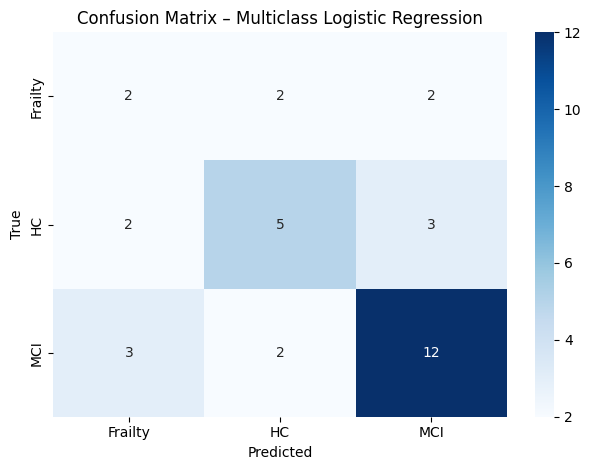


Specificity per class (One-vs-Rest):
Frailty: 0.815
HC: 0.826
MCI: 0.688


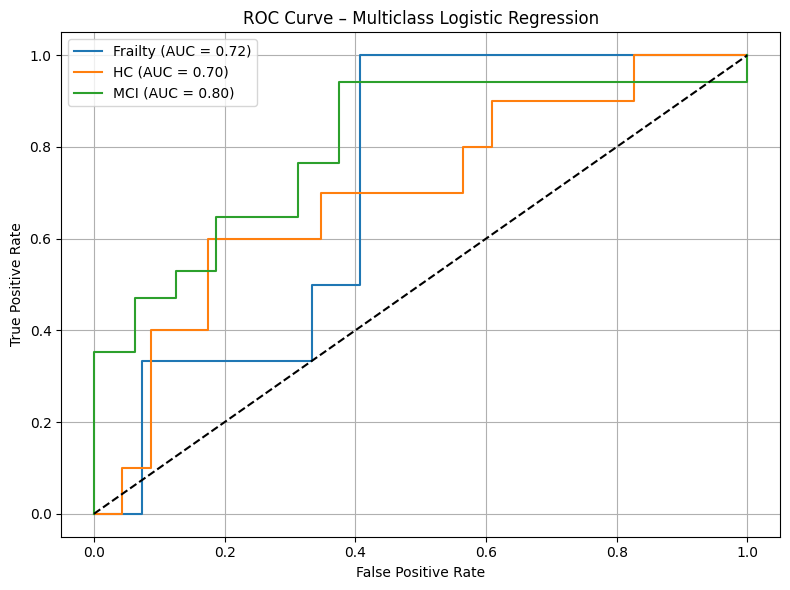

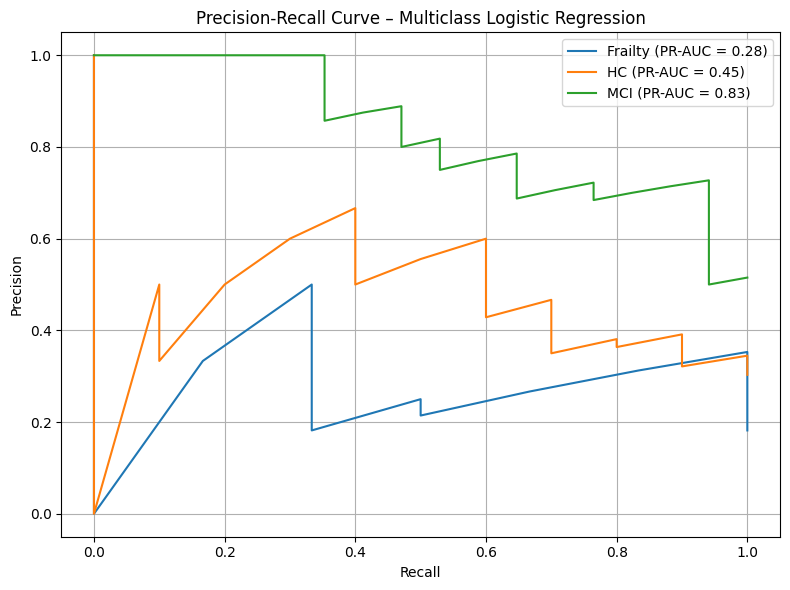


Coefficients per class (OvR):
                          Frailty     HC    MCI
TMT-B                      -0.649  0.446  0.125
TMT-B-A                     0.368 -0.540 -0.123
FAB                         1.085  0.594 -1.353
MFPT-UD                    -0.367  1.351 -0.942
MFPT-CS                     0.591 -0.788  0.321
Fluency S                   0.085  0.509 -0.768
Fluency A                   0.461  0.620 -1.209
Fluency Shifting           -0.513  0.016  0.469
STROOP-STIR                -0.468  0.289  0.182
PIT (s)                    -0.828  0.591 -0.035
PIT (n. correct answers)    0.800 -0.128 -0.355
PIT (elements)              1.069 -0.120 -0.835

Top features for class Frailty:
FAB                         1.084764
PIT (elements)              1.069371
PIT (s)                    -0.828259
PIT (n. correct answers)    0.800409
TMT-B                      -0.649123
MFPT-CS                     0.591056
Fluency Shifting           -0.513204
STROOP-STIR                -0.467670
Fluency A       

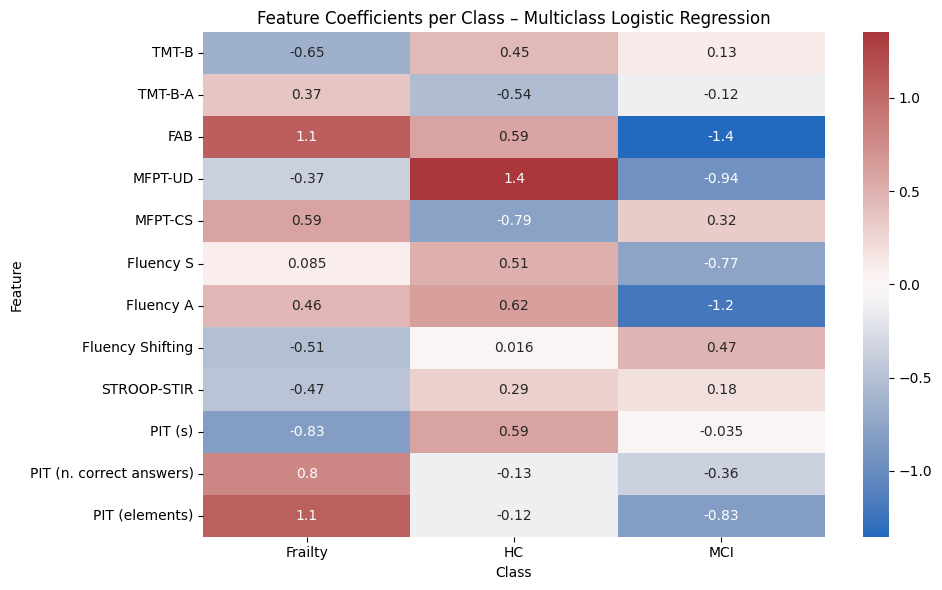

In [40]:
#Feature set 
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

#Target: multiclass
y = df_n['group']  

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

#Train Logistic Regression (OvR)
model = LogisticRegression(C=1, solver='lbfgs', multi_class='ovr', max_iter=1000)
model.fit(X_train, y_train)

#Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

#Classification report
print("Logistic Regression Multiclass")
print(classification_report(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Multiclass Logistic Regression")
plt.tight_layout()
plt.show()

print("\nSpecificity per class (One-vs-Rest):")
specificities = {}
for i, cls in enumerate(model.classes_):
    y_true_bin = (y_test == cls).astype(int)
    y_pred_bin = (y_pred == cls).astype(int)
    cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    if cm_bin.shape == (2, 2):
        tn, fp, fn, tp = cm_bin.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        specificities[cls] = specificity
        print(f"{cls}: {specificity:.3f}")
    else:
        specificities[cls] = np.nan
        print(f"{cls}: Not computable (only one class present)")

#Binarize y_test for One-vs-Rest metrics
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

#ROC Curves per class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve – Multiclass Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#PR Curves per class
plt.figure(figsize=(8, 6))
pr_aucs = []
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    plt.plot(recall, precision, label=f"{model.classes_[i]} (PR-AUC = {pr_auc:.2f})")

plt.title("Precision-Recall Curve – Multiclass Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Macro metrics dictionary
metrics_dict = {
    "Model": "Multiclass Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision (macro)": precision_score(y_test, y_pred, average='macro', zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average='macro'),
    "F1-score (macro)": f1_score(y_test, y_pred, average='macro'),
    "ROC-AUC (macro)": roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'),
    "PR-AUC (macro)": np.mean(pr_aucs),
    "Specificity (HC)": specificities.get('HC', np.nan),
    "Specificity (Frailty)": specificities.get('Frailty', np.nan),
    "Specificity (MCI)": specificities.get('MCI', np.nan)
}

#Save metrics
try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

#Coefficients per class
coef_df = pd.DataFrame(model.coef_.T, index=X.columns, columns=model.classes_)
print("\nCoefficients per class (OvR):")
print(coef_df.round(3))

#Top features per class
for cls in model.classes_:
    print(f"\nTop features for class {cls}:")
    print(coef_df[cls].sort_values(key=abs, ascending=False).head(10))

# Plot all coefficients in a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=True, cmap="vlag", center=0)
plt.title("Feature Coefficients per Class – Multiclass Logistic Regression")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Multiclass with bootstrapping

In [41]:
#Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

# Binarize y_test
y_test_bin = label_binarize(y_test, classes=model.classes_)
y_proba = model.predict_proba(X_test)


boot_metrics = {
    "accuracy": [],
    "precision_macro": [],
    "recall_macro": [],
    "f1_macro": [],
    "roc_auc_macro": [],
    "pr_auc_macro": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = model.predict(X_test.iloc[indices])
    y_proba_b = model.predict_proba(X_test.iloc[indices])

    # Skip if any class is missing
    if len(np.unique(y_true_b)) < 2:
        continue

    y_true_bin_b = label_binarize(y_true_b, classes=model.classes_)

    # PR-AUC macro
    pr_auc_list = []
    for i in range(len(model.classes_)):
        prec, rec, _ = precision_recall_curve(y_true_bin_b[:, i], y_proba_b[:, i])
        if len(prec) > 1:
            pr_auc_list.append(auc(rec, prec))
    pr_auc_macro = np.mean(pr_auc_list)

    # ROC-AUC macro
    try:
        roc_auc_macro = roc_auc_score(y_true_bin_b, y_proba_b, average='macro', multi_class='ovr')
    except ValueError:
        roc_auc_macro = np.nan

 
    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision_macro"].append(precision_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    boot_metrics["recall_macro"].append(recall_score(y_true_b, y_pred_b, average='macro'))
    boot_metrics["f1_macro"].append(f1_score(y_true_b, y_pred_b, average='macro'))
    boot_metrics["roc_auc_macro"].append(roc_auc_macro)
    boot_metrics["pr_auc_macro"].append(pr_auc_macro)


print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    values = np.array(values)
    mean_val = np.nanmean(values)
    std_val = np.nanstd(values)
    ci_low = np.nanpercentile(values, 2.5)
    ci_high = np.nanpercentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

#Coefficients per class
print("\nCoefficients by class (one-vs-rest):")
coef_df = pd.DataFrame(model.coef_.T, index=X_test.columns, columns=model.classes_)
print(coef_df.round(3))



Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.576 ± 0.087 | 95% CI [0.394, 0.758]
PRECISION_MACRO: 0.517 ± 0.095 | 95% CI [0.337, 0.708]
RECALL_MACRO: 0.513 ± 0.098 | 95% CI [0.325, 0.708]
F1_MACRO: 0.502 ± 0.092 | 95% CI [0.326, 0.670]
ROC_AUC_MACRO: 0.737 ± 0.065 | 95% CI [0.614, 0.863]
PR_AUC_MACRO: 0.536 ± 0.076 | 95% CI [0.417, 0.707]

Coefficients by class (one-vs-rest):
                          Frailty     HC    MCI
TMT-B                      -0.649  0.446  0.125
TMT-B-A                     0.368 -0.540 -0.123
FAB                         1.085  0.594 -1.353
MFPT-UD                    -0.367  1.351 -0.942
MFPT-CS                     0.591 -0.788  0.321
Fluency S                   0.085  0.509 -0.768
Fluency A                   0.461  0.620 -1.209
Fluency Shifting           -0.513  0.016  0.469
STROOP-STIR                -0.468  0.289  0.182
PIT (s)                    -0.828  0.591 -0.035
PIT (n. correct answers)    0.800 -0.128 -0.355
PIT (elements)              1.069

### Multiclass LR with SMOTE

Logistic Regression Multiclass – SMOTE
              precision    recall  f1-score   support

     Frailty       0.25      0.33      0.29         6
          HC       0.50      0.60      0.55        10
         MCI       0.77      0.59      0.67        17

    accuracy                           0.55        33
   macro avg       0.51      0.51      0.50        33
weighted avg       0.59      0.55      0.56        33



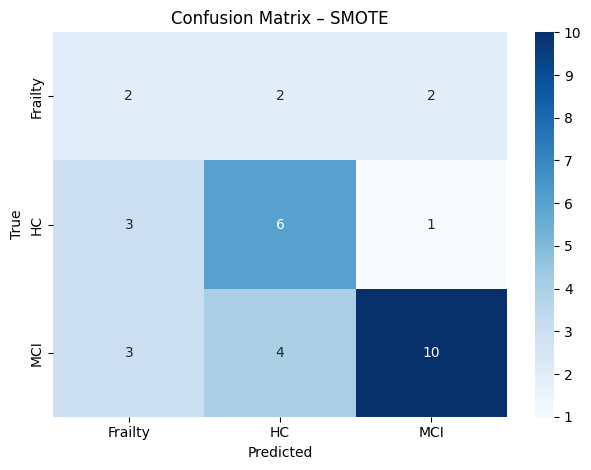


Specificity per class (One-vs-Rest):
Frailty: 0.778
HC: 0.739
MCI: 0.812


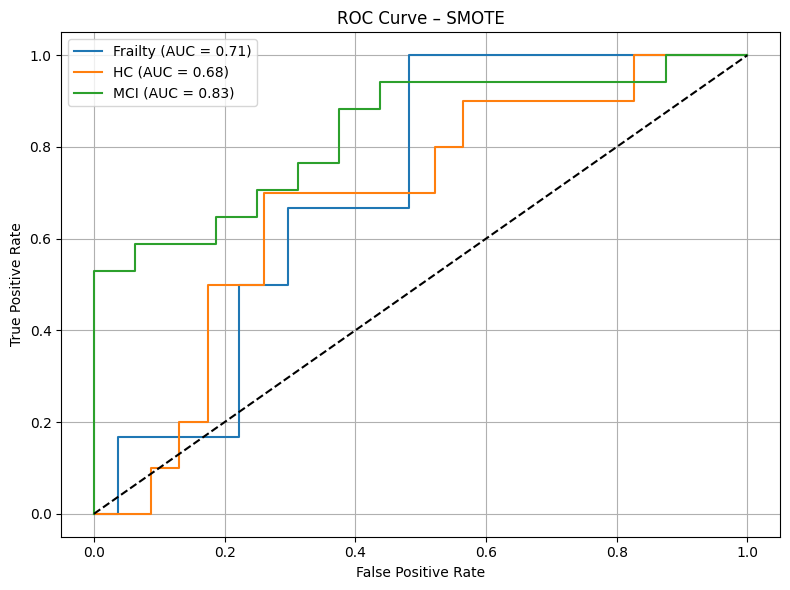

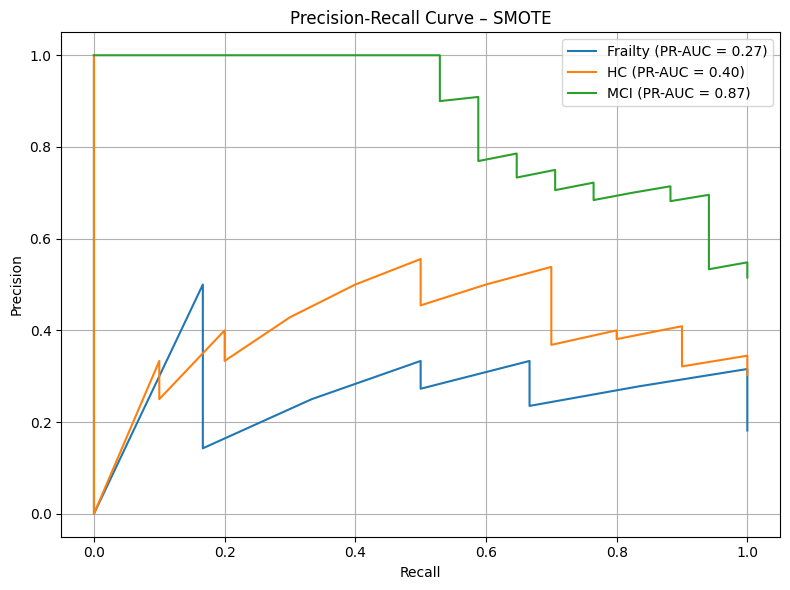


Coefficients per class (SMOTE):
                          Frailty     HC    MCI
TMT-B                      -1.208  0.879  0.396
TMT-B-A                     0.320 -0.676 -0.108
FAB                         1.447  0.365 -1.577
MFPT-UD                    -0.637  1.656 -0.969
MFPT-CS                     0.908 -0.932  0.239
Fluency S                   0.004  0.426 -0.904
Fluency A                   0.350  0.939 -1.508
Fluency Shifting           -0.771  0.118  0.553
STROOP-STIR                -0.245  0.182  0.162
PIT (s)                    -1.252  0.689  0.226
PIT (n. correct answers)    1.176 -0.389 -0.520
PIT (elements)              1.496 -0.614 -1.001


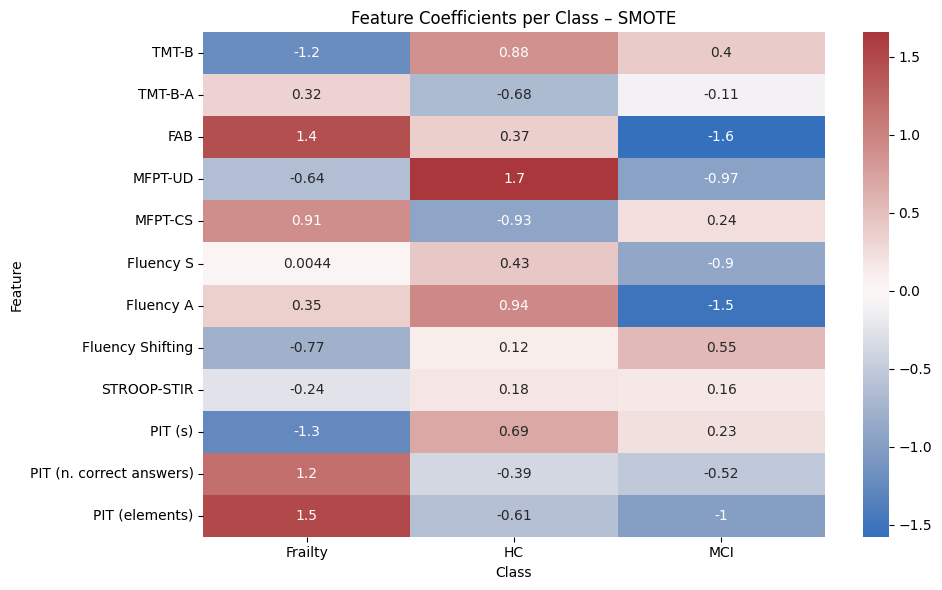

In [42]:
#Feature set
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

#Multiclass target
y = df_n['group']  

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

#Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#Train model
model = LogisticRegression(C=1, solver='lbfgs', multi_class='ovr', max_iter=1000)
model.fit(X_train_res, y_train_res)

#Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

#Report
print("Logistic Regression Multiclass – SMOTE")
print(classification_report(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – SMOTE")
plt.tight_layout()
plt.show()

#Specificity per class (OvR)
print("\nSpecificity per class (One-vs-Rest):")
specificities = {}
for cls in model.classes_:
    y_true_bin = (y_test == cls).astype(int)
    y_pred_bin = (y_pred == cls).astype(int)
    cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    if cm_bin.shape == (2, 2):
        tn, fp, fn, tp = cm_bin.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        specificities[cls] = specificity
        print(f"{cls}: {specificity:.3f}")
    else:
        specificities[cls] = np.nan
        print(f"{cls}: Not computable")

#ROC and PR curves
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

#ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve – SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#PR curves
plt.figure(figsize=(8, 6))
pr_aucs = []
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    plt.plot(recall, precision, label=f"{model.classes_[i]} (PR-AUC = {pr_auc:.2f})")

plt.title("Precision-Recall Curve – SMOTE")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Save metrics to dictionary
metrics_dict = {
    "Model": "Multiclass Logistic Regression – SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision (macro)": precision_score(y_test, y_pred, average='macro', zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average='macro'),
    "F1-score (macro)": f1_score(y_test, y_pred, average='macro'),
    "ROC-AUC (macro)": roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'),
    "PR-AUC (macro)": np.mean(pr_aucs),
    "Specificity (HC)": specificities.get('HC', np.nan),
    "Specificity (Frailty)": specificities.get('Frailty', np.nan),
    "Specificity (MCI)": specificities.get('MCI', np.nan)
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

#Coefficients per class
coef_df = pd.DataFrame(model.coef_.T, index=X.columns, columns=model.classes_)
print("\nCoefficients per class (SMOTE):")
print(coef_df.round(3))

#Plot heatmap of coefficients
plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=True, cmap="vlag", center=0)
plt.title("Feature Coefficients per Class – SMOTE")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Attemp 2: Multiple binaries classifications

Multiple binary classifications (MCI vs All, MCI vs Frailty, HC vs Frailty) were performed with the following models (LASSO LR, DT, KNN) and resampling techniques (random oversampling and undersampling, depending on the disparity)

In [45]:
df_mci_all = df_n[df_n['group'].isin(['MCI', 'HC', 'Frailty'])].copy()
X = df_mci_all[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Recode target as binary: 1 = MCI, 0 = all others
y = df_mci_all['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Train LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]  # Probabilità per classe 1

# Evaluation
print("MCI vs All – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


MCI vs All – LDA
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.77      0.59      0.67        17

    accuracy                           0.70        33
   macro avg       0.71      0.70      0.69        33
weighted avg       0.71      0.70      0.69        33

ROC-AUC: 0.7573529411764706


In [48]:
df_hc_frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Features
X = df_hc_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Label: 1 = Frailty, 0 = HC
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LDA training
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]

# Results
print("HC vs Frailty – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

HC vs Frailty – LDA
              precision    recall  f1-score   support

           0       0.64      0.70      0.67        10
           1       0.40      0.33      0.36         6

    accuracy                           0.56        16
   macro avg       0.52      0.52      0.52        16
weighted avg       0.55      0.56      0.55        16

ROC-AUC: 0.65


In [51]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Label: 1 = Frailty, 0 = MCI
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LDA training
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]

# Results
print("Frailty vs MCI – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Frailty vs MCI – LDA
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        18
           1       1.00      0.33      0.50         6

    accuracy                           0.83        24
   macro avg       0.91      0.67      0.70        24
weighted avg       0.86      0.83      0.80        24

ROC-AUC: 0.8703703703703705


In [46]:
features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

def run_pipeline(target_mapping, label, sampling=None):
    df_copy = df_n.copy()
    df_copy['Target'] = df_copy['group'].map(target_mapping)
    df_copy = df_copy[df_copy['Target'].isin([0, 1])]

    X = df_copy[features]
    y = df_copy['Target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

    if sampling == "over":
        ros = RandomOverSampler(random_state=42)
        X_train, y_train = ros.fit_resample(X_train, y_train)
    elif sampling == "under":
        rus = RandomUnderSampler(random_state=42)
        X_train, y_train = rus.fit_resample(X_train, y_train)

    models = {
        "LASSO Logistic Regression": LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'),
        "Decision Tree": DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
        "KNN (k=3)": KNeighborsClassifier(n_neighbors=3)
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        results.append({
            "Label": label,
            "Sampling": sampling or "none",
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "Specificity": spec,
            "F1-score": f1,
            "ROC-AUC": auc
        })

    return results

all_results = []

# MCI vs ALL – none and oversampling
all_results += run_pipeline({'MCI': 1, 'HC': 0, 'Frailty': 0}, 'MCI vs ALL', sampling=None)
all_results += run_pipeline({'MCI': 1, 'HC': 0, 'Frailty': 0}, 'MCI vs ALL', sampling='over')

# HC vs FRAILTY – none and oversampling
all_results += run_pipeline({'HC': 0, 'Frailty': 1}, 'HC vs FRAILTY', sampling=None)
all_results += run_pipeline({'HC': 0, 'Frailty': 1}, 'HC vs FRAILTY', sampling='over')

# MCI vs FRAILTY – none and undersampling
all_results += run_pipeline({'MCI': 1, 'Frailty': 0}, 'MCI vs FRAILTY', sampling=None)
all_results += run_pipeline({'MCI': 1, 'Frailty': 0}, 'MCI vs FRAILTY', sampling='under')


results_df = pd.DataFrame(all_results).round(3)
best_models_df = results_df.loc[results_df.groupby("Label")["F1-score"].idxmax()].reset_index(drop=True)


results_df, best_models_df


(             Label Sampling                      Model  Accuracy  Precision  \
 0       MCI vs ALL     none  LASSO Logistic Regression     0.697      0.769   
 1       MCI vs ALL     none              Decision Tree     0.545      0.538   
 2       MCI vs ALL     none                  KNN (k=3)     0.636      0.692   
 3       MCI vs ALL     over  LASSO Logistic Regression     0.697      0.769   
 4       MCI vs ALL     over              Decision Tree     0.727      0.722   
 5       MCI vs ALL     over                  KNN (k=3)     0.636      0.692   
 6    HC vs FRAILTY     none  LASSO Logistic Regression     0.625      0.500   
 7    HC vs FRAILTY     none              Decision Tree     0.562      0.400   
 8    HC vs FRAILTY     none                  KNN (k=3)     0.438      0.200   
 9    HC vs FRAILTY     over  LASSO Logistic Regression     0.562      0.429   
 10   HC vs FRAILTY     over              Decision Tree     0.500      0.400   
 11   HC vs FRAILTY     over            

# Attempt 3: LASSO LR

## MCI vs All

Cross-Validation Results (5-fold):
Accuracy: 0.782 ± 0.034
F1-score: 0.790 ± 0.042
ROC-AUC:  0.891 ± 0.065
PR-AUC:   0.924 ± 0.049
MCI vs (HC + Frailty)
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.77      0.59      0.67        17

    accuracy                           0.70        33
   macro avg       0.71      0.70      0.69        33
weighted avg       0.71      0.70      0.69        33

Accuracy: 0.697
Precision: 0.769
Recall (Sensitivity): 0.588
Specificity: 0.812
F1-score: 0.667
ROC-AUC: 0.831
PR-AUC: 0.867

Non-zero coefficients (LASSO-selected features):
             Feature  Coefficient
6          Fluency A    -1.130907
2                FAB    -1.111070
3            MFPT-UD    -0.934153
5          Fluency S    -0.611875
11    PIT (elements)    -0.462936
8        STROOP-STIR     0.260215
7   Fluency Shifting     0.121531
0              TMT-B     0.029187


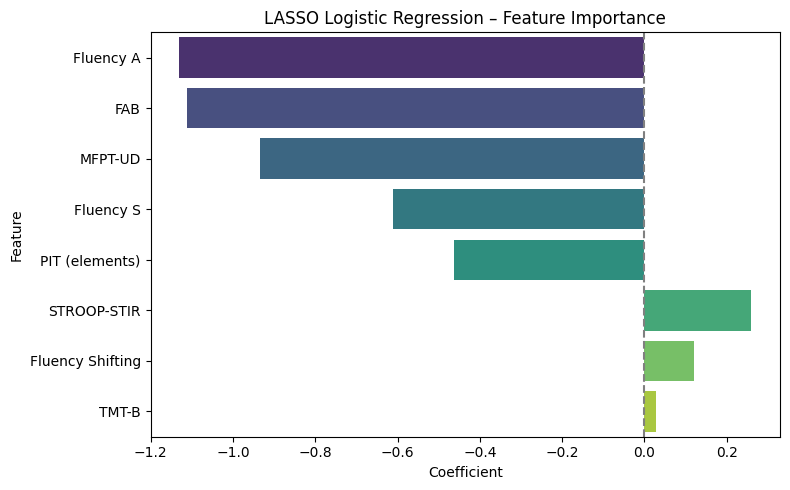

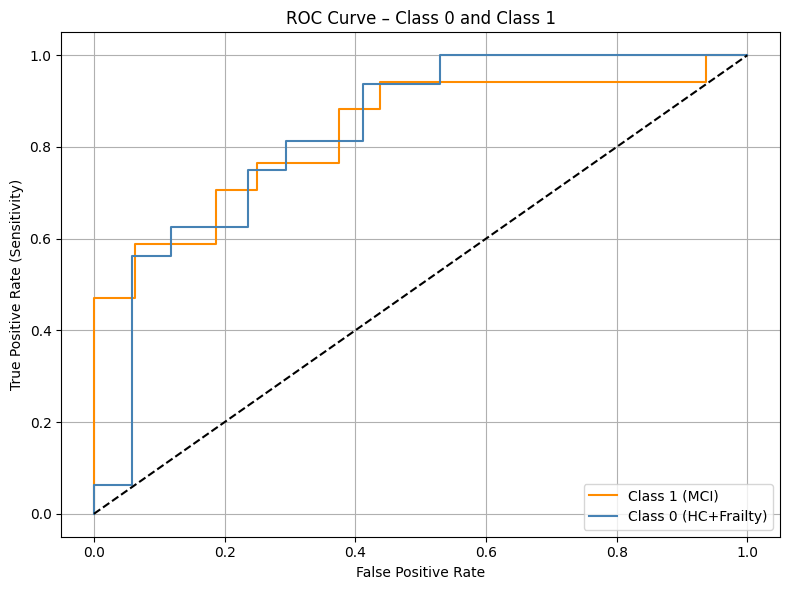

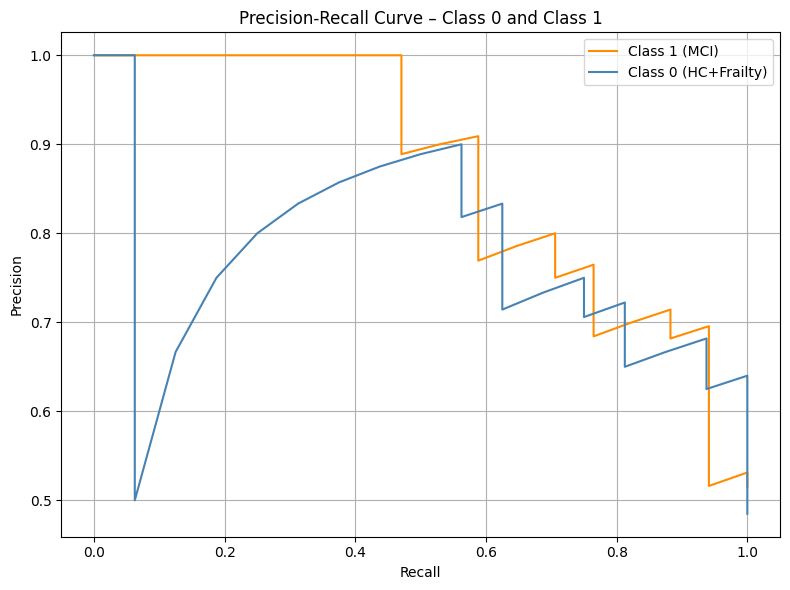

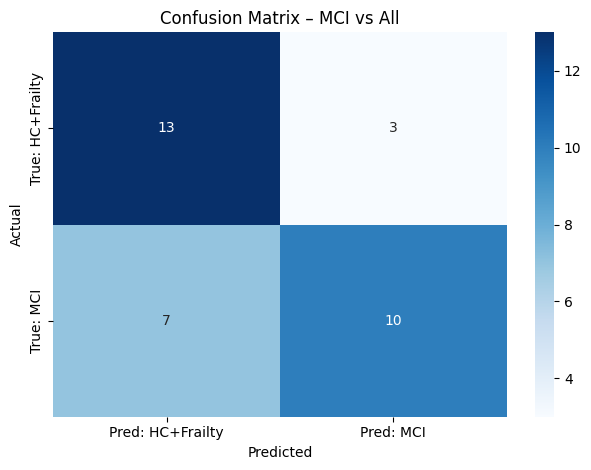


Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.695 ± 0.081 | 95% CI [0.545, 0.848]
PRECISION: 0.764 ± 0.118 | 95% CI [0.500, 1.000]
RECALL: 0.589 ± 0.122 | 95% CI [0.353, 0.818]
SPECIFICITY: 0.807 ± 0.099 | 95% CI [0.583, 1.000]
F1: 0.658 ± 0.103 | 95% CI [0.435, 0.839]
ROC_AUC: 0.829 ± 0.075 | 95% CI [0.673, 0.956]
PR_AUC: 0.863 ± 0.068 | 95% CI [0.693, 0.964]

Training set metrics:
Accuracy: 0.870
Precision: 0.943
Recall (Sensitivity): 0.805
Specificity: 0.944
F1-score: 0.868
ROC-AUC: 0.955
PR-AUC: 0.966


In [47]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target
y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LASSO Model
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)  # same as sensitivity
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)


print("MCI vs (HC + Frailty)")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Extract and display non-zero coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Keep only non-zero coefficients
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("\nNon-zero coefficients (LASSO-selected features):")
print(coef_df[['Feature', 'Coefficient']])


plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()


# ROC Curve for both classes
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve for both classes
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 (MCI)', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All")
plt.tight_layout()
plt.show()

# Bootstrapping all metrics
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    # Skip if only one class
    if len(np.unique(y_true_b)) < 2:
        continue

    
    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue  # skip bootstrap samples with invalid confusion matrix

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    # Metrics
    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

# Print bootstrapped results
print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

# Training set metrics
y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
tn_t, fp_t, fn_t, tp_t = cm_train.ravel()
specificity_train = tn_t / (tn_t + fp_t)
sensitivity_train = tp_t / (tp_t + fn_t)

acc_train = accuracy_score(y_train, y_train_pred)
prec_train = precision_score(y_train, y_train_pred, zero_division=0)
rec_train = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
roc_auc_train = roc_auc_score(y_train, y_train_proba)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_train_proba)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("\nTraining set metrics:")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO Logistic",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

## +MCI vs All (with random oversampling)

Cross-Validation Results (5-fold):
Accuracy: 0.782 ± 0.034
F1-score: 0.790 ± 0.042
ROC-AUC:  0.894 ± 0.065
PR-AUC:   0.922 ± 0.053
Training set metrics
Accuracy: 0.890
Precision: 0.944
Recall (Sensitivity): 0.829
Specificity: 0.951
F1-score: 0.883
ROC-AUC: 0.960
PR-AUC: 0.966
Test set metrics
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.77      0.59      0.67        17

    accuracy                           0.70        33
   macro avg       0.71      0.70      0.69        33
weighted avg       0.71      0.70      0.69        33

Accuracy: 0.697
Precision: 0.769
Recall (Sensitivity): 0.588
Specificity: 0.812
F1-score: 0.667
ROC-AUC: 0.824
PR-AUC: 0.859


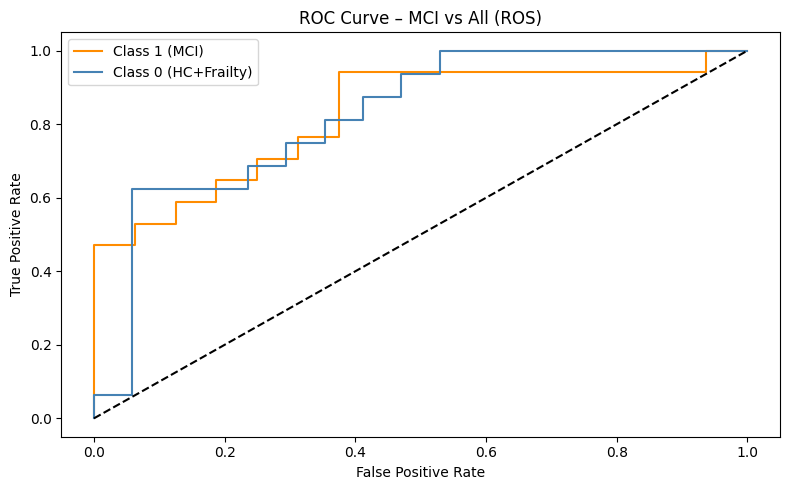

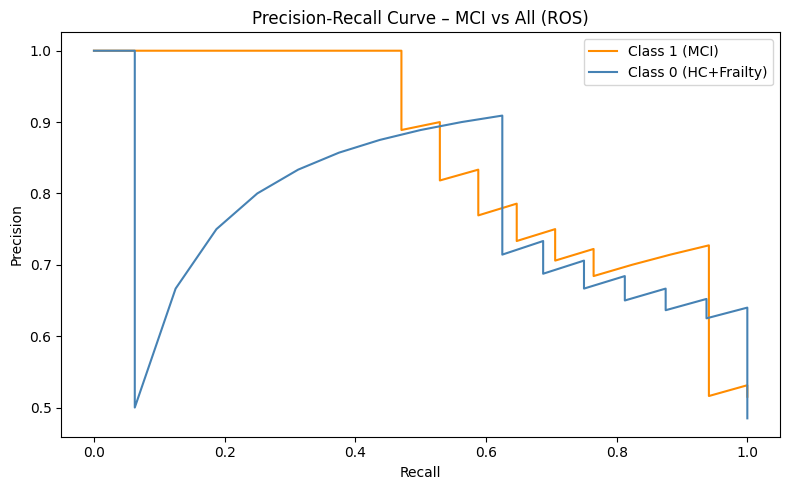

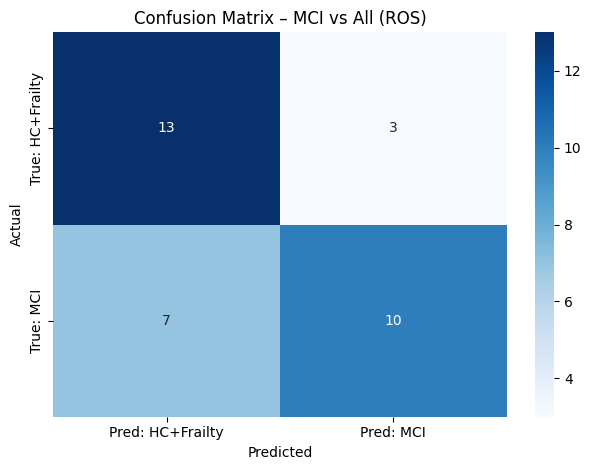

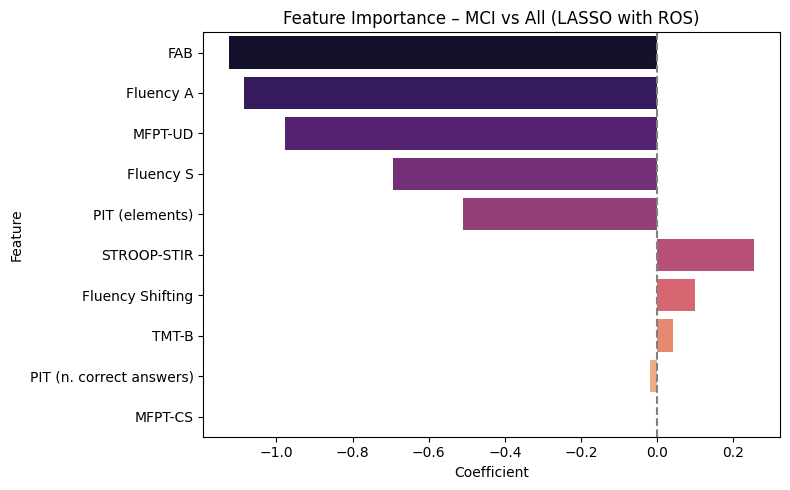

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.695 ± 0.081 | 95% CI [0.545, 0.848]
PRECISION: 0.764 ± 0.118 | 95% CI [0.500, 1.000]
RECALL: 0.589 ± 0.122 | 95% CI [0.353, 0.818]
SPECIFICITY: 0.807 ± 0.099 | 95% CI [0.583, 1.000]
F1: 0.658 ± 0.103 | 95% CI [0.435, 0.839]
ROC_AUC: 0.822 ± 0.077 | 95% CI [0.665, 0.954]
PR_AUC: 0.855 ± 0.070 | 95% CI [0.687, 0.962]


In [48]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('ros', RandomOverSampler(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train_ros, y_train_ros)

y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()
specificity_test = tn / (tn + fp)
sensitivity_test = tp / (tp + fn)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
precision_vals_test, recall_vals_test, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc_test = auc(recall_vals_test, precision_vals_test)

y_pred_train = model.predict(X_train_ros)
y_proba_train = model.predict_proba(X_train_ros)[:, 1]

cm_train = confusion_matrix(y_train_ros, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

acc_train = accuracy_score(y_train_ros, y_pred_train)
prec_train = precision_score(y_train_ros, y_pred_train, zero_division=0)
rec_train = recall_score(y_train_ros, y_pred_train)
f1_train = f1_score(y_train_ros, y_pred_train)
roc_auc_train = roc_auc_score(y_train_ros, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train_ros, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("Training set metrics")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred_test))
print(f"Accuracy: {acc_test:.3f}")
print(f"Precision: {prec_test:.3f}")
print(f"Recall (Sensitivity): {rec_test:.3f}")
print(f"Specificity: {specificity_test:.3f}")
print(f"F1-score: {f1_test:.3f}")
print(f"ROC-AUC: {roc_auc_test:.3f}")
print(f"PR-AUC: {pr_auc_test:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO (ROS)",
    "Accuracy": acc_test,
    "Precision": prec_test,
    "Recall (Sensitivity)": rec_test,
    "Specificity": specificity_test,
    "F1-score": f1_test,
    "ROC-AUC": roc_auc_test,
    "PR-AUC": pr_auc_test
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

fpr1, tpr1, _ = roc_curve(y_test, y_proba_test)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5), facecolor='white') 
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs All (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.grid(False)
plt.show()

prec1, rec1, _ = precision_recall_curve(y_test, y_proba_test)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5), facecolor='white') 
plt.plot(rec1, prec1, label='Class 1 (MCI)', color='darkorange')
plt.plot(rec0, prec0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs All (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.grid(False)
plt.show()

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All (ROS)")
plt.tight_layout()
plt.show()

coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – MCI vs All (LASSO with ROS)')
plt.tight_layout()
plt.show()

n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred_test[indices]
    y_proba_b = y_proba_test[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## MCI vs All (with SMOTE)

Cross-Validation Results (5-fold):
Accuracy: 0.782 ± 0.034
F1-score: 0.790 ± 0.042
ROC-AUC:  0.882 ± 0.072
PR-AUC:   0.919 ± 0.054
Training set metrics
Accuracy: 0.890
Precision: 0.944
Recall (Sensitivity): 0.829
Specificity: 0.951
F1-score: 0.883
ROC-AUC: 0.960
PR-AUC: 0.967
Test set metrics
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.77      0.59      0.67        17

    accuracy                           0.70        33
   macro avg       0.71      0.70      0.69        33
weighted avg       0.71      0.70      0.69        33

Accuracy: 0.697
Precision: 0.769
Recall (Sensitivity): 0.588
Specificity: 0.812
F1-score: 0.667
ROC-AUC: 0.827
PR-AUC: 0.868


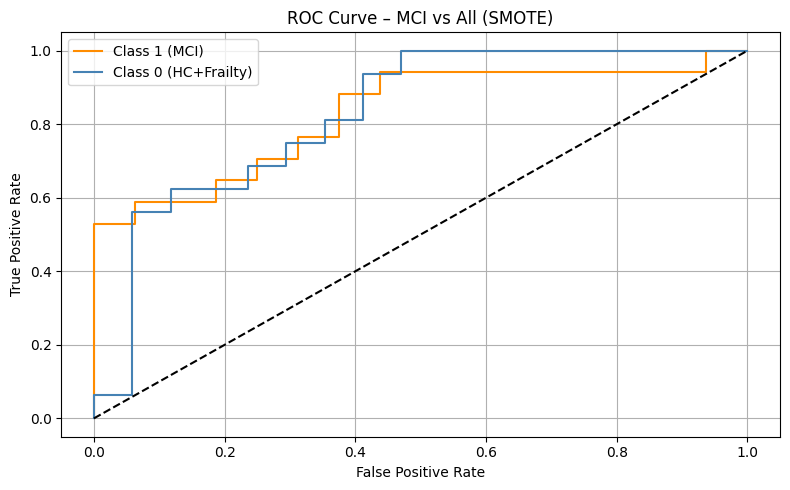

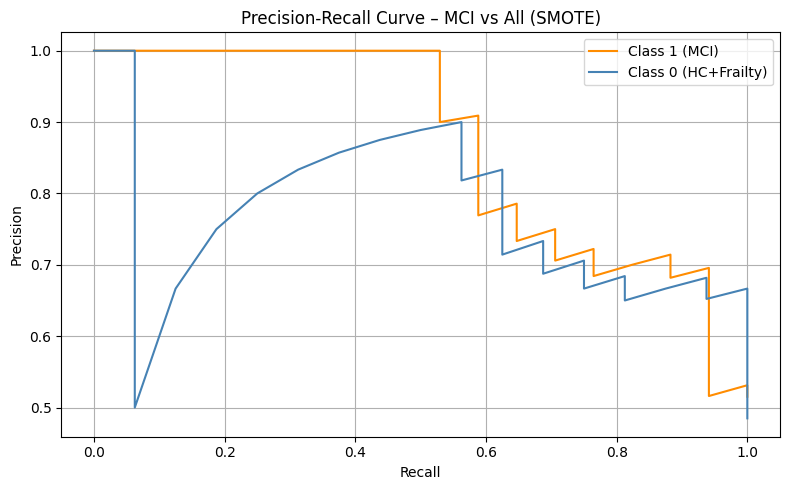

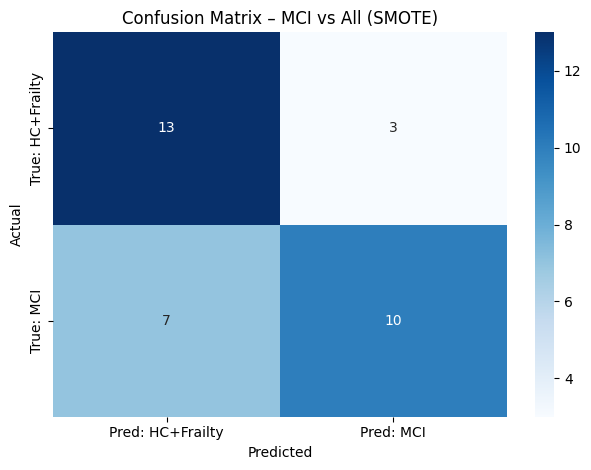

Selected non-zero coefficients
                     Feature  Coefficient
6                  Fluency A    -1.309436
2                        FAB    -1.182392
3                    MFPT-UD    -0.945341
5                  Fluency S    -0.579055
11            PIT (elements)    -0.511824
7           Fluency Shifting     0.245211
8                STROOP-STIR     0.233233
10  PIT (n. correct answers)    -0.016583


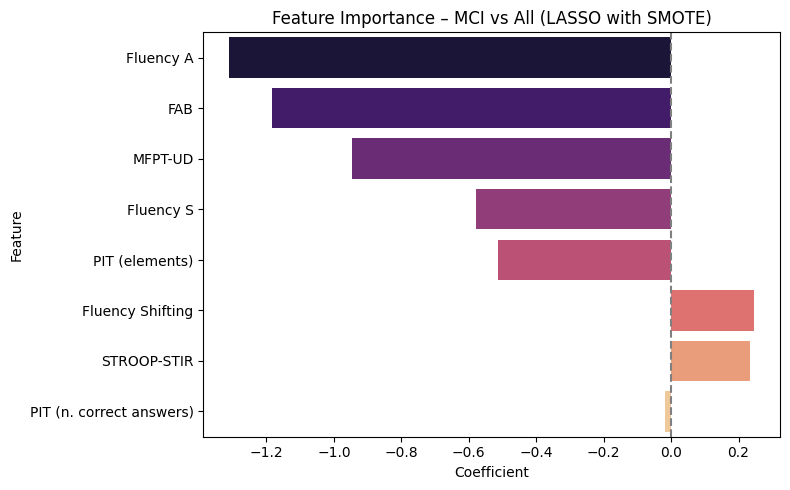

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.695 ± 0.081 | 95% CI [0.545, 0.848]
PRECISION: 0.764 ± 0.118 | 95% CI [0.500, 1.000]
RECALL: 0.589 ± 0.122 | 95% CI [0.353, 0.818]
SPECIFICITY: 0.807 ± 0.099 | 95% CI [0.583, 1.000]
F1: 0.658 ± 0.103 | 95% CI [0.435, 0.839]
ROC_AUC: 0.826 ± 0.076 | 95% CI [0.665, 0.954]
PR_AUC: 0.864 ± 0.067 | 95% CI [0.707, 0.963]


In [49]:
#MCI vs All (SMOTE)
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train_smote, y_train_smote)

# Test set evaluation
y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()
specificity_test = tn / (tn + fp)
sensitivity_test = tp / (tp + fn)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
precision_vals_test, recall_vals_test, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc_test = auc(recall_vals_test, precision_vals_test)

# Training set evaluation
y_pred_train = model.predict(X_train_smote)
y_proba_train = model.predict_proba(X_train_smote)[:, 1]

cm_train = confusion_matrix(y_train_smote, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

acc_train = accuracy_score(y_train_smote, y_pred_train)
prec_train = precision_score(y_train_smote, y_pred_train, zero_division=0)
rec_train = recall_score(y_train_smote, y_pred_train)
f1_train = f1_score(y_train_smote, y_pred_train)
roc_auc_train = roc_auc_score(y_train_smote, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train_smote, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("Training set metrics")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred_test))
print(f"Accuracy: {acc_test:.3f}")
print(f"Precision: {prec_test:.3f}")
print(f"Recall (Sensitivity): {rec_test:.3f}")
print(f"Specificity: {specificity_test:.3f}")
print(f"F1-score: {f1_test:.3f}")
print(f"ROC-AUC: {roc_auc_test:.3f}")
print(f"PR-AUC: {pr_auc_test:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO (SMOTE)",
    "Accuracy": acc_test,
    "Precision": prec_test,
    "Recall (Sensitivity)": rec_test,
    "Specificity": specificity_test,
    "F1-score": f1_test,
    "ROC-AUC": roc_auc_test,
    "PR-AUC": pr_auc_test
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba_test)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5))
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs All (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba_test)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5))
plt.plot(rec1, prec1, label='Class 1 (MCI)', color='darkorange')
plt.plot(rec0, prec0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs All (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All (SMOTE)")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – MCI vs All (LASSO with SMOTE)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred_test[indices]
    y_proba_b = y_proba_test[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


The best performing model for MCI vs All classification was the one with ROS. It has the best F1 score, recall, and accuracy, maintaining excellent precision and AUC: ideal for detecting MCI with high sensitivity and reliability.

### Performance full model vs no PIT model for MCI vs all

             Accuracy  Precision  Recall (Sensitivity)  Specificity     F1  \
With PIT        0.697      0.769                 0.588        0.812  0.667   
Without PIT     0.727      0.722                 0.765        0.688  0.743   

             ROC-AUC  PR-AUC  
With PIT       0.824   0.859  
Without PIT    0.838   0.881  


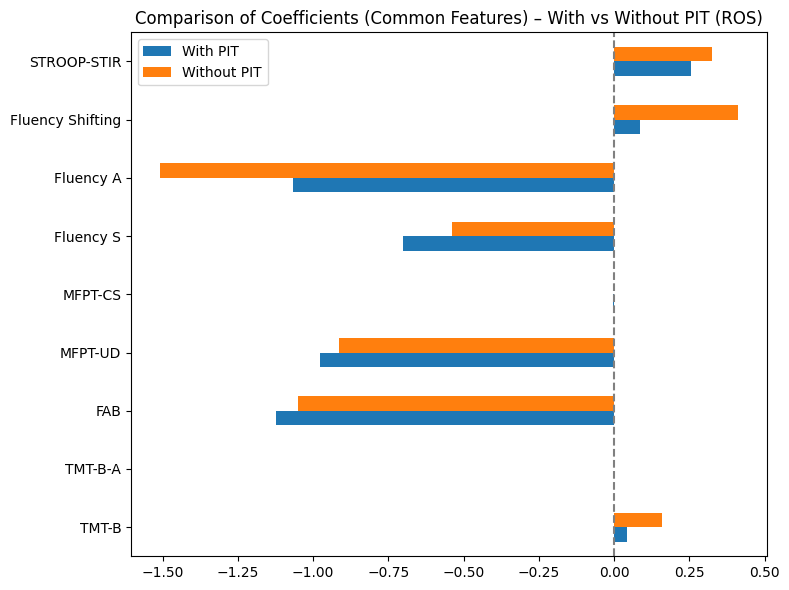

In [50]:
# LASSO LR with ROS
# PIT features
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Full feature set
X_full = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
               'Fluency S', 'Fluency A', 'Fluency Shifting',
               'STROOP-STIR'] + pit_features]

# Feature set without PIT
X_nopit = X_full.drop(columns=pit_features)

# Target
y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Train-test split
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.3, random_state=42)
X_train_np, X_test_np = X_nopit.loc[X_train_f.index], X_nopit.loc[X_test_f.index]

# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_train_f_ros, y_train_ros = ros.fit_resample(X_train_f, y_train)
X_train_np_ros, _ = ros.fit_resample(X_train_np, y_train)  # Use same indices

# Train LASSO models
model_full = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_nopit = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')

model_full.fit(X_train_f_ros, y_train_ros)
model_nopit.fit(X_train_np_ros, y_train_ros)

# Predictions
y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]

y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

# Metrics
def compute_metrics(y_true, y_pred, y_proba):
    prec, recall, _ = precision_recall_curve(y_true, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Sensitivity)': recall_score(y_true, y_pred),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': auc(recall, prec)
    }

results = pd.DataFrame({
    'With PIT': compute_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': compute_metrics(y_test, y_pred_np, y_proba_np)
}).T.round(3)

print(results)

# Coefficients
coef_f = pd.Series(model_full.coef_[0], index=X_full.columns)
coef_np = pd.Series(model_nopit.coef_[0], index=X_nopit.columns)

common_features = [col for col in coef_f.index if col in coef_np.index]
df_coef_compare = pd.DataFrame({
    'With PIT': coef_f[common_features],
    'Without PIT': coef_np[common_features]
})

df_coef_compare.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title("Comparison of Coefficients (Common Features) – With vs Without PIT (ROS)")
plt.tight_layout()
plt.show()

### Permutation importance for model: MCI vs all

In [51]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)


model_full = LogisticRegression(penalty='l1', solver='liblinear')
model_full.fit(X_train_ros, y_train_ros)


def safe_roc_auc(estimator, X, y):
    if len(np.unique(y)) < 2:
        return 0.0
    y_scores = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, y_scores)


result = permutation_importance(
    estimator=model_full,
    X=X_test,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring=safe_roc_auc  # <-- FIX QUI
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values(by='Importance', ascending=False)

print("\nPermutation Importance (based on ROC-AUC, MCI vs All):")
print(perm_df)


threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered = perm_df_filtered.sort_values(by='Importance', ascending=False)


error_bar_factor = 0.05 
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * error_bar_factor


fig = px.bar(
    perm_df_filtered,
    x='Importance',
    y='Feature',
    title="Permutation Importance – MCI vs All (RO)",
    labels={'Importance': 'Mean decrease in ROC-AUC when feature is permuted', 'Feature': 'Feature'},
    error_x='Reduced_Std',
    color='Importance',
    color_continuous_scale='Viridis',
)

fig.update_layout(
    showlegend=False,
    xaxis_title="Mean decrease in ROC-AUC when feature is permuted",
    yaxis_title="Feature",
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True, autorange="reversed"),
    plot_bgcolor="white"
)

fig.show()


Permutation Importance (based on ROC-AUC, MCI vs All):
                     Feature  Importance       Std
6                  Fluency A    0.115686  0.051887
2                        FAB    0.105270  0.057636
3                    MFPT-UD    0.030515  0.038910
8                STROOP-STIR    0.026471  0.016589
5                  Fluency S    0.017525  0.032229
11            PIT (elements)    0.008088  0.033459
0                      TMT-B    0.002328  0.004976
1                    TMT-B-A    0.000000  0.000000
4                    MFPT-CS    0.000000  0.000000
9                    PIT (s)    0.000000  0.000000
10  PIT (n. correct answers)   -0.000980  0.002312
7           Fluency Shifting   -0.003799  0.008516


### +MCI vs All (with semantic metrics)

Test Set Metrics – MCI vs (HC + Frailty)
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.86      0.71      0.77        17

    accuracy                           0.79        33
   macro avg       0.80      0.79      0.79        33
weighted avg       0.80      0.79      0.79        33

Accuracy: 0.788
Precision: 0.857
Recall (Sensitivity): 0.706
Specificity: 0.875
F1-score: 0.774
ROC-AUC: 0.801
PR-AUC: 0.853
Stratified Cross-Validation (5 folds):
ACCURACY: 0.770 ± 0.052
PRECISION: 0.805 ± 0.061
RECALL: 0.752 ± 0.153
F1: 0.765 ± 0.073
ROC_AUC: 0.871 ± 0.068
AVERAGE_PRECISION: 0.901 ± 0.055
Non-zero Coefficients (LASSO):
               Feature  Coefficient
5            Fluency S    -1.419718
6            Fluency A    -1.182435
2                  FAB    -0.817741
3              MFPT-UD    -0.721612
15  perseverations_tot    -0.408738
21      Clustering_PIT     0.284575
8          STROOP-STIR     0.278446
11  

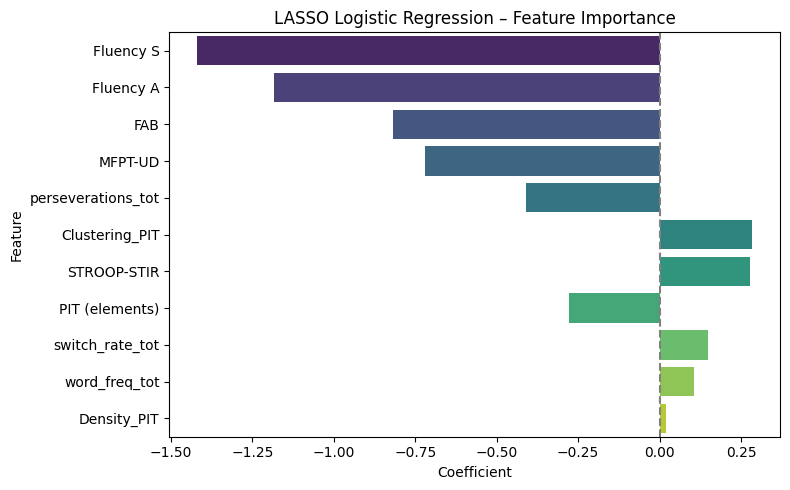

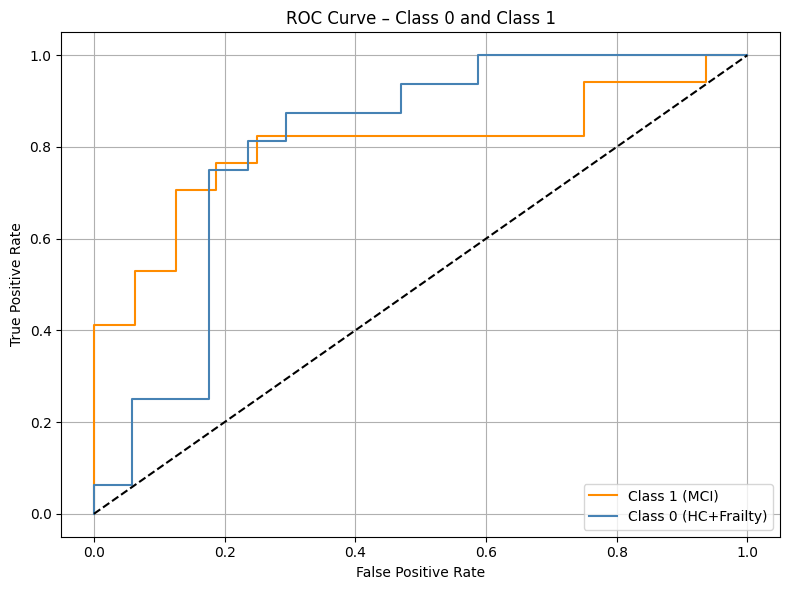

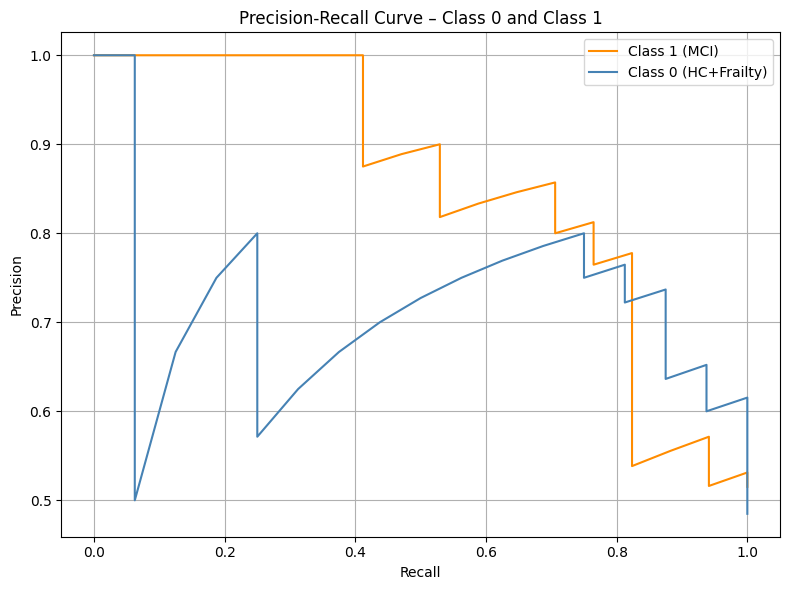

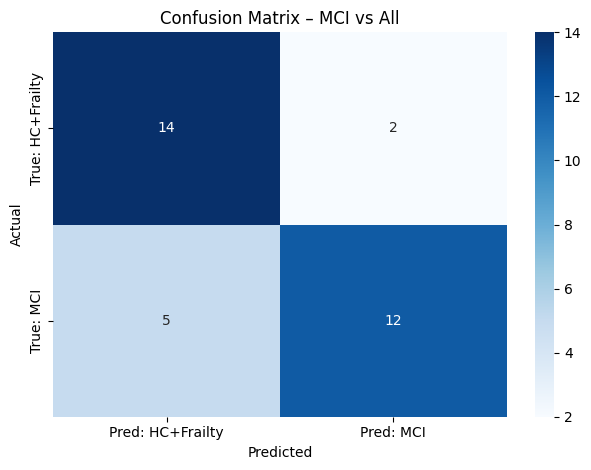

Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.785 ± 0.073 | 95% CI [0.636, 0.909]
PRECISION: 0.851 ± 0.098 | 95% CI [0.636, 1.000]
RECALL: 0.706 ± 0.114 | 95% CI [0.470, 0.917]
SPECIFICITY: 0.868 ± 0.089 | 95% CI [0.684, 1.000]
F1: 0.766 ± 0.089 | 95% CI [0.571, 0.919]
ROC_AUC: 0.799 ± 0.083 | 95% CI [0.630, 0.948]
PR_AUC: 0.849 ± 0.075 | 95% CI [0.676, 0.963]


In [52]:
df = pd.read_csv("df_merged (semantic+nps).csv")

selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

X = df[selected_features]
y = df['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, selected_features)
])


lasso_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

lasso_pipeline.fit(X_train_ros, y_train_ros)


y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

print("Test Set Metrics – MCI vs (HC + Frailty)")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Cross validation
cv_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('ros', RandomOverSampler(random_state=42)),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

cv_results = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Stratified Cross-Validation (5 folds):")
for metric in scoring:
    mean = cv_results[f'test_{metric}'].mean()
    std = cv_results[f'test_{metric}'].std()
    print(f"{metric.upper()}: {mean:.3f} ± {std:.3f}")

# Feature importance (coefficients)
model = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("Non-zero Coefficients (LASSO):")
print(coef_df[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 (MCI)', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All")
plt.tight_layout()
plt.show()

# Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


### SHAP: MCI vs All

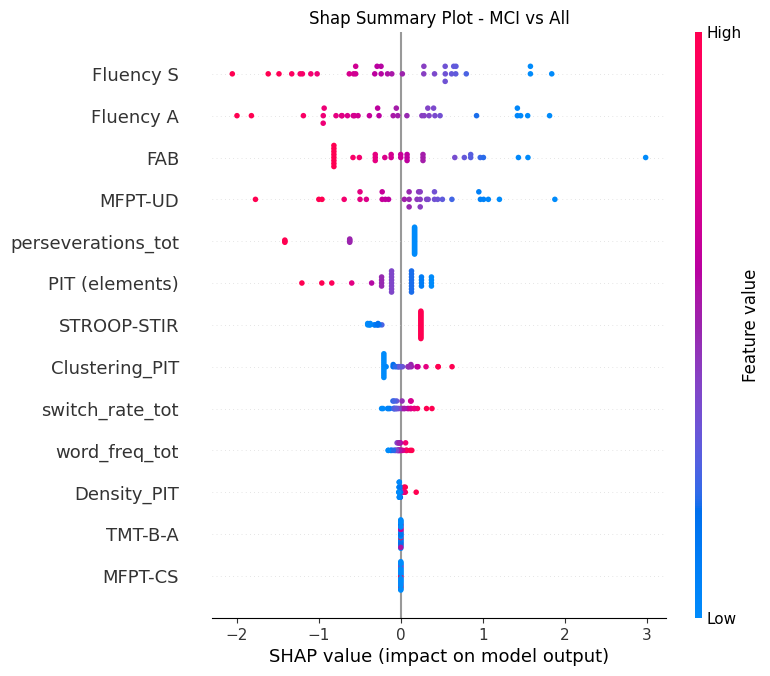

In [53]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

X = df[selected_features]
y = df['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_ros)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_scaled, y_train_ros)

# SHAP: EXPLAINER + SUMMARY PLOT 
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, max_display=13,title = "Shap Summary Plot - MCI vs All", show=False)
plt.title("Shap Summary Plot - MCI vs All")
plt.show()

## +Frailty vs HC

Cross-Validation Results (5-fold):
Accuracy: 0.655 ± 0.039
F1-score: 0.380 ± 0.221
ROC-AUC:  0.602 ± 0.039
PR-AUC:   0.552 ± 0.112
Training set metrics
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       0.81      0.93      0.87        14

    accuracy                           0.89        36
   macro avg       0.88      0.90      0.89        36
weighted avg       0.90      0.89      0.89        36

Accuracy: 0.889
Precision: 0.812
Recall (Sensitivity): 0.929
Specificity: 0.864
F1-score: 0.867
ROC-AUC: 0.906
PR-AUC: 0.770
HC vs Frailty – Full model
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.50      0.50      0.50         6

    accuracy                           0.62        16
   macro avg       0.60      0.60      0.60        16
weighted avg       0.62      0.62      0.62        16

Accuracy: 0.625
Precision: 0.500
Recall (S

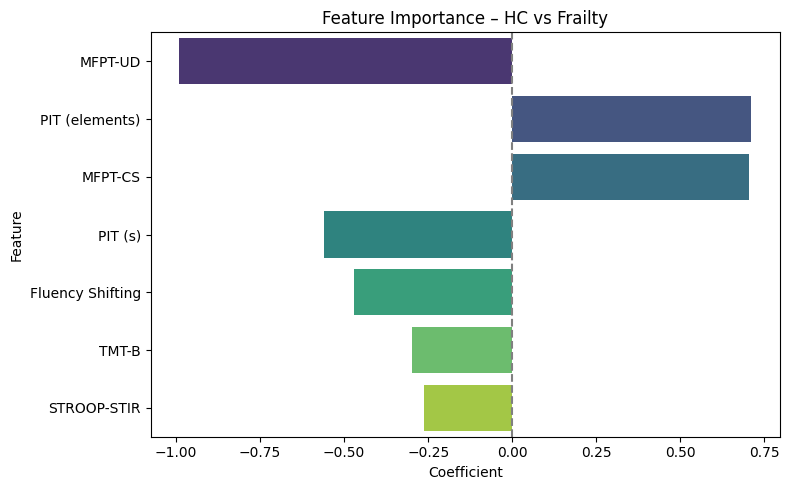

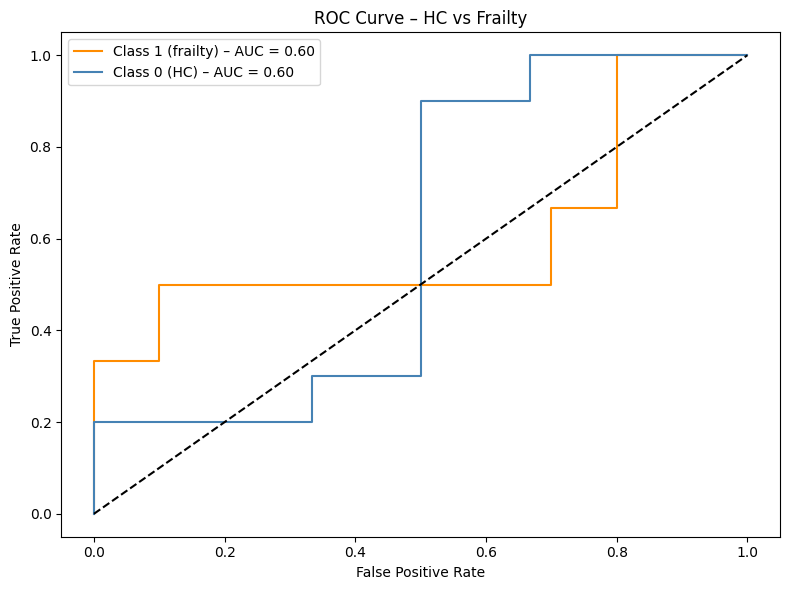

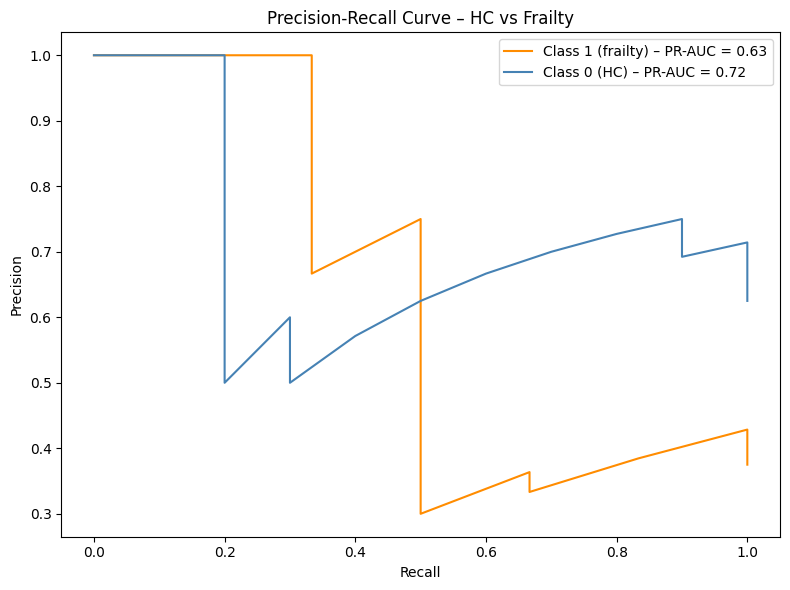

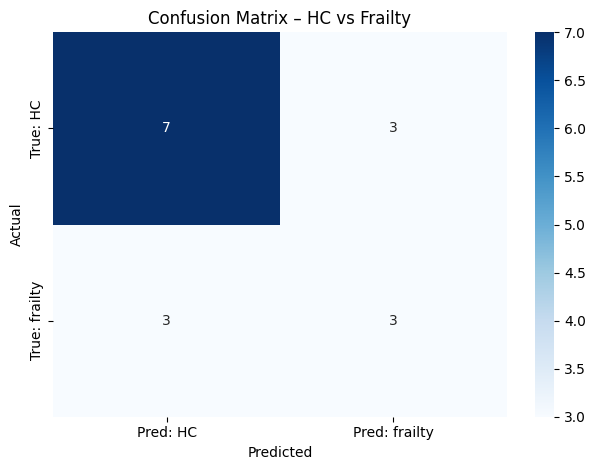


Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.627 ± 0.124 | 95% CI [0.375, 0.875]
PRECISION: 0.506 ± 0.225 | 95% CI [0.000, 1.000]
RECALL: 0.496 ± 0.225 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.706 ± 0.151 | 95% CI [0.400, 1.000]
F1: 0.477 ± 0.188 | 95% CI [0.000, 0.824]
ROC_AUC: 0.599 ± 0.183 | 95% CI [0.222, 0.979]
PR_AUC: 0.629 ± 0.195 | 95% CI [0.161, 0.947]


In [54]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Filter only HC and Frailty subjects
df_hc_frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

X = df_hc_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR'] + pit_features]

# Target: 1 = Frailty, 0 = HC
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

#LASSO Logistic Regression
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

# Predictions on training set
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

# Metrics on training set
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, zero_division=0)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)


print("Training set metrics")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

# Metrics
print("HC vs Frailty – Full model")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall (Sensitivity): {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
print(f"PR-AUC: {auc(recall_vals, precision_vals):.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs', ascending=False)

print("\nSelected coefficients:")
print(coef_df[['Feature', 'Coefficient']])


plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – HC vs Frailty")
plt.tight_layout()
plt.show()

# ROC and PR curves for class 0 and 1
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


# PR curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (frailty) – PR-AUC = {auc(recall1, precision1):.2f}", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (HC) – PR-AUC = {auc(recall0, precision0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: frailty"],
            yticklabels=["True: HC", "True: frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

#Bootstrapping (1000 iterations) 
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    # Skip if only one class present
    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## Frailty vs HC  (with Random Oversampling)

Cross-Validation Results (5-fold):
Accuracy: 0.675 ± 0.091
F1-score: 0.501 ± 0.253
ROC-AUC:  0.671 ± 0.035
PR-AUC:   0.602 ± 0.080
Training set metrics
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       0.88      0.95      0.91        22

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44

Accuracy: 0.909
Precision: 0.875
Recall (Sensitivity): 0.955
Specificity: 0.864
F1-score: 0.913
ROC-AUC: 0.905
PR-AUC: 0.847
Test set metrics
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.43      0.50      0.46         6

    accuracy                           0.56        16
   macro avg       0.55      0.55      0.55        16
weighted avg       0.58      0.56      0.57        16

Accuracy: 0.562
Precision: 0.429
Recall (Sensitivity

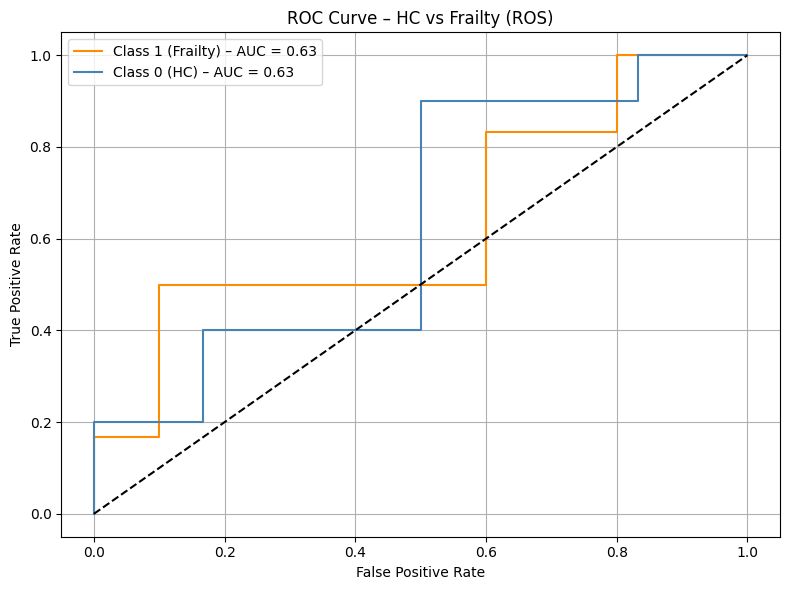

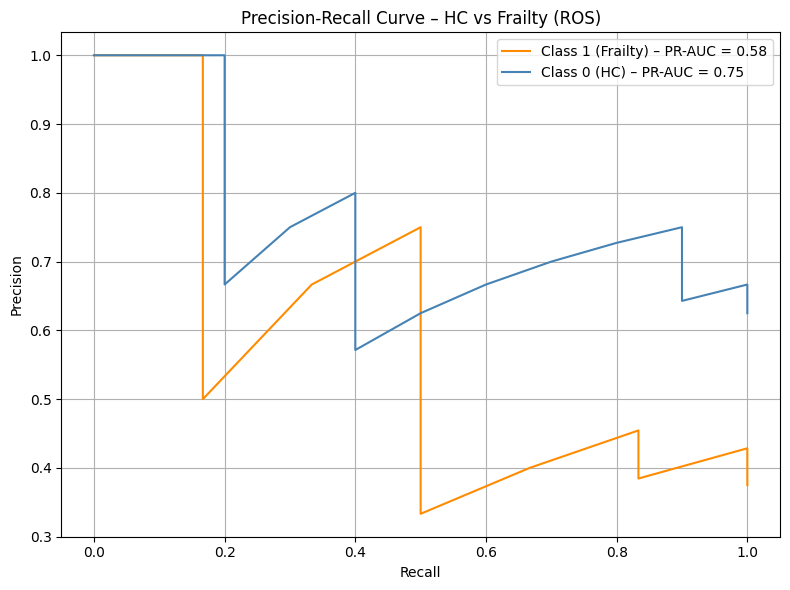

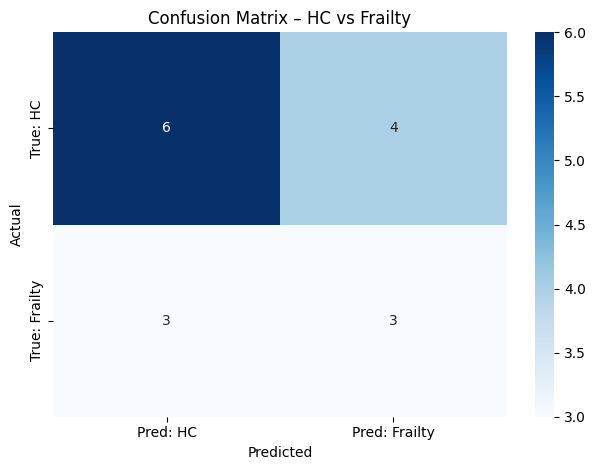

Selected non-zero coefficients
             Feature  Coefficient
3            MFPT-UD    -1.309121
4            MFPT-CS     0.758960
11    PIT (elements)     0.735935
0              TMT-B    -0.612816
9            PIT (s)    -0.552326
7   Fluency Shifting    -0.277081
8        STROOP-STIR    -0.209301


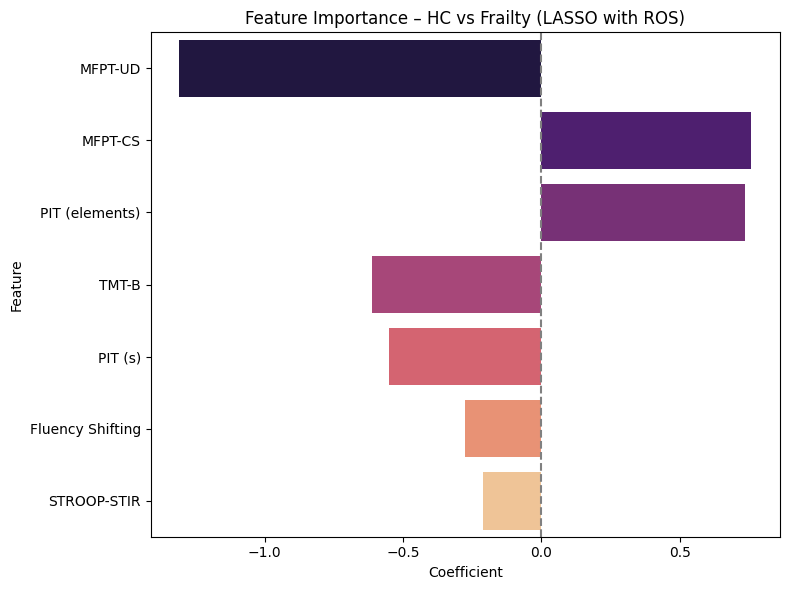

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.566 ± 0.122 | 95% CI [0.312, 0.812]
PRECISION: 0.433 ± 0.199 | 95% CI [0.000, 0.833]
RECALL: 0.496 ± 0.225 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.609 ± 0.157 | 95% CI [0.300, 0.900]
F1: 0.441 ± 0.177 | 95% CI [0.000, 0.750]
ROC_AUC: 0.637 ± 0.163 | 95% CI [0.312, 0.938]
PR_AUC: 0.590 ± 0.203 | 95% CI [0.162, 0.901]


In [55]:
df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Feature set
X = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target: 1 = Frailty, 0 = HC
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('ros', RandomOverSampler(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Random Oversampling on training set
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train_ros, y_train_ros)

# Predictions on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# Metrics on test set
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

# Predictions on training set
y_pred_train = model.predict(X_train_ros)
y_proba_train = model.predict_proba(X_train_ros)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train_ros, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)

# Metrics on training set
acc_train = accuracy_score(y_train_ros, y_pred_train)
prec_train = precision_score(y_train_ros, y_pred_train, zero_division=0)
rec_train = recall_score(y_train_ros, y_pred_train)
f1_train = f1_score(y_train_ros, y_pred_train)
roc_auc_train = roc_auc_score(y_train_ros, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train_ros, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

# Print metrics
print("Training set metrics")
print(classification_report(y_train_ros, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Metrics dictionary for test set
metrics_dict = {
    "Model": "HC vs Frailty – LASSO (ROS)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec1, prec1, label=f"Class 1 (Frailty) – PR-AUC = {auc(rec1, prec1):.2f}", color='darkorange')
plt.plot(rec0, prec0, label=f"Class 0 (HC) – PR-AUC = {auc(rec0, prec0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: Frailty"],
            yticklabels=["True: HC", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – HC vs Frailty (LASSO with ROS)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## Frailty vs HC (with SMOTE)

Cross-Validation Results (5-fold):
Accuracy: 0.675 ± 0.091
F1-score: 0.489 ± 0.264
ROC-AUC:  0.626 ± 0.092
PR-AUC:   0.598 ± 0.106
Training set metrics
              precision    recall  f1-score   support

           0       0.90      0.86      0.88        22
           1       0.87      0.91      0.89        22

    accuracy                           0.89        44
   macro avg       0.89      0.89      0.89        44
weighted avg       0.89      0.89      0.89        44

Accuracy: 0.886
Precision: 0.870
Recall (Sensitivity): 0.909
Specificity: 0.864
F1-score: 0.889
ROC-AUC: 0.917
PR-AUC: 0.834
Test set metrics
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.50      0.50      0.50         6

    accuracy                           0.62        16
   macro avg       0.60      0.60      0.60        16
weighted avg       0.62      0.62      0.62        16

Accuracy: 0.625
Precision: 0.500
Recall (Sensitivity

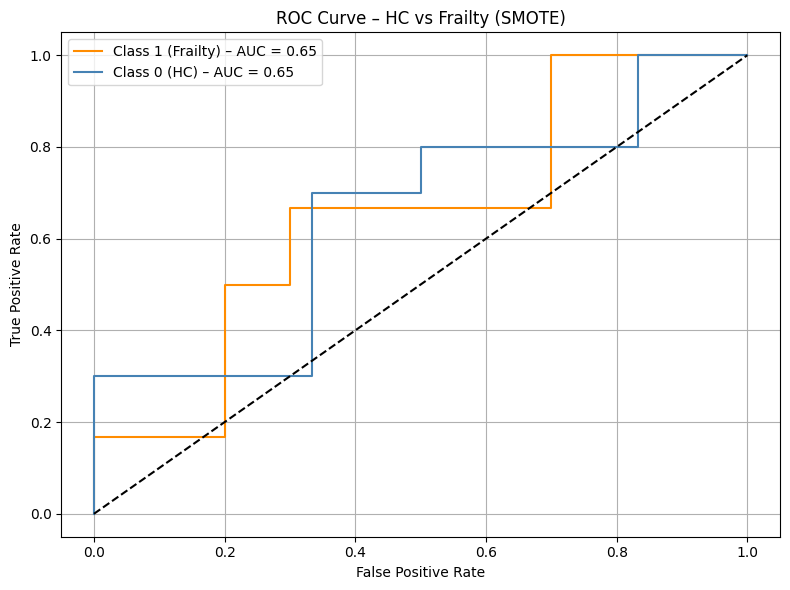

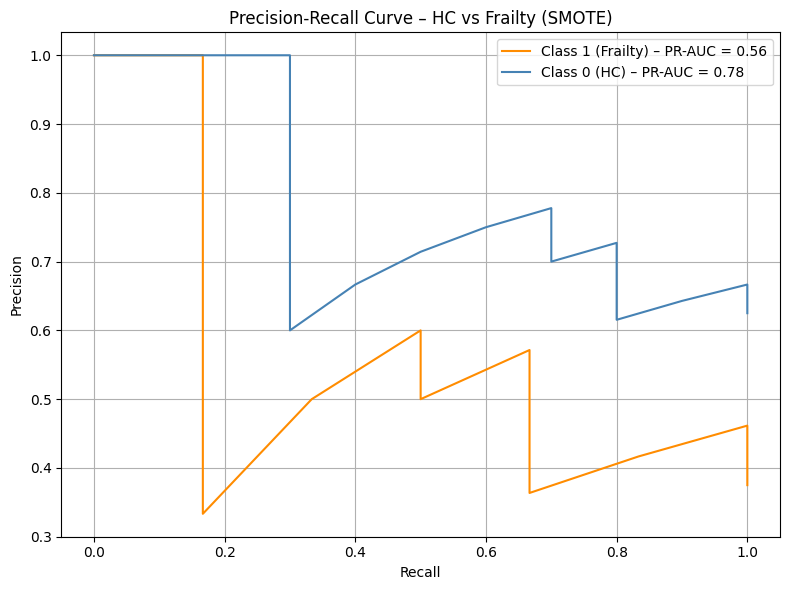

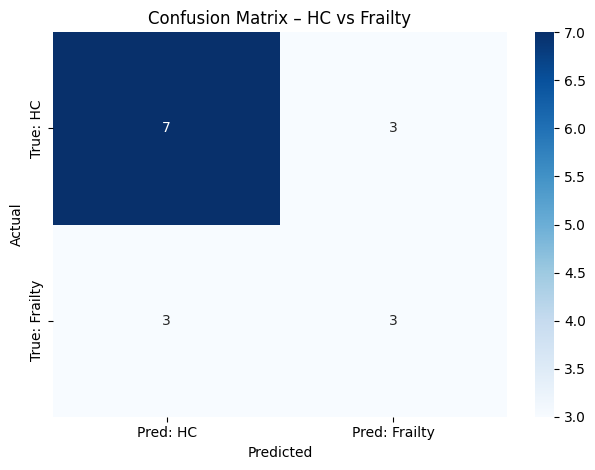

Selected non-zero coefficients
             Feature  Coefficient
3            MFPT-UD    -1.191574
4            MFPT-CS     0.702823
8        STROOP-STIR    -0.578865
9            PIT (s)    -0.523132
7   Fluency Shifting    -0.446045
0              TMT-B    -0.438834
11    PIT (elements)     0.435993
5          Fluency S     0.064547


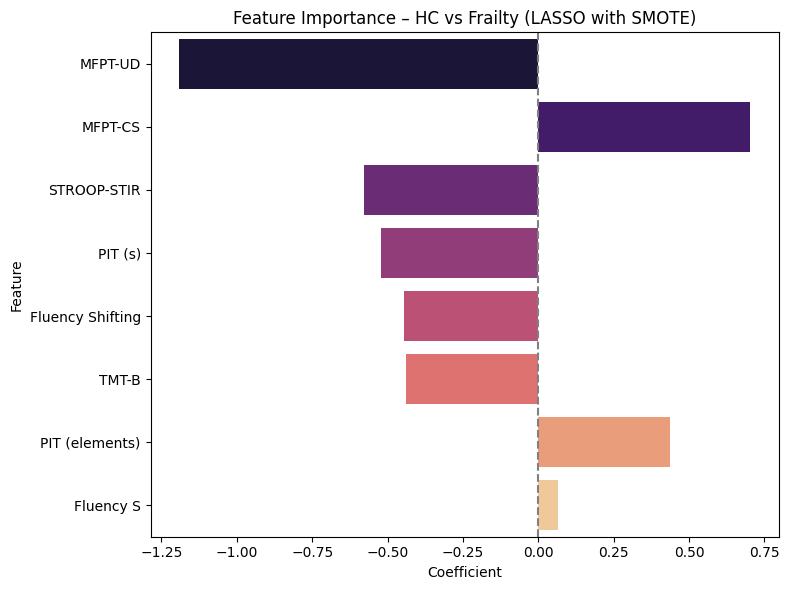

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.623 ± 0.123 | 95% CI [0.375, 0.875]
PRECISION: 0.497 ± 0.218 | 95% CI [0.000, 0.875]
RECALL: 0.496 ± 0.225 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.700 ± 0.146 | 95% CI [0.400, 0.925]
F1: 0.474 ± 0.189 | 95% CI [0.000, 0.800]
ROC_AUC: 0.653 ± 0.157 | 95% CI [0.333, 0.927]
PR_AUC: 0.564 ± 0.201 | 95% CI [0.161, 0.916]


In [56]:
df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Feature set
X = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Binary target: 1 = Frailty, 0 = HC
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Apply SMOTE on training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train_smote, y_train_smote)

# Predictions on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# Metrics on test set
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

# Predictions on training set
y_pred_train = model.predict(X_train_smote)
y_proba_train = model.predict_proba(X_train_smote)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train_smote, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)

# Metrics on training set
acc_train = accuracy_score(y_train_smote, y_pred_train)
prec_train = precision_score(y_train_smote, y_pred_train, zero_division=0)
rec_train = recall_score(y_train_smote, y_pred_train)
f1_train = f1_score(y_train_smote, y_pred_train)
roc_auc_train = roc_auc_score(y_train_smote, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train_smote, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)


print("Training set metrics")
print(classification_report(y_train_smote, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")


print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Metrics dictionary (test)
metrics_dict = {
    "Model": "HC vs Frailty – LASSO (SMOTE)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec1, prec1, label=f"Class 1 (Frailty) – PR-AUC = {auc(rec1, prec1):.2f}", color='darkorange')
plt.plot(rec0, prec0, label=f"Class 0 (HC) – PR-AUC = {auc(rec0, prec0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: Frailty"],
            yticklabels=["True: HC", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – HC vs Frailty (LASSO with SMOTE)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


The best performing model for HC vs Frailty classification is the one without resampling typology. The unbalanced model has the highest precision, F1 and PR_AUC, at equal recall, proving more effective in distinguishing HC from frailty.

### Performance full model vs no PIT model for Frailty vs HC

Metric Comparison – HC vs Frailty (No Resampling)
             Accuracy  Precision  Recall (Sensitivity)  Specificity   F1  \
With PIT        0.625        0.5                   0.5          0.7  0.5   
Without PIT     0.625        0.5                   0.5          0.7  0.5   

             ROC-AUC  PR-AUC  
With PIT       0.600   0.634  
Without PIT    0.567   0.519  


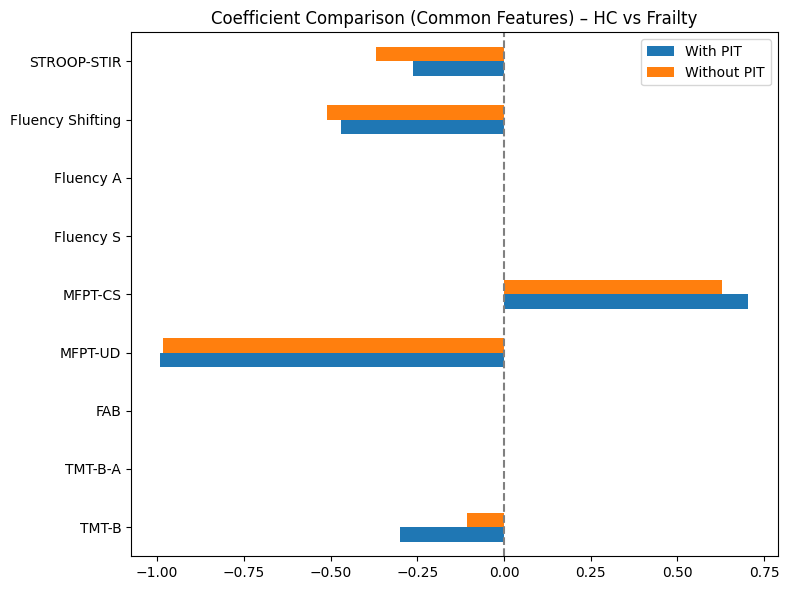

In [57]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

X_full = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                        'Fluency S', 'Fluency A', 'Fluency Shifting',
                        'STROOP-STIR'] + pit_features]

# Feature set without PIT
X_nopit = X_full.drop(columns=pit_features)

# Target: 1 = Frailty, 0 = HC
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Same split for both models
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.3, random_state=42)
X_train_np, X_test_np = X_nopit.loc[X_train_f.index], X_nopit.loc[X_test_f.index]

# Train models
model_full = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_nopit = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_full.fit(X_train_f, y_train)
model_nopit.fit(X_train_np, y_train)

# Predictions
y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]

y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

# Metric function
def get_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Sensitivity)': sensitivity,
        'Specificity': specificity,
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': auc(recall_vals, precision_vals)
    }

# Compare results
results = pd.DataFrame({
    'With PIT': get_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': get_metrics(y_test, y_pred_np, y_proba_np)
}).T.round(3)

print("Metric Comparison – HC vs Frailty (No Resampling)")
print(results)

# Extract coefficients
coef_f = pd.Series(model_full.coef_[0], index=X_full.columns)
coef_np = pd.Series(model_nopit.coef_[0], index=X_nopit.columns)

# Common features only
common_features = [col for col in coef_np.index if col in coef_f.index]
df_coef_compare = pd.DataFrame({
    'With PIT': coef_f[common_features],
    'Without PIT': coef_np[common_features]
})

# Plot
df_coef_compare.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title("Coefficient Comparison (Common Features) – HC vs Frailty")
plt.tight_layout()
plt.show()


### Permutation importance for model: Frailty vs HC

In [58]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Filter only HC and Frailty
df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Full feature set (with PIT)
X = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR'] + pit_features]

# Target
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Train LASSO Logistic Regression
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

# Safe ROC-AUC scorer
def safe_roc_auc(y_true, y_scores):
    if len(np.unique(y_true)) < 2:
        return 0
    return roc_auc_score(y_true, y_scores)

roc_auc_scorer = make_scorer(safe_roc_auc, needs_proba=True)

# Permutation importance
perm_result = permutation_importance(
    estimator=model_full,
    X=X_test,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring=roc_auc_scorer
)


perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
})

# Filter and sort
threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered = perm_df_filtered.sort_values(by='Importance', ascending=False)

print("\nPermutation Importance (based on ROC-AUC, HC vs Frailty):")
print(perm_df_filtered)


error_bar_factor = 0.05
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * error_bar_factor

fig = px.bar(
    perm_df_filtered,
    x='Importance',
    y='Feature',
    title="Permutation Importance – HC vs Frailty",
    labels={'Importance': 'Mean decrease in ROC-AUC when feature is permuted', 'Feature': 'Feature'},
    error_x='Reduced_Std',
    color='Importance',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    showlegend=False,
    xaxis_title="Mean decrease in ROC-AUC when feature is permuted",
    yaxis_title="Feature",
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True, autorange="reversed"),
    plot_bgcolor="white"
)

fig.show()


Permutation Importance (based on ROC-AUC, HC vs Frailty):
             Feature  Importance       Std
9            PIT (s)    0.045556  0.072128
0              TMT-B    0.022778  0.029339
8        STROOP-STIR    0.021667  0.045164
3            MFPT-UD    0.008889  0.124628
11    PIT (elements)   -0.014444  0.087107
4            MFPT-CS   -0.028333  0.059807
7   Fluency Shifting   -0.060556  0.075827


### +Frailty vs HC (with semantic metrics)

Test Set Metrics – HC vs Frailty
              precision    recall  f1-score   support

           0       0.67      0.40      0.50        10
           1       0.40      0.67      0.50         6

    accuracy                           0.50        16
   macro avg       0.53      0.53      0.50        16
weighted avg       0.57      0.50      0.50        16

Accuracy: 0.500
Precision: 0.400
Recall (Sensitivity): 0.667
Specificity: 0.400
F1-score: 0.500
ROC-AUC: 0.650
PR-AUC: 0.631
Stratified Cross-Validation (5 folds):
ACCURACY: 0.596 ± 0.113
PRECISION: 0.468 ± 0.114
RECALL: 0.600 ± 0.255
F1: 0.516 ± 0.164
ROC_AUC: 0.669 ± 0.116
AVERAGE_PRECISION: 0.584 ± 0.115
Non-zero Coefficients (LASSO):
             Feature  Coefficient
4            MFPT-CS     1.342582
3            MFPT-UD    -1.158073
11    PIT (elements)     0.570556
9            PIT (s)    -0.492395
7   Fluency Shifting    -0.446625
18           aoa_tot    -0.352633
21    Clustering_PIT    -0.324421
16    intrusions_tot    -0.2

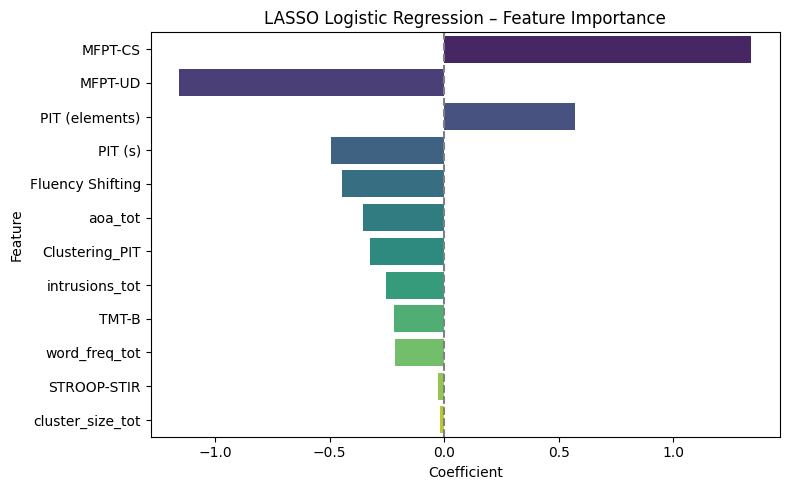

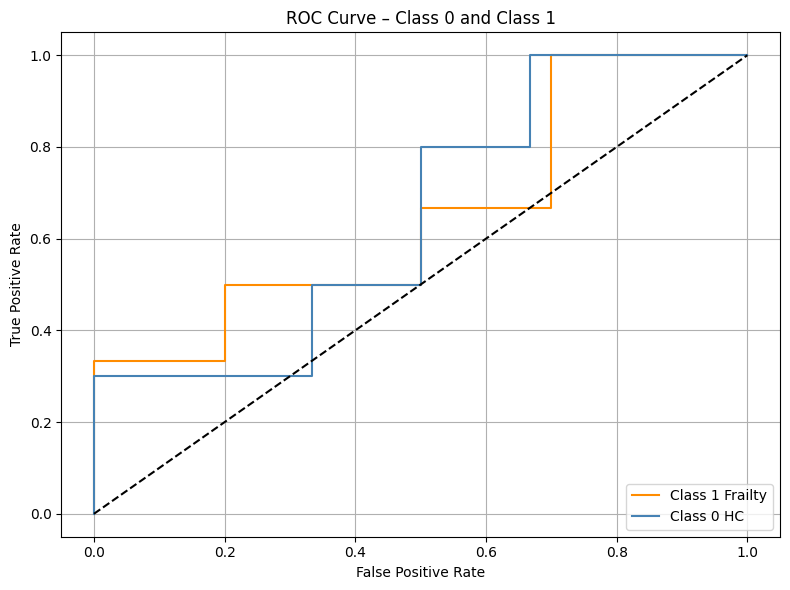

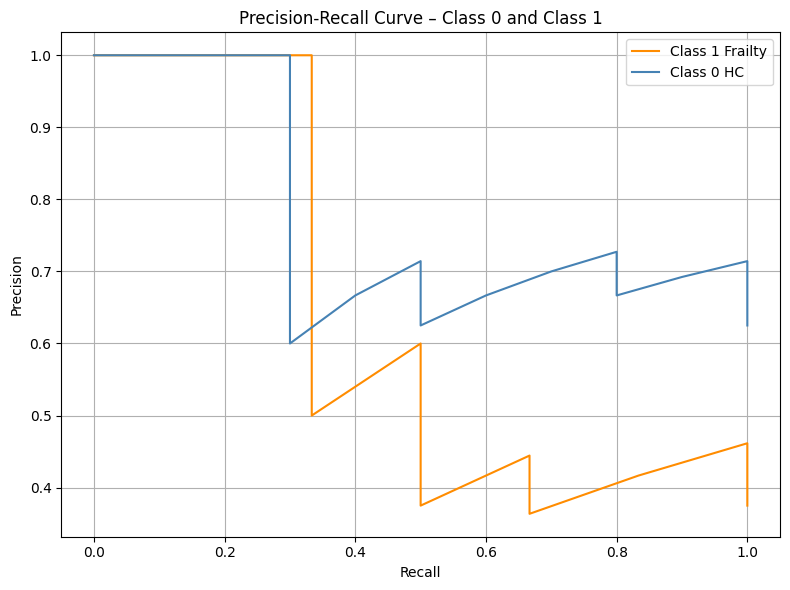

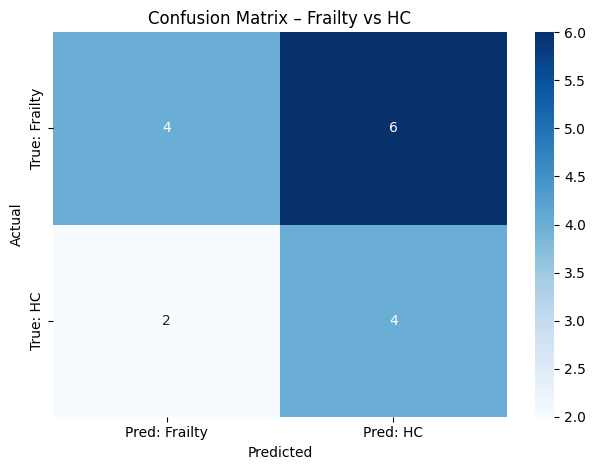

Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.506 ± 0.121 | 95% CI [0.250, 0.750]
PRECISION: 0.405 ± 0.160 | 95% CI [0.111, 0.715]
RECALL: 0.666 ± 0.206 | 95% CI [0.250, 1.000]
SPECIFICITY: 0.412 ± 0.161 | 95% CI [0.100, 0.750]
F1: 0.486 ± 0.155 | 95% CI [0.167, 0.737]
ROC_AUC: 0.654 ± 0.159 | 95% CI [0.317, 0.958]
PR_AUC: 0.628 ± 0.194 | 95% CI [0.167, 0.938]


In [59]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]


df_hc_frailty = df[df['group'].isin(['HC', 'Frailty'])].copy()
X = df_hc_frailty[selected_features]
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, selected_features)
])


lasso_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

lasso_pipeline.fit(X_train_ros, y_train_ros)


y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

print("Test Set Metrics – HC vs Frailty")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Cross validation
cv_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ( 'ros', RandomOverSampler(random_state=42)),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

cv_results = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Stratified Cross-Validation (5 folds):")
for metric in scoring:
    mean = cv_results[f'test_{metric}'].mean()
    std = cv_results[f'test_{metric}'].std()
    print(f"{metric.upper()}: {mean:.3f} ± {std:.3f}")

# Feature importance (coefficients)
model = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("Non-zero Coefficients (LASSO):")
print(coef_df[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 Frailty', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 HC', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 Frailty', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 HC', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: Frailty", "Pred: HC"],
            yticklabels=["True: Frailty", "True: HC"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Frailty vs HC")
plt.tight_layout()
plt.show()

# Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


### SHAP: HC vs Frailty

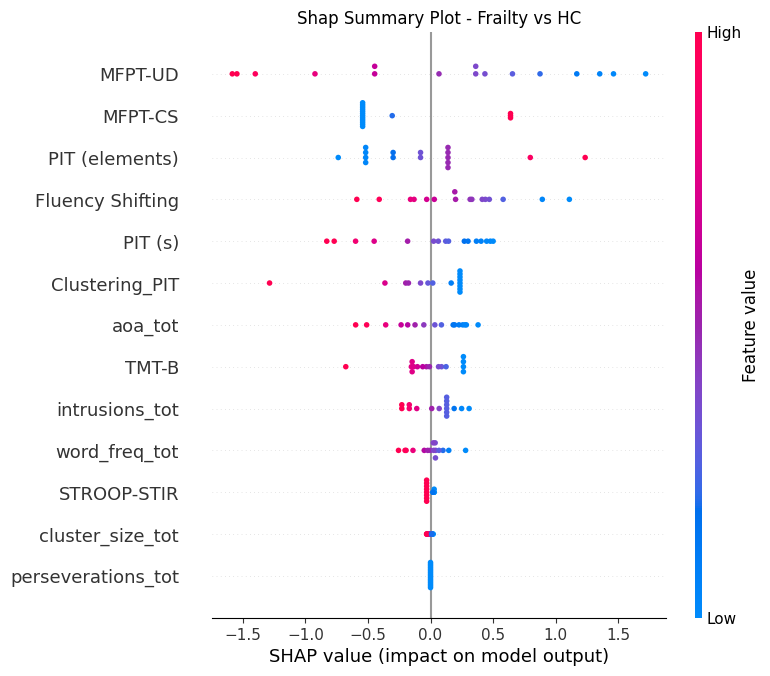

In [60]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

df_hc_frailty = df[df['group'].isin(['HC', 'Frailty'])].copy()
X = df_hc_frailty[selected_features]
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_ros)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_scaled, y_train_ros)

# SHAP: EXPLAINER + SUMMARY PLOT 
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, max_display=13,title = "Shap Summary Plot - Frailty vs HC", show=False)
plt.title("Shap Summary Plot - Frailty vs HC")
plt.show()

## Frailty vs MCI

Cross-Validation Results (5-fold):
Accuracy: 0.821 ± 0.082
F1-score: 0.556 ± 0.200
ROC-AUC:  0.884 ± 0.089
PR-AUC:   0.768 ± 0.175
Training set metrics
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        40
           1       0.67      1.00      0.80        14

    accuracy                           0.87        54
   macro avg       0.83      0.91      0.85        54
weighted avg       0.91      0.87      0.88        54

Accuracy: 0.870
Precision: 0.667
Recall: 1.000
Specificity: 0.825
F1-score: 0.800
ROC-AUC: 0.964
PR-AUC: 0.899
Test set metrics
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        18
           1       0.75      0.50      0.60         6

    accuracy                           0.83        24
   macro avg       0.80      0.72      0.75        24
weighted avg       0.82      0.83      0.82        24

Accuracy: 0.833
Precision: 0.750
Recall: 0.500
Specificity: 0.944


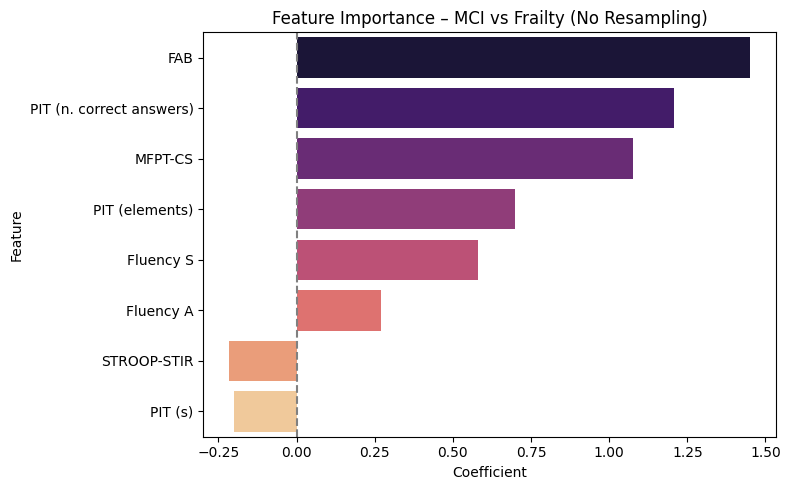

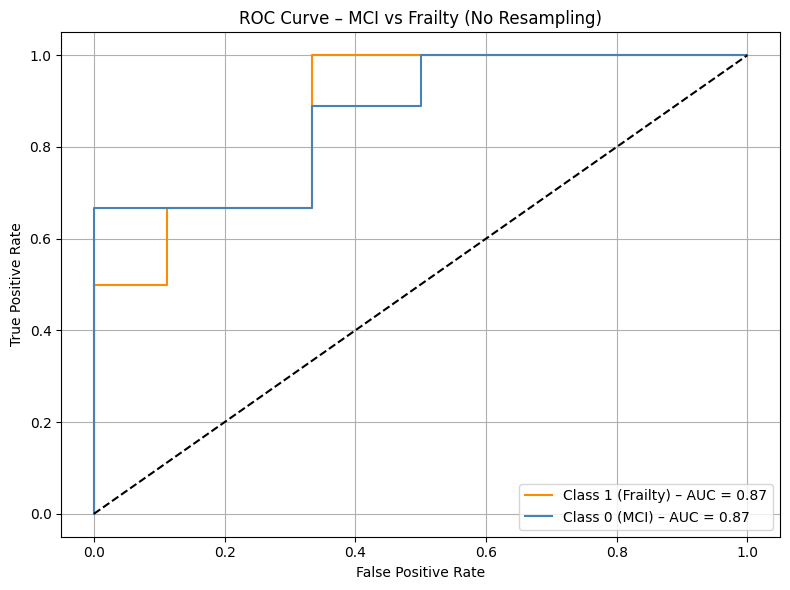

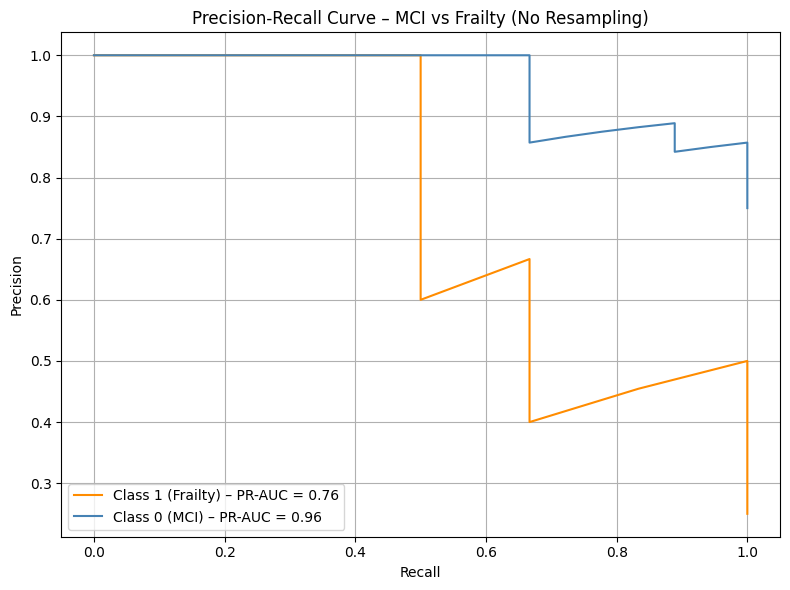

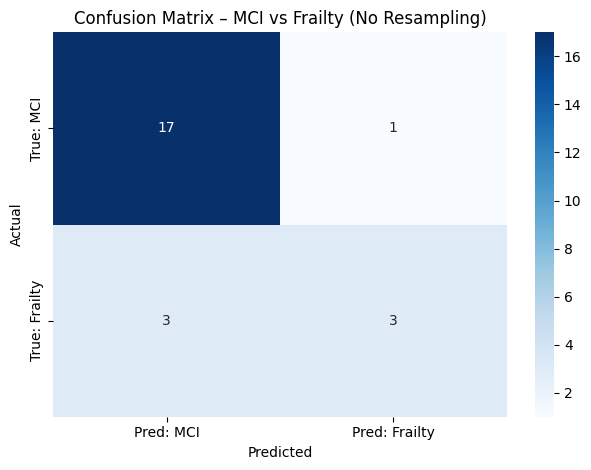

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.826 ± 0.079 | 95% CI [0.667, 0.958]
PRECISION: 0.738 ± 0.248 | 95% CI [0.000, 1.000]
RECALL: 0.502 ± 0.213 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.939 ± 0.057 | 95% CI [0.812, 1.000]
F1: 0.574 ± 0.199 | 95% CI [0.000, 0.889]
ROC_AUC: 0.870 ± 0.084 | 95% CI [0.682, 1.000]
PR_AUC: 0.757 ± 0.164 | 95% CI [0.384, 1.000]


In [61]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Model
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

# Predictions test
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Predictions train
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Metrics train
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

# Metrics test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef_df[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (No Resampling)")
plt.tight_layout()
plt.show()

# ROC and PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (No Resampling)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty) – PR-AUC = {auc(recall1, precision1):.2f}", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI) – PR-AUC = {auc(recall0, precision0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (No Resampling)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (No Resampling)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## +Frailty vs MCI (with Random Undersampling)

Cross-Validation Results (5-fold):
Accuracy: 0.794 ± 0.109
F1-score: 0.695 ± 0.164
ROC-AUC:  0.846 ± 0.106
PR-AUC:   0.700 ± 0.225
Training set metrics – MCI vs Frailty (Undersampling)
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.81      0.93      0.87        14

    accuracy                           0.86        28
   macro avg       0.86      0.86      0.86        28
weighted avg       0.86      0.86      0.86        28

Accuracy: 0.857
Precision: 0.812
Recall: 0.929
Specificity: 0.786
F1-score: 0.867
ROC-AUC: 0.944
PR-AUC: 0.933
Test set metrics
              precision    recall  f1-score   support

           0       0.93      0.72      0.81        18
           1       0.50      0.83      0.62         6

    accuracy                           0.75        24
   macro avg       0.71      0.78      0.72        24
weighted avg       0.82      0.75      0.77        24

Accuracy: 0.750
Precision: 0.500


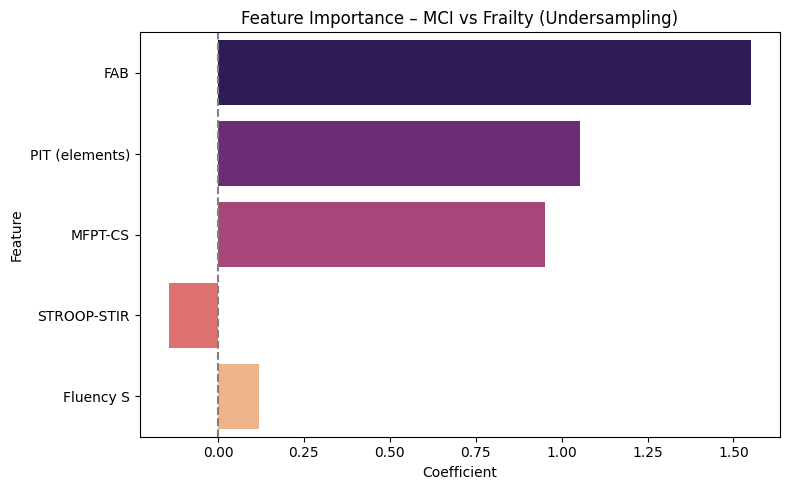

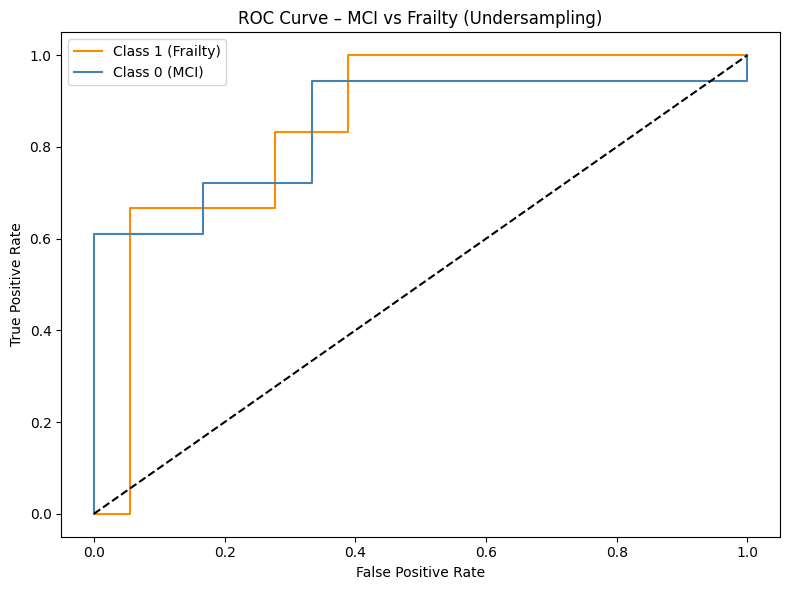

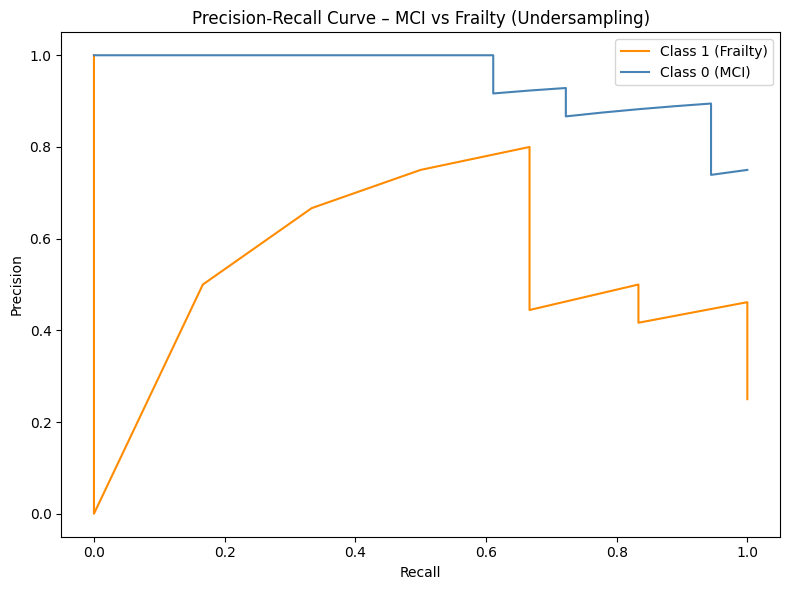

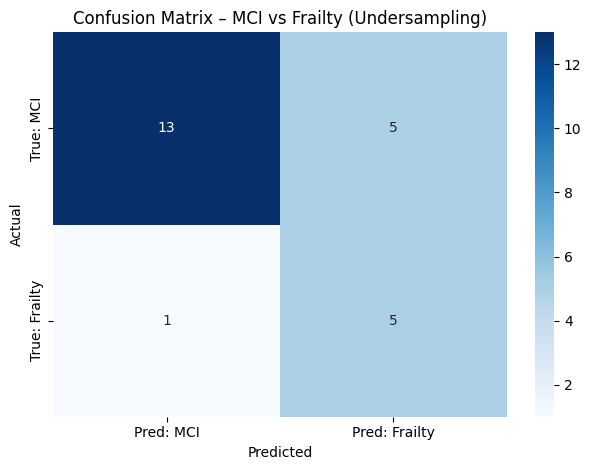

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.750 ± 0.085 | 95% CI [0.583, 0.917]
PRECISION: 0.511 ± 0.163 | 95% CI [0.182, 0.801]
RECALL: 0.830 ± 0.163 | 95% CI [0.500, 1.000]
SPECIFICITY: 0.722 ± 0.104 | 95% CI [0.526, 0.933]
F1: 0.617 ± 0.150 | 95% CI [0.266, 0.857]
ROC_AUC: 0.851 ± 0.086 | 95% CI [0.650, 1.000]
PR_AUC: 0.594 ± 0.224 | 95% CI [0.189, 1.000]


In [62]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('ros', RandomUnderSampler(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_rus, y_train_rus)

#Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Training
y_pred_train = model.predict(X_train_rus)
y_proba_train = model.predict_proba(X_train_rus)[:, 1]

# Metriche training
cm_train = confusion_matrix(y_train_rus, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train_rus, y_pred_train)
prec_train = precision_score(y_train_rus, y_pred_train)
f1_train = f1_score(y_train_rus, y_pred_train)
roc_auc_train = roc_auc_score(y_train_rus, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train_rus, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics – MCI vs Frailty (Undersampling)")
print(classification_report(y_train_rus, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

# Test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (Undersampling)")
plt.tight_layout()
plt.show()

# ROC & PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI)", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (Undersampling)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI)", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (Undersampling)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (Undersampling)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## Frailty vs MCI  (with SMOTE)

Cross-Validation Results (5-fold):
Accuracy: 0.808 ± 0.087
F1-score: 0.644 ± 0.153
ROC-AUC:  0.877 ± 0.105
PR-AUC:   0.746 ± 0.223
Training set metrics – MCI vs Frailty (SMOTE)
              precision    recall  f1-score   support

           0       0.97      0.85      0.91        40
           1       0.87      0.97      0.92        40

    accuracy                           0.91        80
   macro avg       0.92      0.91      0.91        80
weighted avg       0.92      0.91      0.91        80

Accuracy: 0.912
Precision: 0.867
Recall: 0.975
Specificity: 0.850
F1-score: 0.918
ROC-AUC: 0.972
PR-AUC: 0.967
Test set metrics
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        18
           1       0.67      0.33      0.44         6

    accuracy                           0.79        24
   macro avg       0.74      0.64      0.66        24
weighted avg       0.77      0.79      0.76        24

Accuracy: 0.792
Precision: 0.667
Recall: 

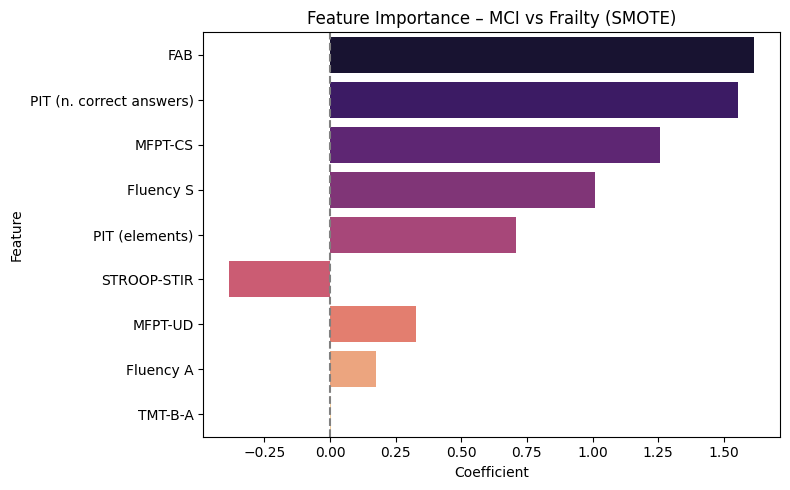

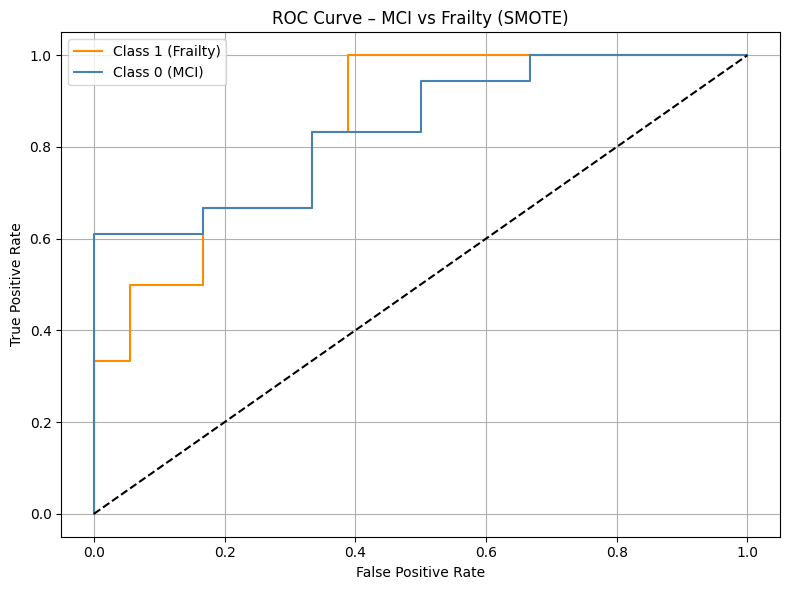

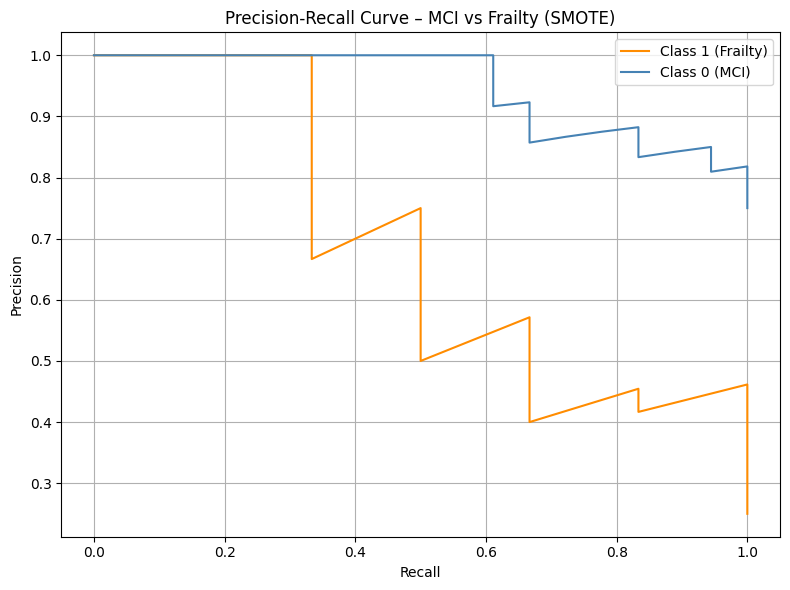

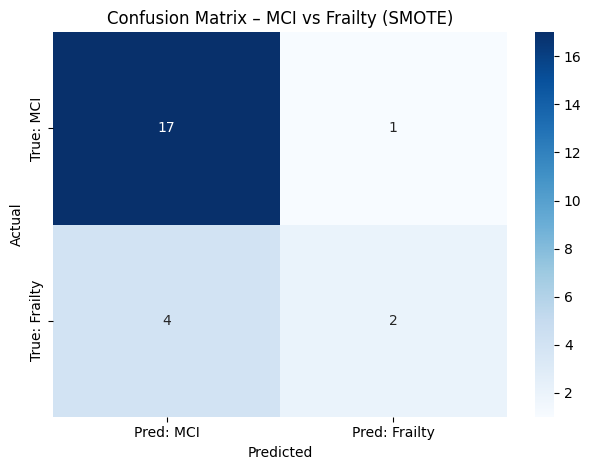

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.784 ± 0.085 | 95% CI [0.625, 0.917]
PRECISION: 0.636 ± 0.325 | 95% CI [0.000, 1.000]
RECALL: 0.337 ± 0.209 | 95% CI [0.000, 0.750]
SPECIFICITY: 0.939 ± 0.057 | 95% CI [0.812, 1.000]
F1: 0.418 ± 0.223 | 95% CI [0.000, 0.800]
ROC_AUC: 0.841 ± 0.090 | 95% CI [0.648, 0.983]
PR_AUC: 0.681 ± 0.187 | 95% CI [0.207, 0.955]


In [63]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_sm, y_train_sm)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Training
y_pred_train = model.predict(X_train_sm)
y_proba_train = model.predict_proba(X_train_sm)[:, 1]

cm_train = confusion_matrix(y_train_sm, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train_sm, y_pred_train)
prec_train = precision_score(y_train_sm, y_pred_train)
f1_train = f1_score(y_train_sm, y_pred_train)
roc_auc_train = roc_auc_score(y_train_sm, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train_sm, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics – MCI vs Frailty (SMOTE)")
print(classification_report(y_train_sm, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

# Test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Coefficienti
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (SMOTE)")
plt.tight_layout()
plt.show()

# ROC & PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI)", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI)", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (SMOTE)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


The best performing model for MCI vs Frailty classification is the one with random undersampling (because it maximizes recall).

### Performance full model vs no PIT model for Frailty vs MCI

Metric Comparison – MCI vs Frailty (Undersampling)
             Accuracy  Precision  Recall (Sensitivity)  Specificity  F1-score  \
With PIT        0.750      0.500                 0.833        0.722     0.625   
Without PIT     0.792      0.556                 0.833        0.778     0.667   

             ROC-AUC  PR-AUC  
With PIT       0.852   0.538  
Without PIT    0.880   0.658  


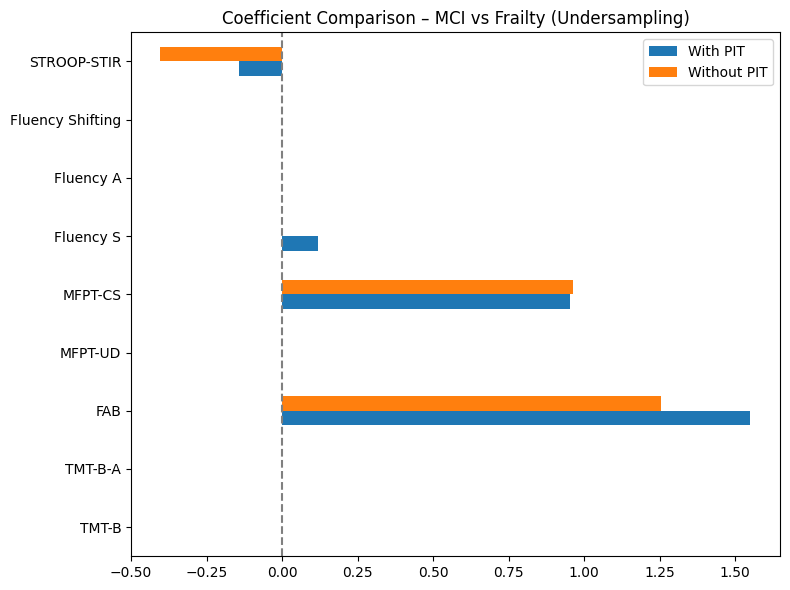

In [64]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Filter dataset for MCI vs Frailty
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Feature sets
X_full = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                         'Fluency S', 'Fluency A', 'Fluency Shifting',
                         'STROOP-STIR'] + pit_features]
X_nopit = X_full.drop(columns=pit_features)

# Binary target
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.3, random_state=42)
X_train_np, X_test_np = X_nopit.loc[X_train_f.index], X_nopit.loc[X_test_f.index]

# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_f_rus, y_train_rus = rus.fit_resample(X_train_f, y_train)
X_train_np_rus, _ = rus.fit_resample(X_train_np, y_train)

# Train models
model_full = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_nopit = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')

model_full.fit(X_train_f_rus, y_train_rus)
model_nopit.fit(X_train_np_rus, y_train_rus)

# Predictions
y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]

y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

# Metric function
def get_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Sensitivity)': recall,
        'Specificity': specificity,
        'F1-score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': auc(recall_vals, precision_vals)
    }

# Metric comparison
results = pd.DataFrame({
    'With PIT': get_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': get_metrics(y_test, y_pred_np, y_proba_np)
}).T.round(3)

print("Metric Comparison – MCI vs Frailty (Undersampling)")
print(results)

# Coefficienti
coef_f = pd.Series(model_full.coef_[0], index=X_full.columns)
coef_np = pd.Series(model_nopit.coef_[0], index=X_nopit.columns)

# Common coefficients
common_features = [col for col in coef_np.index if col in coef_f.index]
df_coef_compare = pd.DataFrame({
    'With PIT': coef_f[common_features],
    'Without PIT': coef_np[common_features]
})

# Plot
df_coef_compare.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title("Coefficient Comparison – MCI vs Frailty (Undersampling)")
plt.tight_layout()
plt.show()

### Permutation importance for model: Frailty vs MCI

In [65]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target: 1 = Frailty, 0 = MCI
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Train model
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_rus, y_train_rus)

# Safe scorer
def safe_roc_auc(y_true, y_scores):
    if len(np.unique(y_true)) < 2:
        return 0
    return roc_auc_score(y_true, y_scores)

scorer = make_scorer(safe_roc_auc, needs_proba=True)

# Permutation importance
perm_result = permutation_importance(
    estimator=model_full,
    X=X_test_f,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring=scorer
)


perm_df = pd.DataFrame({
    'Feature': X_test_f.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Filter & reduce std
threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * 0.05

print("\nPermutation Importance (based on ROC-AUC, MCI vs Frailty):")
print(perm_df_filtered)


fig = px.bar(
    perm_df_filtered,
    x='Importance',
    y='Feature',
    title="Permutation Importance – MCI vs Frailty (RUS)",
    error_x='Reduced_Std',
    color='Importance',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    showlegend=False,
    xaxis_title="Mean decrease in ROC-AUC when feature is permuted",
    yaxis_title="Feature",
    yaxis=dict(autorange="reversed"),
    plot_bgcolor="white"
)

fig.show()


Permutation Importance (based on ROC-AUC, MCI vs Frailty):
           Feature  Importance       Std  Reduced_Std
0              FAB    0.266975  0.133176     0.006659
1   PIT (elements)    0.010802  0.054048     0.002702
2          MFPT-CS    0.001543  0.023312     0.001166
10       Fluency S   -0.007407  0.012284     0.000614
11     STROOP-STIR   -0.008333  0.007691     0.000385


### + Frailty vs MCI (with semantic metrics)

Test Set Metrics – HC vs Frailty
              precision    recall  f1-score   support

           0       1.00      0.78      0.88        18
           1       0.60      1.00      0.75         6

    accuracy                           0.83        24
   macro avg       0.80      0.89      0.81        24
weighted avg       0.90      0.83      0.84        24

Accuracy: 0.833
Precision: 0.600
Recall (Sensitivity): 1.000
Specificity: 0.778
F1-score: 0.750
ROC-AUC: 0.926
PR-AUC: 0.813
Stratified Cross-Validation (5 folds):
ACCURACY: 0.674 ± 0.193
PRECISION: 0.507 ± 0.259
RECALL: 0.800 ± 0.100
F1: 0.601 ± 0.211
ROC_AUC: 0.806 ± 0.124
AVERAGE_PRECISION: 0.699 ± 0.197
Non-zero Coefficients (LASSO):
                 Feature  Coefficient
2                    FAB     1.488232
8            STROOP-STIR    -0.822079
22           Density_PIT    -0.620424
6              Fluency A     0.604243
15    perseverations_tot     0.425962
4                MFPT-CS     0.383419
13  cluster_switches_tot     0.154

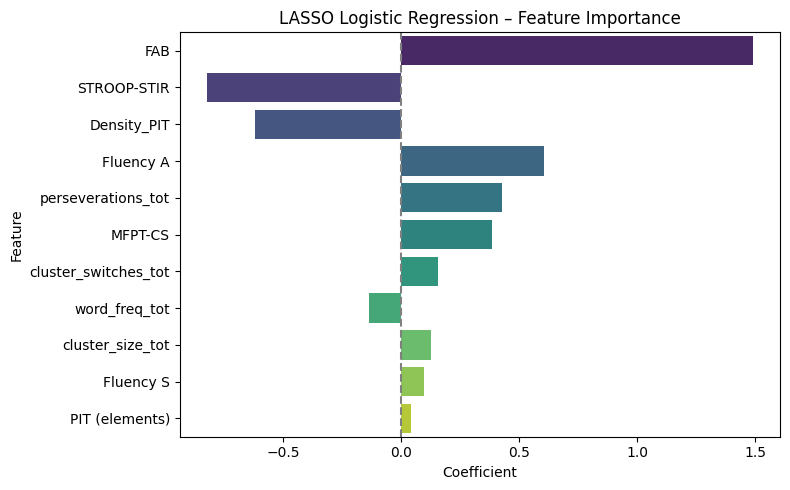

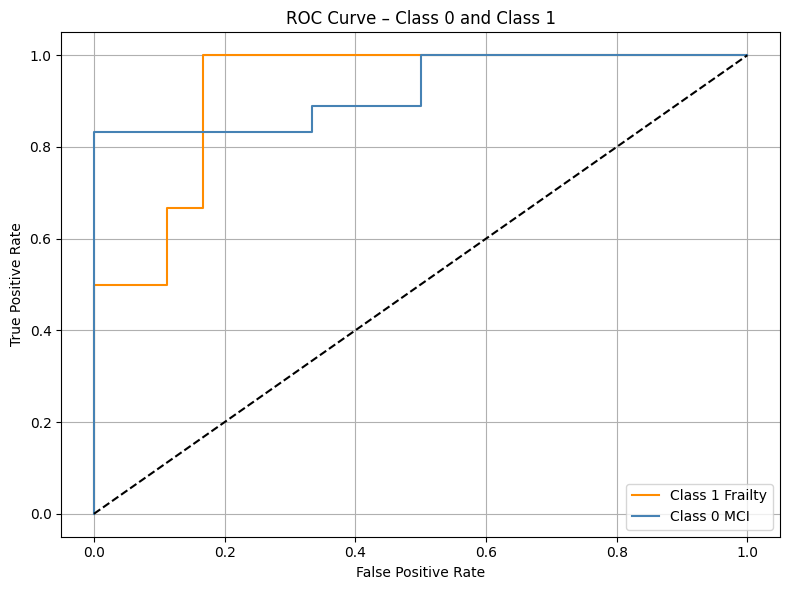

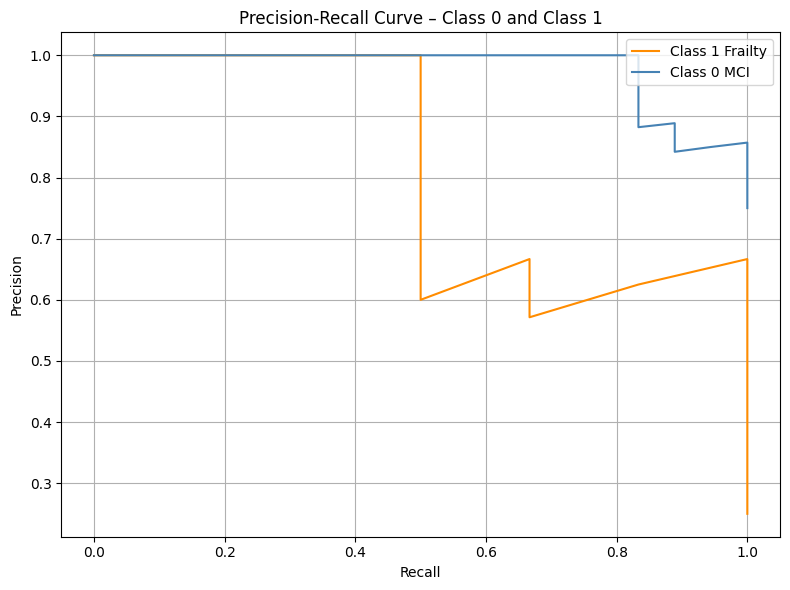

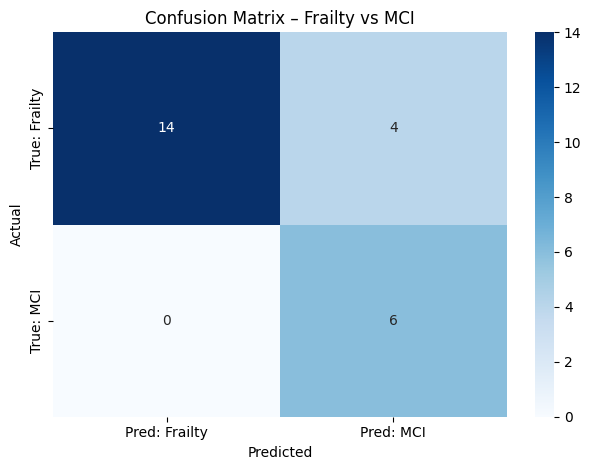

Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.831 ± 0.075 | 95% CI [0.667, 0.958]
PRECISION: 0.599 ± 0.161 | 95% CI [0.273, 0.900]
RECALL: 1.000 ± 0.000 | 95% CI [1.000, 1.000]
SPECIFICITY: 0.774 ± 0.097 | 95% CI [0.583, 0.947]
F1: 0.736 ± 0.132 | 95% CI [0.429, 0.947]
ROC_AUC: 0.924 ± 0.057 | 95% CI [0.784, 1.000]
PR_AUC: 0.806 ± 0.154 | 95% CI [0.409, 1.000]


In [66]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

df_mci_frailty = df[df['group'].isin(['MCI', 'Frailty'])].copy()

X = df_mci_frailty[selected_features]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, selected_features)
])


lasso_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

lasso_pipeline.fit(X_train_rus, y_train_rus)


y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

print("Test Set Metrics – HC vs Frailty")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Cross validation
cv_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ( 'rus', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

cv_results = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Stratified Cross-Validation (5 folds):")
for metric in scoring:
    mean = cv_results[f'test_{metric}'].mean()
    std = cv_results[f'test_{metric}'].std()
    print(f"{metric.upper()}: {mean:.3f} ± {std:.3f}")

# Feature importance (coefficients)
model = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("Non-zero Coefficients (LASSO):")
print(coef_df[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 Frailty', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 MCI', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 Frailty', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 MCI', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: Frailty", "Pred: MCI"],
            yticklabels=["True: Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Frailty vs MCI")
plt.tight_layout()
plt.show()

# Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


### SHAP: MCI vs Frailty

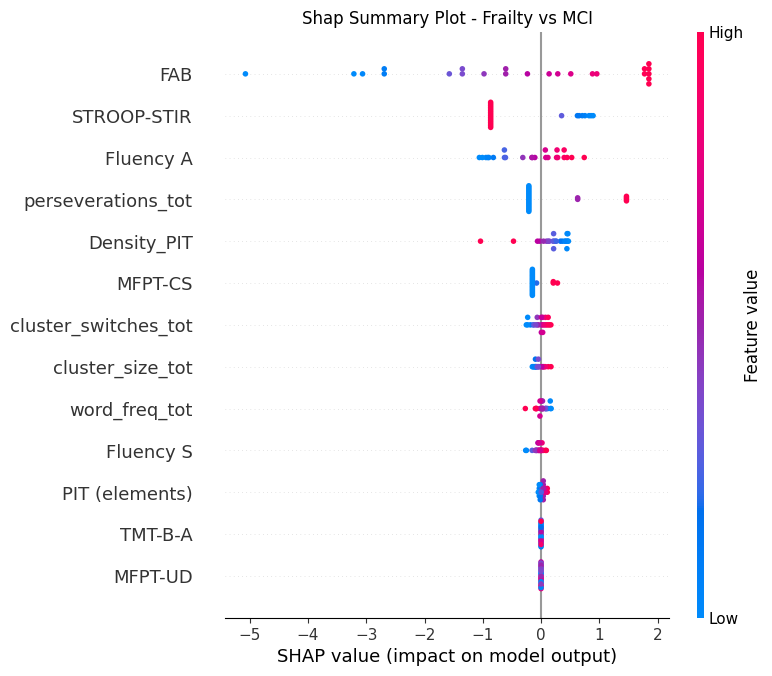

In [67]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

df_mci_frailty = df[df['group'].isin(['MCI', 'Frailty'])].copy()

X = df_mci_frailty[selected_features]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_rus)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_scaled, y_train_rus)

# SHAP: EXPLAINER + SUMMARY PLOT 
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, max_display=13,title = "Shap Summary Plot - Frailty vs MCI", show=False)
plt.title("Shap Summary Plot - Frailty vs MCI")
plt.show()

## Models vs Gold Standard

### (MCI vs All) vs GS

Evaluation of the agreement between the model predictions (Random Undersampling) and the gold standard by means of OLS linear regression.

In [68]:
test_z_scores = [
    'MMSE', 'Corsi D.', 'Digit D.', 'Supraspan',
    'TMT-A', 'TMT-B', 'TMT-B-A', 'Rey_copy', 'Rey_Imm', 'Rey_diff', 'Rey_oblio',
    'Rac Im', 'Rac Diff', 'Rac Oblio', 'FAB',
    'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting',
    'GDS', 'ADL', 'IADL'
]

# Define the cutoff for deficit
deficit_cutoff = -1.5

# Count how many tests are below cutoff (z ≤ -1.5) for each subject
df_n['n_deficient'] = (df_n[test_z_scores] <= deficit_cutoff).sum(axis=1)

# Create binary gold standard: 1 = MCI (at least 1 deficits), 0 = not MCI
df_n['gold_MCI'] = (df_n['n_deficient'] >= 1).astype(int)

print(df_n['gold_MCI'].value_counts())


gold_MCI
0    82
1    28
Name: count, dtype: int64


In [69]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

X = df[selected_features]
y = df['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Gold standard
df['gold_MCI'] = df_n['gold_MCI'] 
gold = df['gold_MCI']

imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_imp)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_ros, y_train_ros)

y_proba = model.predict_proba(X_test_scaled)[:, 1]

X_lin = sm.add_constant(y_proba)
lin_model = sm.OLS(gold_test.values, X_lin).fit()

print("Linear regression: predicted MCI (ROS model) vs gold standard")
print(lin_model.summary())

# Scatter plot
plt.figure(figsize=(6, 5))
sns.regplot(x=y_proba, y=gold_test.values, logistic=False, ci=95, scatter_kws={"alpha": 0.6})
plt.xlabel("Model predicted probability (MCI) – with ROS")
plt.ylabel("Gold standard (binary MCI)")
plt.title("Linear regression: MCI model vs clinical gold standard")
plt.tight_layout()
plt.show()


NameError: name 'gold_test' is not defined

### (HC vs Frailty) vs GS

Linear regression: predicted Frailty vs gold standard (TFI ≥ 5, no cognitive deficits)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                 -0.028
Method:                 Least Squares   F-statistic:                    0.5951
Date:                Mon, 14 Apr 2025   Prob (F-statistic):              0.453
Time:                        06:05:30   Log-Likelihood:                -10.763
No. Observations:                  16   AIC:                             25.53
Df Residuals:                      14   BIC:                             27.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

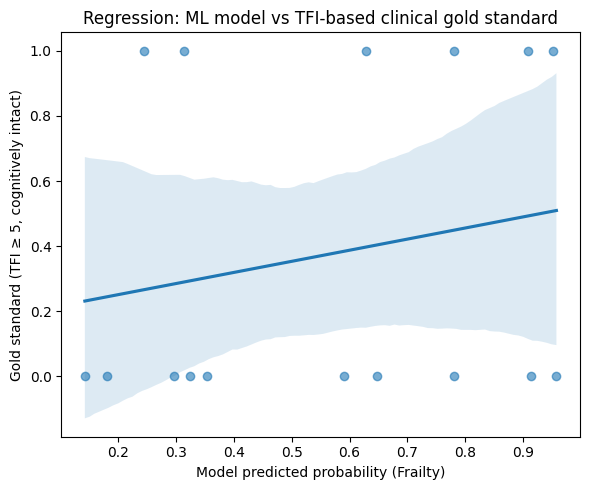

In [52]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]


missing_cols = [col for col in selected_features if col not in df_n.columns]
df_full = df_n.join(df[missing_cols])


df_HCF = df_full[df_full['group'].isin(['HC', 'Frailty'])].copy()


test_zscores = ['MMSE', 'Corsi D.', 'Digit D.', 'Supraspan',
                'TMT-A', 'TMT-B', 'TMT-B-A', 'Rey_copy', 'Rey_Imm',
                'Rey_diff', 'Rey_oblio', 'Rac Im', 'Rac Diff',
                'Rac Oblio', 'FAB', 'MFPT-UD', 'MFPT-CS',
                'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting']

df_HCF['n_deficients'] = (df_HCF[test_zscores] <= -1.5).sum(axis=1)

df_HCF['TFI_total'] = df_HCF[['TFI- variabili fisiche ',
                              'TFI- variabili psicologiche',
                              'TFI- sociali']].sum(axis=1)

df_HCF['gold_HCvsFrailty'] = np.where(
    (df_HCF['group'] == 'HC'), 0,
    np.where(
        (df_HCF['group'] == 'Frailty') &
        (df_HCF['TFI_total'] >= 5) &
        (df_HCF['n_deficients'] == 0), 1,
        np.nan
    )
)


df_gold = df_HCF.dropna(subset=["gold_HCvsFrailty"]).copy()


X = df_gold[selected_features]
y = df_gold['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
gold = df_gold['gold_HCvsFrailty']


X_train, X_test, y_train, y_test, gold_train, gold_test = train_test_split(
    X, y, gold, stratify=y, test_size=0.3, random_state=42
)


imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)


ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)


model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_ros, y_train_ros)


y_proba = model.predict_proba(X_test_scaled)[:, 1]

X_lin = sm.add_constant(y_proba)
lin_model = sm.OLS(gold_test.values, X_lin).fit()

print("Linear regression: predicted Frailty vs gold standard (TFI ≥ 5, no cognitive deficits)")
print(lin_model.summary())

plt.figure(figsize=(6, 5))
sns.regplot(
    x=y_proba,
    y=gold_test.values,
    logistic=False,
    ci=95,
    scatter_kws={"alpha": 0.6}
)
plt.xlabel("Model predicted probability (Frailty)")
plt.ylabel("Gold standard (TFI ≥ 5, cognitively intact)")
plt.title("Regression: ML model vs TFI-based clinical gold standard")
plt.tight_layout()
plt.show()


Linear regression: model probability (no resampling) vs gold standard (TFI ≥ 5)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                 -0.026
Method:                 Least Squares   F-statistic:                    0.6139
Date:                Sun, 13 Apr 2025   Prob (F-statistic):              0.446
Time:                        16:16:36   Log-Likelihood:                -10.753
No. Observations:                  16   AIC:                             25.51
Df Residuals:                      14   BIC:                             27.05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

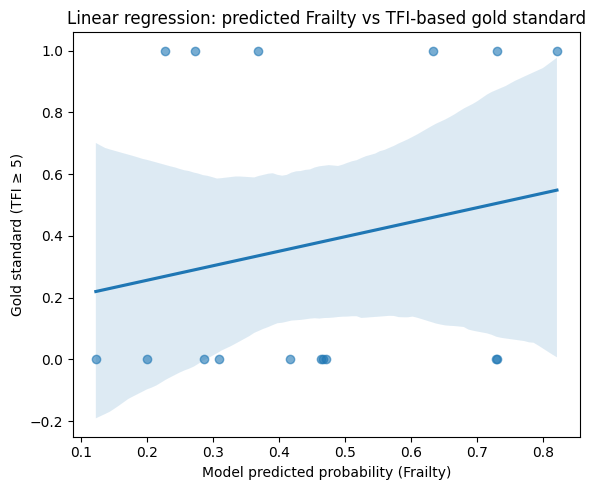

In [111]:
df_HCF = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

test_zscores = ['MMSE', 'Corsi D.', 'Digit D.', 'Supraspan',
                'TMT-A', 'TMT-B', 'TMT-B-A', 'Rey_copy', 'Rey_Imm',
                'Rey_diff', 'Rey_oblio', 'Rac Im', 'Rac Diff',
                'Rac Oblio', 'FAB', 'MFPT-UD', 'MFPT-CS',
                'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting']

df_HCF['n_deficients'] = (df_HCF[test_zscores] <= -1.5).sum(axis=1)

df_HCF['TFI_total'] = df_HCF[['TFI- variabili fisiche ',
                                        'TFI- variabili psicologiche',
                                        'TFI- sociali']].sum(axis=1)

df_HCF['gold_HCvsFrailty'] = np.where(
    (df_HCF['group'] == 'HC'), 0,  # HC = 0
    np.where(
        (df_HCF['group'] == 'Frailty') & 
        (df_HCF['TFI_total'] >= 5) & 
        (df_HCF['n_deficients'] == 0), 1, 
        np.nan  
    )
)

df_gold = df_HCF.dropna(subset=["gold_HCvsFrailty"]).copy()

selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

X = df[selected_features]
y = df['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Predict probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# Linear regression with gold standard
X_lin = sm.add_constant(y_proba)
lin_model = sm.OLS(gold_test.values, X_lin).fit()

print("Linear regression: model probability (no resampling) vs gold standard (TFI ≥ 5)")
print(lin_model.summary())

# Scatter plot
plt.figure(figsize=(6, 5))
sns.regplot(x=y_proba, y=gold_test.values, logistic=False, ci=95, scatter_kws={"alpha": 0.6})
plt.xlabel("Model predicted probability (Frailty)")
plt.ylabel("Gold standard (TFI ≥ 5)")
plt.title("Linear regression: predicted Frailty vs TFI-based gold standard")
plt.tight_layout()
plt.show()

In [121]:
print(df_HCF['gold_HCvsFrailty'].value_counts())

gold_HCvsFrailty
0.0    32
1.0    20
Name: count, dtype: int64


### (MCI vs Frailty) vs GS

Linear regression: predicted Frailty vs gold standard (TFI ≥ 5, no deficits)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     6.428
Date:                Mon, 14 Apr 2025   Prob (F-statistic):             0.0249
Time:                        06:10:51   Log-Likelihood:                -2.0858
No. Observations:                  15   AIC:                             8.172
Df Residuals:                      13   BIC:                             9.588
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

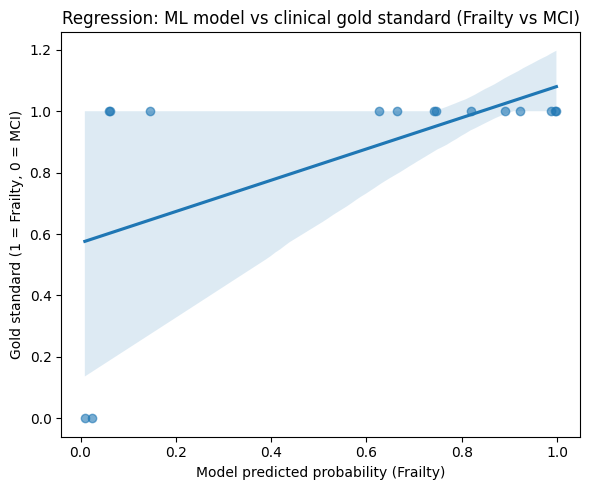

In [56]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# === 2. Crea gold standard: 
# 1 = frailty clinica → TFI ≥ 5 e 0 deficit
# 0 = MCI → almeno 1 deficit e TFI < 5
# NaN = tutti i casi misti
test_zscores = ['MMSE', 'Corsi D.', 'Digit D.', 'Supraspan',
                'TMT-A', 'TMT-B', 'TMT-B-A', 'Rey_copy', 'Rey_Imm',
                'Rey_diff', 'Rey_oblio', 'Rac Im', 'Rac Diff',
                'Rac Oblio', 'FAB', 'MFPT-UD', 'MFPT-CS',
                'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting']

df_mci_frailty['n_deficients'] = (df_mci_frailty[test_zscores] <= -1.5).sum(axis=1)

df_mci_frailty['TFI_total'] = df_mci_frailty[['TFI- variabili fisiche ',
                                              'TFI- variabili psicologiche',
                                              'TFI- sociali']].sum(axis=1)

df_mci_frailty['gold_MCIvsFrailty'] = np.where(
    (df_mci_frailty['TFI_total'] >= 5) & (df_mci_frailty['n_deficients'] == 0), 1,  # Frailty
    np.where((df_mci_frailty['TFI_total'] < 5) & (df_mci_frailty['n_deficients'] >= 1), 0, np.nan)  # MCI o esclusi
)

# === 3. Tieni solo i casi validi ===
df_gold = df_mci_frailty.dropna(subset=['gold_MCIvsFrailty']).copy()

# === 4. Feature e target ===
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)'
]

X = df_gold[selected_features]
y = df_gold['group'].apply(lambda g: 1 if g == 'Frailty' else 0)  # ML target: 1 = Frailty
gold = df_gold['gold_MCIvsFrailty']  # Gold standard: 1 = Frailty

# === 5. Train-test split ===
X_train, X_test, y_train, y_test, gold_train, gold_test = train_test_split(
    X, y, gold, stratify=y, test_size=0.3, random_state=42
)

# === 6. Imputazione e scaling ===
imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

# === 7. Bilanciamento con Random Undersampling (RUS) ===
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

# === 8. Addestramento modello ML (LASSO) ===
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_rus, y_train_rus)

# === 9. Predizione: probabilità di essere Frailty ===
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# === 10. Regressione lineare vs gold standard (TFI-based) ===
X_lin = sm.add_constant(y_proba)
lin_model = sm.OLS(gold_test.values, X_lin).fit()

print("Linear regression: predicted Frailty vs gold standard (TFI ≥ 5, no deficits)")
print(lin_model.summary())

# === 11. Plot della regressione ===
plt.figure(figsize=(6, 5))
sns.regplot(
    x=y_proba,
    y=gold_test.values,
    logistic=False,
    ci=95,
    scatter_kws={"alpha": 0.6}
)
plt.xlabel("Model predicted probability (Frailty)")
plt.ylabel("Gold standard (1 = Frailty, 0 = MCI)")
plt.title("Regression: ML model vs clinical gold standard (Frailty vs MCI)")
plt.tight_layout()
plt.show()


Linear regression: model probability vs gold standard (MCI vs Frailty)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.502
Date:                Sun, 13 Apr 2025   Prob (F-statistic):              0.237
Time:                        15:35:13   Log-Likelihood:                -9.1076
No. Observations:                  19   AIC:                             22.22
Df Residuals:                      17   BIC:                             24.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

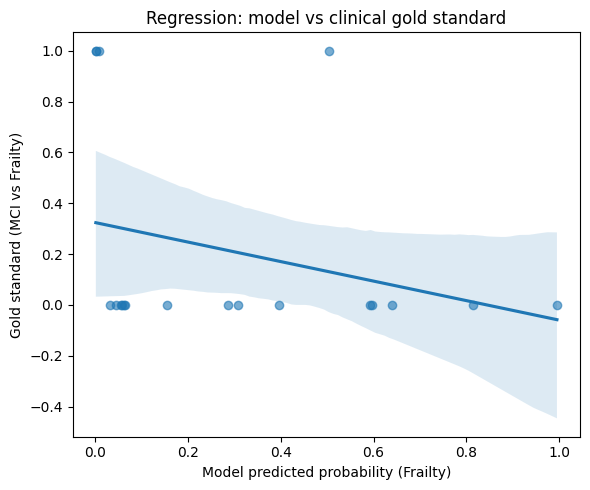

In [81]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

test_zscores = ['MMSE', 'Corsi D.', 'Digit D.', 'Supraspan',
                'TMT-A', 'TMT-B', 'TMT-B-A', 'Rey_copy', 'Rey_Imm',
                'Rey_diff', 'Rey_oblio', 'Rac Im', 'Rac Diff',
                'Rac Oblio', 'FAB', 'MFPT-UD', 'MFPT-CS',
                'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting']

df_mci_frailty['n_deficients'] = (df_mci_frailty[test_zscores] <= -1.5).sum(axis=1)

# Compute TFI total
df_mci_frailty['TFI_total'] = df_mci_frailty[['TFI- variabili fisiche ',
                                              'TFI- variabili psicologiche',
                                              'TFI- sociali']].sum(axis=1)

# Create gold standard
df_mci_frailty['gold_MCIvsFrailty'] = np.where(
    (df_mci_frailty['n_deficients'] >= 1) & (df_mci_frailty['TFI_total'] < 5), 1,
    np.where(df_mci_frailty['TFI_total'] >= 5, 0, np.nan)
)

# Drop NaN (ambiguous cases)
df_gold = df_mci_frailty.dropna(subset=['gold_MCIvsFrailty'])
gold_test_inverted = 1 - gold_test.values

# Features and target
X = df_gold[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
             'Fluency S', 'Fluency A', 'Fluency Shifting',
             'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_gold['group'].apply(lambda g: 1 if g == 'Frailty' else 0)
y_gold = df_gold['gold_MCIvsFrailty']

# Train-test split
X_train, X_test, y_train, y_test, gold_train, gold_test = train_test_split(
    X, y, y_gold, stratify=y, test_size=0.3, random_state=42
)

# Train model (with RUS)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_rus, y_train_rus)


y_proba = model.predict_proba(X_test)[:, 1]

# Regress predicted probability vs gold standard
import statsmodels.api as sm
X_lin = sm.add_constant(y_proba)
lin_model = sm.OLS(gold_test.values, X_lin).fit()

print("Linear regression: model probability vs gold standard (MCI vs Frailty)")
print(lin_model.summary())

# Scatter plot
plt.figure(figsize=(6, 5))
sns.regplot(x=y_proba, y=gold_test.values, logistic=False, ci=95, scatter_kws={"alpha": 0.6})
plt.xlabel("Model predicted probability (Frailty)")
plt.ylabel("Gold standard (MCI vs Frailty)")
plt.title("Regression: model vs clinical gold standard")
plt.tight_layout()
plt.show()


In [109]:
print(df_mci_frailty['gold_MCIvsFrailty'].value_counts())

gold_MCIvsFrailty
0.0    49
1.0     7
Name: count, dtype: int64


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=970a50dd-d838-4190-8c0b-17ac60744345' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>